# Resultados 2021 por proceso

Este notebook calcula indices de densidad por proceso para 2021 a partir de los archivos `embeddings_2021_<start>_<end>.csv` ya generados.

Indices calculados:

- `ID_bin_rf`, `ID_bin_rf_aug`, `ID_bin_lr`: porcentaje de preguntas acusatorias por proceso usando la version binaria de cada modelo.
- `ID_prob_rf`, `ID_prob_rf_aug`, `ID_prob_lr`: promedio de los scores probabilisticos/continuos de cada modelo por proceso.
- `ID_prob_weighted`: promedio ponderado de los tres indices probabilisticos usando pesos derivados del Brier score.

In [4]:
#imports

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# Pesos obtenidos desde Brier score. Actualizar si se recalculan los Brier scores en modelos_probabilidades.ipynb.
W_LR = 0.5478240336268073
W_RF = 0.3998231918002441
W_RF_AUG = 0.0523527745729486

WEIGHT_SUM = W_LR + W_RF + W_RF_AUG
W_LR_NORM = W_LR / WEIGHT_SUM
W_RF_NORM = W_RF / WEIGHT_SUM
W_RF_AUG_NORM = W_RF_AUG / WEIGHT_SUM

EMBEDDING_FILE_RE = re.compile(r"^embeddings_2021_(\d+)_(\d+)\.csv$")


@dataclass(frozen=True)
class Paths:
    codes_dir: Path
    output_dir: Path
    prepared_data_path: Path
    train_rf_path: Path
    train_rf_aug_path: Path
    train_lr_path: Path
    indices_output_path: Path


def resolve_codes_dir() -> Path:
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.append(cwd / "Codes")
    candidates.extend(cwd.parents)
    candidates.extend(parent / "Codes" for parent in cwd.parents)

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if not candidate.exists() or not candidate.is_dir():
            continue
        if (candidate / "output" / "2021").exists() and (candidate / "Archivos_Random_Forest").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo ubicar la carpeta Codes. Ejecuta el notebook desde el proyecto o ajusta las rutas manualmente."
    )


def default_paths() -> Paths:
    codes_dir = resolve_codes_dir()
    output_dir = codes_dir / "output" / "2021"
    return Paths(
        codes_dir=codes_dir,
        output_dir=output_dir,
        prepared_data_path=output_dir / "preguntas_2021_prepared.csv",
        train_rf_path=codes_dir
        / "Archivos_Random_Forest"
        / "train_embeddings_balanced_total_sentence_prompt_GPT4o_mini_text-embedding-3-large.csv",
        train_rf_aug_path=codes_dir
        / "Archivos_Random_Forest_1"
        / "train_embeddings_total_augmented_data_text-embedding-3-large.csv",
        train_lr_path=codes_dir
        / "Archivos_Logistic_Regression"
        / "train_embeddings_balanced_total_sinonimos_text-embedding-3-large.csv",
        indices_output_path=output_dir / "indices_per_process.csv",
    )


def parse_embedding_ranges(output_dir: Path) -> list[tuple[int, int, Path]]:
    files: list[tuple[int, int, Path]] = []
    for path in output_dir.glob("embeddings_2021_*_*.csv"):
        match = EMBEDDING_FILE_RE.match(path.name)
        if not match:
            continue
        start_idx = int(match.group(1))
        end_idx = int(match.group(2))
        files.append((start_idx, end_idx, path))
    return sorted(files, key=lambda item: item[0])


def validate_ranges(
    embedding_ranges: list[tuple[int, int, Path]], total_rows: int
) -> None:
    if not embedding_ranges:
        raise FileNotFoundError("No se encontraron archivos embeddings_2021_<start>_<end>.csv.")

    expected_start = 0
    for start_idx, end_idx, path in embedding_ranges:
        if start_idx != expected_start:
            raise ValueError(
                f"Falta cobertura de embeddings. Se esperaba inicio {expected_start} "
                f"pero el archivo {path.name} empieza en {start_idx}."
            )
        if end_idx <= start_idx:
            raise ValueError(f"Rango invalido en {path.name}.")
        expected_start = end_idx

    if expected_start != total_rows:
        raise ValueError(
            f"Los embeddings cubren hasta la fila {expected_start}, pero el dataset preparado "
            f"tiene {total_rows} filas."
        )


def load_training_matrix(train_path: Path) -> tuple[np.ndarray, np.ndarray, list[str]]:
    train_df = pd.read_csv(train_path, dtype=np.float32)
    if "label" not in train_df.columns:
        raise ValueError(f"El archivo {train_path.name} no contiene la columna label.")

    feature_cols = [col for col in train_df.columns if col != "label"]
    x_train = train_df[feature_cols].to_numpy(dtype=np.float32, copy=False)
    y_train = train_df["label"].to_numpy(dtype=np.int8, copy=False)
    return x_train, y_train, feature_cols


def fit_random_forest(train_path: Path, label: str) -> tuple[RandomForestClassifier, list[str]]:
    print(f"Entrenando {label}...")
    x_train, y_train, feature_cols = load_training_matrix(train_path)
    model = RandomForestClassifier(
        max_depth=None,
        min_samples_leaf=1,
        n_estimators=200,
        random_state=42,
        n_jobs=1,
    )
    model.fit(x_train, y_train)
    del x_train, y_train
    return model, feature_cols


def train_models(
    paths: Paths,
) -> tuple[RandomForestClassifier, list[str], RandomForestClassifier, list[str], LogisticRegression, list[str]]:
    model_rf, feature_cols_rf = fit_random_forest(paths.train_rf_path, "Random Forest")
    model_rf_aug, feature_cols_rf_aug = fit_random_forest(paths.train_rf_aug_path, "Random Forest aumentado")

    print("Entrenando Logistic Regression...")
    x_train_lr, y_train_lr, feature_cols_lr = load_training_matrix(paths.train_lr_path)
    model_lr = LogisticRegression(
        C=100,
        penalty="l2",
        solver="saga",
        max_iter=1000,
        random_state=42,
    )
    model_lr.fit(x_train_lr, y_train_lr)
    del x_train_lr, y_train_lr

    return model_rf, feature_cols_rf, model_rf_aug, feature_cols_rf_aug, model_lr, feature_cols_lr


def build_chunk_aggregates(
    contract_ids: pd.Series,
    prob_rf: np.ndarray,
    prob_rf_aug: np.ndarray,
    prob_lr: np.ndarray,
    pred_rf: np.ndarray,
    pred_rf_aug: np.ndarray,
    pred_lr: np.ndarray,
) -> pd.DataFrame:
    chunk_df = pd.DataFrame(
        {
            "contract_id": contract_ids.to_numpy(copy=False),
            "prob_rf": prob_rf,
            "prob_rf_aug": prob_rf_aug,
            "prob_lr": prob_lr,
            "pred_rf": pred_rf.astype(np.int8, copy=False),
            "pred_rf_aug": pred_rf_aug.astype(np.int8, copy=False),
            "pred_lr": pred_lr.astype(np.int8, copy=False),
        }
    )

    return (
        chunk_df.groupby("contract_id", sort=False, as_index=False)
        .agg(
            n_preguntas=("contract_id", "size"),
            sum_prob_rf=("prob_rf", "sum"),
            sum_prob_rf_aug=("prob_rf_aug", "sum"),
            sum_prob_lr=("prob_lr", "sum"),
            sum_pred_rf=("pred_rf", "sum"),
            sum_pred_rf_aug=("pred_rf_aug", "sum"),
            sum_pred_lr=("pred_lr", "sum"),
        )
    )


def accumulate_process_stats(
    accumulator: dict[str, dict[str, float]],
    chunk_agg: pd.DataFrame,
) -> None:
    for row in chunk_agg.itertuples(index=False):
        contract_id = str(row.contract_id)
        current = accumulator.setdefault(
            contract_id,
            {
                "n_preguntas": 0,
                "sum_prob_rf": 0.0,
                "sum_prob_rf_aug": 0.0,
                "sum_prob_lr": 0.0,
                "sum_pred_rf": 0.0,
                "sum_pred_rf_aug": 0.0,
                "sum_pred_lr": 0.0,
            },
        )
        current["n_preguntas"] += int(row.n_preguntas)
        current["sum_prob_rf"] += float(row.sum_prob_rf)
        current["sum_prob_rf_aug"] += float(row.sum_prob_rf_aug)
        current["sum_prob_lr"] += float(row.sum_prob_lr)
        current["sum_pred_rf"] += float(row.sum_pred_rf)
        current["sum_pred_rf_aug"] += float(row.sum_pred_rf_aug)
        current["sum_pred_lr"] += float(row.sum_pred_lr)


def finalize_indices(accumulator: dict[str, dict[str, float]]) -> pd.DataFrame:
    rows: list[dict[str, float | str | int]] = []
    for contract_id in sorted(accumulator):
        stats = accumulator[contract_id]
        n_preguntas = int(stats["n_preguntas"])
        id_prob_rf = stats["sum_prob_rf"] / n_preguntas
        id_prob_rf_aug = stats["sum_prob_rf_aug"] / n_preguntas
        id_prob_lr = stats["sum_prob_lr"] / n_preguntas
        rows.append(
            {
                "contract_id": contract_id,
                "n_preguntas": n_preguntas,
                "ID_bin_rf": stats["sum_pred_rf"] / n_preguntas,
                "ID_bin_rf_aug": stats["sum_pred_rf_aug"] / n_preguntas,
                "ID_bin_lr": stats["sum_pred_lr"] / n_preguntas,
                "ID_prob_rf": id_prob_rf,
                "ID_prob_rf_aug": id_prob_rf_aug,
                "ID_prob_lr": id_prob_lr,
                "ID_prob_weighted": (
                    W_RF_NORM * id_prob_rf
                    + W_RF_AUG_NORM * id_prob_rf_aug
                    + W_LR_NORM * id_prob_lr
                ),
            }
        )
    return pd.DataFrame(rows)


def _validate_feature_columns(emb_df: pd.DataFrame, feature_cols: list[str], model_name: str, embedding_name: str) -> None:
    missing = [col for col in feature_cols if col not in emb_df.columns]
    if missing:
        raise ValueError(f"Faltan columnas {model_name} en {embedding_name}: {missing[:5]}")


def run_pipeline() -> pd.DataFrame:
    paths = default_paths()
    print(f"codes_dir: {paths.codes_dir}")
    print(f"output_dir: {paths.output_dir}")
    prepared_df = pd.read_csv(paths.prepared_data_path, usecols=["contract_id"])
    embedding_ranges = parse_embedding_ranges(paths.output_dir)
    validate_ranges(embedding_ranges, len(prepared_df))

    model_rf, feature_cols_rf, model_rf_aug, feature_cols_rf_aug, model_lr, feature_cols_lr = train_models(paths)
    accumulator: dict[str, dict[str, float]] = {}

    for start_idx, end_idx, embedding_path in embedding_ranges:
        print(f"Procesando {embedding_path.name} [{start_idx}, {end_idx})...")
        emb_df = pd.read_csv(embedding_path, dtype=np.float32)
        expected_rows = end_idx - start_idx
        if len(emb_df) != expected_rows:
            raise ValueError(
                f"{embedding_path.name} tiene {len(emb_df)} filas y se esperaban {expected_rows}."
            )

        meta_chunk = prepared_df.iloc[start_idx:end_idx].reset_index(drop=True)
        if len(meta_chunk) != len(emb_df):
            raise ValueError(
                f"Desalineacion entre metadata y embeddings para {embedding_path.name}."
            )

        _validate_feature_columns(emb_df, feature_cols_rf, "RF", embedding_path.name)
        _validate_feature_columns(emb_df, feature_cols_rf_aug, "RF aumentado", embedding_path.name)
        _validate_feature_columns(emb_df, feature_cols_lr, "LR", embedding_path.name)

        x_rf = emb_df[feature_cols_rf].to_numpy(dtype=np.float32, copy=False)
        x_rf_aug = emb_df[feature_cols_rf_aug].to_numpy(dtype=np.float32, copy=False)
        x_lr = emb_df[feature_cols_lr].to_numpy(dtype=np.float32, copy=False)

        prob_rf = model_rf.predict_proba(x_rf)[:, 1].astype(np.float32, copy=False)
        prob_rf_aug = model_rf_aug.predict_proba(x_rf_aug)[:, 1].astype(np.float32, copy=False)
        prob_lr = model_lr.predict_proba(x_lr)[:, 1].astype(np.float32, copy=False)
        pred_rf = model_rf.predict(x_rf).astype(np.int8, copy=False)
        pred_rf_aug = model_rf_aug.predict(x_rf_aug).astype(np.int8, copy=False)
        pred_lr = model_lr.predict(x_lr).astype(np.int8, copy=False)

        chunk_agg = build_chunk_aggregates(
            contract_ids=meta_chunk["contract_id"],
            prob_rf=prob_rf,
            prob_rf_aug=prob_rf_aug,
            prob_lr=prob_lr,
            pred_rf=pred_rf,
            pred_rf_aug=pred_rf_aug,
            pred_lr=pred_lr,
        )
        accumulate_process_stats(accumulator, chunk_agg)

        del emb_df, meta_chunk, x_rf, x_rf_aug, x_lr
        del prob_rf, prob_rf_aug, prob_lr, pred_rf, pred_rf_aug, pred_lr, chunk_agg

    indices_df = finalize_indices(accumulator)
    paths.indices_output_path.parent.mkdir(parents=True, exist_ok=True)
    indices_df.to_csv(paths.indices_output_path, index=False, encoding="utf-8")

    print(f"Procesos con indices: {len(indices_df):,}")
    print(f"Archivo generado: {paths.indices_output_path}")
    return indices_df

In [3]:
# Ejecutar el pipeline y mostrar los primeros resultados 
# Se ejecuta una sola vez, ya que el proceso es costoso. El resultado se guarda en output/2021/indices_per_process.csv

indices_df = run_pipeline()
indices_df.head(10)


codes_dir: D:\Noveno Semestre\Tesis Informal\Codes
output_dir: D:\Noveno Semestre\Tesis Informal\Codes\output\2021
Entrenando Random Forest...
Entrenando Random Forest aumentado...
Entrenando Logistic Regression...
Procesando embeddings_2021_0_20000.csv [0, 20000)...
Procesando embeddings_2021_20000_40000.csv [20000, 40000)...
Procesando embeddings_2021_40000_60000.csv [40000, 60000)...
Procesando embeddings_2021_60000_80000.csv [60000, 80000)...
Procesando embeddings_2021_80000_100000.csv [80000, 100000)...
Procesando embeddings_2021_100000_120000.csv [100000, 120000)...
Procesando embeddings_2021_120000_134294.csv [120000, 134294)...
Procesos con indices: 17,152
Archivo generado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\indices_per_process.csv


,contract_id,n_preguntas,ID_bin_rf,ID_bin_rf_aug,ID_bin_lr,ID_prob_rf,ID_prob_rf_aug,ID_prob_lr,ID_prob_weighted
0,1608622,9,0.0,0.777778,0.0,0.256667,0.596667,0.028370,0.149400
1,1608717,4,0.0,1.000000,0.0,0.221250,0.618750,0.005547,0.123893
2,1608968,3,0.0,0.000000,0.0,0.078333,0.283333,0.000368,0.046355
3,1609087,2,0.0,0.000000,0.0,0.160000,0.422500,0.000001,0.086091
4,1609116,13,0.0,0.461538,0.0,0.206154,0.510769,0.001334,0.109896
5,1609119,2,0.0,1.000000,0.0,0.345000,0.640000,0.001760,0.172409
6,1609206,1,0.0,0.000000,0.0,0.200000,0.380000,0.000003,0.099860
7,1609217,19,0.0,0.578947,0.0,0.190789,0.540526,0.000491,0.104849
8,1609219,2,0.0,0.000000,0.0,0.175000,0.395000,0.000017,0.090658
9,1609235,2,0.5,1.000000,0.5,0.642500,0.880000,0.522960,0.589447


In [7]:
indices_df = pd.read_csv("output/2021/indices_per_process.csv")

## Marco de evaluacion cuantitativa

Esta seccion organiza las metricas cuantitativas por dimension para poder elegir el mejor indice de forma trazable. La primera dimension es **alineacion con la linea base de Kapak**.

La pregunta de esta dimension es: **que tan cerca queda cada indice del patron historico que producia Kapak a nivel proceso**.

Para esta dimension se usan cuatro metricas complementarias:

- `auc_rank_vs_kapak`: mide si los procesos Kapak-positivos tienden a recibir puntajes mas altos.
- `spearman_vs_kapak_binary`: mide si el orden del indice se parece al orden inducido por la etiqueta binaria de Kapak.
- `top_5pct_precision_vs_kapak`: mide que proporcion de los procesos ubicados en el top 5 % del indice son Kapak-positivos.
- `top_k_overlap_vs_kapak`: mide cuanto se superpone el top del indice con el conjunto Kapak-positivo, usando el mismo numero de procesos positivos que Kapak.

Estas metricas no prueban que un indice sea correcto en sentido sustantivo; solo miden consistencia con la metodologia historica de Kapak.


In [25]:
import csv

KAPAK_TOP_PCT = 0.05


def load_kapak_questions_for_baseline(paths: Paths) -> pd.DataFrame:
    raw_path = paths.codes_dir / "preguntas_2021.csv"
    raw_lines = pd.read_csv(raw_path, header=None, dtype=str, encoding="utf-8").iloc[:, 0].astype(str).tolist()
    rows = list(csv.reader(raw_lines))
    kapak_questions_df = pd.DataFrame(rows[1:], columns=rows[0])
    kapak_questions_df["contract_id"] = kapak_questions_df["contract_id"].astype(str).str.strip()
    kapak_questions_df["es_acusatoria_bool"] = (
        kapak_questions_df["es_acusatoria"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "si", "s?", "acusatoria"])
    )
    return kapak_questions_df


def build_kapak_process_baseline(kapak_questions_df: pd.DataFrame) -> pd.DataFrame:
    return (
        kapak_questions_df.groupby("contract_id", as_index=False)
        .agg(
            n_preguntas_kapak=("contract_id", "size"),
            n_acusatorias_kapak=("es_acusatoria_bool", "sum"),
        )
        .assign(
            kapak_process_accusatory=lambda df_: df_["n_acusatorias_kapak"] > 0,
            kapak_share_acusatoria=lambda df_: df_["n_acusatorias_kapak"] / df_["n_preguntas_kapak"],
        )
    )


def auc_from_ranks(y_true: pd.Series, scores: pd.Series) -> float:
    y = y_true.astype(bool).to_numpy()
    ranked_scores = scores.rank(method="average").to_numpy()
    n_pos = int(y.sum())
    n_neg = int((~y).sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    rank_sum_pos = ranked_scores[y].sum()
    return float((rank_sum_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def compute_baseline_alignment_metrics(
    process_df: pd.DataFrame,
    index_columns: list[str],
    top_pct: float = 0.05,
) -> pd.DataFrame:
    y = process_df["kapak_process_accusatory"].astype(bool)
    kapak_positive_ids = set(process_df.loc[y, "contract_id"].astype(str))
    kapak_positive_count = int(y.sum())
    top_n_pct = max(1, int(np.ceil(len(process_df) * top_pct)))

    rows = []
    for col in index_columns:
        ordered_df = process_df.sort_values(col, ascending=False).reset_index(drop=True)
        top_pct_df = ordered_df.head(top_n_pct)
        top_k_df = ordered_df.head(kapak_positive_count)
        top_k_ids = set(top_k_df["contract_id"].astype(str))

        rows.append(
            {
                "model": col,
                "auc_rank_vs_kapak": auc_from_ranks(y, process_df[col]),
                "spearman_vs_kapak_binary": process_df[col].corr(y.astype(int), method="spearman"),
                "top_5pct_precision_vs_kapak": top_pct_df["kapak_process_accusatory"].mean(),
                "top_k_overlap_vs_kapak": len(top_k_ids & kapak_positive_ids) / kapak_positive_count,
                "kapak_positive_rate": y.mean(),
                "top_5pct_n": top_n_pct,
                "top_k_n": kapak_positive_count,
            }
        )

    metrics_df = pd.DataFrame(rows)
    metric_cols = [
        "auc_rank_vs_kapak",
        "spearman_vs_kapak_binary",
        "top_5pct_precision_vs_kapak",
        "top_k_overlap_vs_kapak",
    ]
    for metric in metric_cols:
        metrics_df[f"{metric}_rank"] = metrics_df[metric].rank(method="min", ascending=False)

    metrics_df["baseline_alignment_rank_mean"] = metrics_df[[f"{metric}_rank" for metric in metric_cols]].mean(axis=1)
    metrics_df["baseline_alignment_score"] = metrics_df[metric_cols].rank(method="min", ascending=False).mean(axis=1)
    return metrics_df.sort_values(["baseline_alignment_rank_mean", "auc_rank_vs_kapak"], ascending=[True, False]).reset_index(drop=True)


paths = default_paths()
indices_df["contract_id"] = indices_df["contract_id"].astype(str)
kapak_questions_baseline_df = load_kapak_questions_for_baseline(paths)
kapak_process_baseline_df = build_kapak_process_baseline(kapak_questions_baseline_df)
baseline_eval_df = indices_df.merge(kapak_process_baseline_df, on="contract_id", how="inner")
baseline_alignment_df = compute_baseline_alignment_metrics(baseline_eval_df, INDEX_COLUMNS, top_pct=KAPAK_TOP_PCT)

print(f"Procesos comparables con Kapak: {len(baseline_eval_df):,}")
print(f"Prevalencia Kapak a nivel proceso: {baseline_eval_df['kapak_process_accusatory'].mean():.2%}")
baseline_alignment_df


Procesos comparables con Kapak: 17,152
Prevalencia Kapak a nivel proceso: 19.14%


,model,auc_rank_vs_kapak,spearman_vs_kapak_binary,top_5pct_precision_vs_kapak,top_k_overlap_vs_kapak,kapak_positive_rate,top_5pct_n,top_k_n,auc_rank_vs_kapak_rank,spearman_vs_kapak_binary_rank,top_5pct_precision_vs_kapak_rank,top_k_overlap_vs_kapak_rank,baseline_alignment_rank_mean,baseline_alignment_score
0,ID_prob_lr,0.779311,0.380646,0.518648,0.499543,0.191406,858,3283,1.0,2.0,2.0,2.0,1.75,1.75
1,ID_bin_rf,0.701495,0.394655,0.479021,0.506853,0.191406,858,3283,3.0,1.0,4.0,1.0,2.25,2.25
2,ID_prob_weighted,0.723270,0.304274,0.513986,0.421566,0.191406,858,3283,2.0,4.0,3.0,4.0,3.25,3.25
3,ID_bin_lr,0.657410,0.369743,0.533800,0.428876,0.191406,858,3283,6.0,3.0,1.0,3.0,3.25,3.25
4,ID_prob_rf,0.686373,0.253991,0.428904,0.333232,0.191406,858,3283,4.0,5.0,5.0,5.0,4.75,4.75
5,ID_prob_rf_aug,0.673466,0.236401,0.360140,0.331709,0.191406,858,3283,5.0,6.0,6.0,6.0,5.75,5.75
6,ID_bin_rf_aug,0.643255,0.197006,0.156177,0.234846,0.191406,858,3283,7.0,7.0,7.0,7.0,7.00,7.00


In [26]:
BASELINE_ALIGNMENT_METRIC_COLUMNS = [
    "auc_rank_vs_kapak",
    "spearman_vs_kapak_binary",
    "top_5pct_precision_vs_kapak",
    "top_k_overlap_vs_kapak",
]

baseline_alignment_display_df = baseline_alignment_df[[
    "model",
    *BASELINE_ALIGNMENT_METRIC_COLUMNS,
    "baseline_alignment_rank_mean",
]].copy()
baseline_alignment_display_df = baseline_alignment_display_df.rename(columns={
    "baseline_alignment_rank_mean": "baseline_alignment_rank_mean_lower_is_better",
})
baseline_alignment_display_df


,model,auc_rank_vs_kapak,spearman_vs_kapak_binary,top_5pct_precision_vs_kapak,top_k_overlap_vs_kapak,baseline_alignment_rank_mean_lower_is_better
0,ID_prob_lr,0.779311,0.380646,0.518648,0.499543,1.75
1,ID_bin_rf,0.701495,0.394655,0.479021,0.506853,2.25
2,ID_prob_weighted,0.723270,0.304274,0.513986,0.421566,3.25
3,ID_bin_lr,0.657410,0.369743,0.533800,0.428876,3.25
4,ID_prob_rf,0.686373,0.253991,0.428904,0.333232,4.75
5,ID_prob_rf_aug,0.673466,0.236401,0.360140,0.331709,5.75
6,ID_bin_rf_aug,0.643255,0.197006,0.156177,0.234846,7.00


### Normalizacion de metricas de alineacion con Kapak

Ademas del promedio de rangos, esta subseccion normaliza las metricas crudas de alineacion con **min-max scaling** en el rango `[0, 1]`. En todas estas metricas, un valor mas alto es mejor, por lo que `1` representa el mejor desempeno observado entre los indices y `0` el peor.

Esto permite conservar la **magnitud de las diferencias** entre modelos. Por ejemplo, si dos indices ocupan el primer y segundo lugar en AUC pero estan muy cerca entre si, la normalizacion lo reflejara; el esquema basado solo en rangos no lo hace.


In [27]:
def minmax_normalize_metrics(
    metrics_df: pd.DataFrame,
    metric_columns: list[str],
) -> pd.DataFrame:
    normalized_df = metrics_df.copy()
    for metric in metric_columns:
        metric_min = normalized_df[metric].min()
        metric_max = normalized_df[metric].max()
        out_col = f"{metric}_minmax"
        if pd.isna(metric_min) or pd.isna(metric_max) or metric_max == metric_min:
            normalized_df[out_col] = 1.0
        else:
            normalized_df[out_col] = (normalized_df[metric] - metric_min) / (metric_max - metric_min)
    return normalized_df


baseline_alignment_normalized_df = minmax_normalize_metrics(
    baseline_alignment_df,
    BASELINE_ALIGNMENT_METRIC_COLUMNS,
)

BASELINE_ALIGNMENT_MINMAX_COLUMNS = [
    f"{metric}_minmax" for metric in BASELINE_ALIGNMENT_METRIC_COLUMNS
]

baseline_alignment_normalized_df["baseline_alignment_minmax_mean"] = (
    baseline_alignment_normalized_df[BASELINE_ALIGNMENT_MINMAX_COLUMNS].mean(axis=1)
)
baseline_alignment_normalized_df["baseline_alignment_minmax_rank"] = (
    baseline_alignment_normalized_df["baseline_alignment_minmax_mean"].rank(method="min", ascending=False)
)

baseline_alignment_normalized_display_df = baseline_alignment_normalized_df[[
    "model",
    *BASELINE_ALIGNMENT_METRIC_COLUMNS,
    *BASELINE_ALIGNMENT_MINMAX_COLUMNS,
    "baseline_alignment_minmax_mean",
    "baseline_alignment_minmax_rank",
    "baseline_alignment_rank_mean",
]].sort_values(["baseline_alignment_minmax_rank", "baseline_alignment_minmax_mean"], ascending=[True, False]).reset_index(drop=True)

baseline_alignment_normalized_display_df


,model,auc_rank_vs_kapak,spearman_vs_kapak_binary,top_5pct_precision_vs_kapak,top_k_overlap_vs_kapak,auc_rank_vs_kapak_minmax,spearman_vs_kapak_binary_minmax,top_5pct_precision_vs_kapak_minmax,top_k_overlap_vs_kapak_minmax,baseline_alignment_minmax_mean,baseline_alignment_minmax_rank,baseline_alignment_rank_mean
0,ID_prob_lr,0.779311,0.380646,0.518648,0.499543,1.000000,0.929124,0.959877,0.973124,0.965531,1.0,1.75
1,ID_bin_rf,0.701495,0.394655,0.479021,0.506853,0.428055,1.000000,0.854938,1.000000,0.820748,2.0,2.25
2,ID_prob_weighted,0.723270,0.304274,0.513986,0.421566,0.588104,0.542718,0.947531,0.686450,0.691201,3.0,3.25
3,ID_bin_lr,0.657410,0.369743,0.533800,0.428876,0.104036,0.873958,1.000000,0.713326,0.672830,4.0,3.25
4,ID_prob_rf,0.686373,0.253991,0.428904,0.333232,0.316911,0.288313,0.722222,0.361702,0.422287,5.0,4.75
5,ID_prob_rf_aug,0.673466,0.236401,0.360140,0.331709,0.222044,0.199315,0.540123,0.356103,0.329396,6.0,5.75
6,ID_bin_rf_aug,0.643255,0.197006,0.156177,0.234846,0.000000,0.000000,0.000000,0.000000,0.000000,7.0,7.00


## Discriminacion

La segunda dimension cuantitativa es **discriminacion**. La pregunta aqui no es solo si el indice se parece a Kapak, sino si **separa bien** a los procesos Kapak-positivos de los Kapak-negativos.

En esta dimension se usan tres metricas:

- `ks_pos_neg`: maxima distancia entre la distribucion acumulada de puntajes de procesos Kapak-positivos y Kapak-negativos. Cuanto mas alto, mejor separacion.
- `mean_gap_pos_minus_neg`: diferencia entre el puntaje promedio de los procesos Kapak-positivos y el promedio de los Kapak-negativos. Cuanto mas alto, mejor.
- `spearman_vs_kapak_binary_disc`: correlacion de rangos entre el indice y la etiqueta binaria de Kapak. Cuanto mas alto, mejor.

Mientras la dimension anterior mide cercania con la linea base historica, esta dimension mide capacidad de **separar** grupos.


In [30]:
def ks_statistic_from_groups(pos_scores: pd.Series, neg_scores: pd.Series) -> float:
    pos = np.sort(pos_scores.to_numpy(dtype=float, copy=False))
    neg = np.sort(neg_scores.to_numpy(dtype=float, copy=False))
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    values = np.sort(np.unique(np.concatenate([pos, neg])))
    pos_cdf = np.searchsorted(pos, values, side="right") / len(pos)
    neg_cdf = np.searchsorted(neg, values, side="right") / len(neg)
    return float(np.max(np.abs(pos_cdf - neg_cdf)))


def compute_discrimination_metrics(
    process_df: pd.DataFrame,
    index_columns: list[str],
) -> pd.DataFrame:
    y = process_df["kapak_process_accusatory"].astype(bool)
    rows = []
    for col in index_columns:
        pos_scores = process_df.loc[y, col]
        neg_scores = process_df.loc[~y, col]
        rows.append(
            {
                "model": col,
                "ks_pos_neg": ks_statistic_from_groups(pos_scores, neg_scores),
                "mean_gap_pos_minus_neg": pos_scores.mean() - neg_scores.mean(),
                "spearman_vs_kapak_binary_disc": process_df[col].corr(y.astype(int), method="spearman"),
                "mean_pos": pos_scores.mean(),
                "mean_neg": neg_scores.mean(),
                "median_pos": pos_scores.median(),
                "median_neg": neg_scores.median(),
            }
        )

    metrics_df = pd.DataFrame(rows)
    metric_cols = [
        "ks_pos_neg",
        "mean_gap_pos_minus_neg",
        "spearman_vs_kapak_binary_disc",
    ]
    for metric in metric_cols:
        metrics_df[f"{metric}_rank"] = metrics_df[metric].rank(method="min", ascending=False)

    metrics_df["discrimination_rank_mean"] = metrics_df[[f"{metric}_rank" for metric in metric_cols]].mean(axis=1)
    metrics_df = metrics_df.sort_values(["discrimination_rank_mean", "ks_pos_neg"], ascending=[True, False]).reset_index(drop=True)
    return metrics_df


DISCRIMINATION_INDEX_COLUMNS = [
    "ID_bin_rf",
    "ID_bin_rf_aug",
    "ID_bin_lr",
    "ID_prob_rf",
    "ID_prob_rf_aug",
    "ID_prob_lr",
    "ID_prob_weighted",
]

discrimination_df = compute_discrimination_metrics(baseline_eval_df, DISCRIMINATION_INDEX_COLUMNS)
discrimination_df


,model,ks_pos_neg,mean_gap_pos_minus_neg,spearman_vs_kapak_binary_disc,mean_pos,mean_neg,median_pos,median_neg,ks_pos_neg_rank,mean_gap_pos_minus_neg_rank,spearman_vs_kapak_binary_disc_rank,discrimination_rank_mean
0,ID_bin_rf,0.406080,0.084209,0.394655,0.114282,0.030073,0.034483,0.000000,2.0,2.0,1.0,1.666667
1,ID_prob_lr,0.439934,0.065844,0.380646,0.087383,0.021539,0.022308,0.000491,1.0,4.0,2.0,2.333333
2,ID_bin_lr,0.318783,0.063920,0.369743,0.081473,0.017553,0.000000,0.000000,4.0,5.0,3.0,4.000000
3,ID_prob_weighted,0.327775,0.062962,0.304274,0.183248,0.120285,0.141485,0.103270,3.0,6.0,4.0,4.333333
4,ID_bin_rf_aug,0.271392,0.148645,0.197006,0.528606,0.379960,0.515152,0.333333,6.0,1.0,7.0,4.666667
5,ID_prob_rf_aug,0.263919,0.067813,0.236401,0.542917,0.475104,0.533000,0.466364,7.0,3.0,6.0,5.333333
6,ID_prob_rf,0.275730,0.058379,0.253991,0.267503,0.209124,0.241538,0.195000,5.0,7.0,5.0,5.666667


In [31]:
DISCRIMINATION_METRIC_COLUMNS = [
    "ks_pos_neg",
    "mean_gap_pos_minus_neg",
    "spearman_vs_kapak_binary_disc",
]

discrimination_display_df = discrimination_df[[
    "model",
    *DISCRIMINATION_METRIC_COLUMNS,
    "mean_pos",
    "mean_neg",
    "median_pos",
    "median_neg",
    "discrimination_rank_mean",
]].copy()
discrimination_display_df


,model,ks_pos_neg,mean_gap_pos_minus_neg,spearman_vs_kapak_binary_disc,mean_pos,mean_neg,median_pos,median_neg,discrimination_rank_mean
0,ID_bin_rf,0.406080,0.084209,0.394655,0.114282,0.030073,0.034483,0.000000,1.666667
1,ID_prob_lr,0.439934,0.065844,0.380646,0.087383,0.021539,0.022308,0.000491,2.333333
2,ID_bin_lr,0.318783,0.063920,0.369743,0.081473,0.017553,0.000000,0.000000,4.000000
3,ID_prob_weighted,0.327775,0.062962,0.304274,0.183248,0.120285,0.141485,0.103270,4.333333
4,ID_bin_rf_aug,0.271392,0.148645,0.197006,0.528606,0.379960,0.515152,0.333333,4.666667
5,ID_prob_rf_aug,0.263919,0.067813,0.236401,0.542917,0.475104,0.533000,0.466364,5.333333
6,ID_prob_rf,0.275730,0.058379,0.253991,0.267503,0.209124,0.241538,0.195000,5.666667


### Normalizacion de metricas de discriminacion

Estas metricas tambien se normalizan con **min-max scaling** en `[0, 1]` para conservar la magnitud de las diferencias entre indices dentro de la dimension de discriminacion. En las tres metricas, un valor mas alto es mejor.


In [32]:
discrimination_normalized_df = minmax_normalize_metrics(
    discrimination_df,
    DISCRIMINATION_METRIC_COLUMNS,
)

DISCRIMINATION_MINMAX_COLUMNS = [
    f"{metric}_minmax" for metric in DISCRIMINATION_METRIC_COLUMNS
]

discrimination_normalized_df["discrimination_minmax_mean"] = (
    discrimination_normalized_df[DISCRIMINATION_MINMAX_COLUMNS].mean(axis=1)
)
discrimination_normalized_df["discrimination_minmax_rank"] = (
    discrimination_normalized_df["discrimination_minmax_mean"].rank(method="min", ascending=False)
)

discrimination_normalized_display_df = discrimination_normalized_df[[
    "model",
    *DISCRIMINATION_METRIC_COLUMNS,
    *DISCRIMINATION_MINMAX_COLUMNS,
    "discrimination_minmax_mean",
    "discrimination_minmax_rank",
    "discrimination_rank_mean",
]].sort_values(["discrimination_minmax_rank", "discrimination_minmax_mean"], ascending=[True, False]).reset_index(drop=True)

discrimination_normalized_display_df


,model,ks_pos_neg,mean_gap_pos_minus_neg,spearman_vs_kapak_binary_disc,ks_pos_neg_minmax,mean_gap_pos_minus_neg_minmax,spearman_vs_kapak_binary_disc_minmax,discrimination_minmax_mean,discrimination_minmax_rank,discrimination_rank_mean
0,ID_bin_rf,0.406080,0.084209,0.394655,0.807661,0.286151,1.000000,0.697937,1.0,1.666667
1,ID_prob_lr,0.439934,0.065844,0.380646,1.000000,0.082704,0.929124,0.670609,2.0,2.333333
2,ID_bin_lr,0.318783,0.063920,0.369743,0.311703,0.061386,0.873958,0.415682,3.0,4.000000
3,ID_bin_rf_aug,0.271392,0.148645,0.197006,0.042461,1.000000,0.000000,0.347487,4.0,4.666667
4,ID_prob_weighted,0.327775,0.062962,0.304274,0.362791,0.050779,0.542718,0.318763,5.0,4.333333
5,ID_prob_rf,0.275730,0.058379,0.253991,0.067106,0.000000,0.288313,0.118473,6.0,5.666667
6,ID_prob_rf_aug,0.263919,0.067813,0.236401,0.000000,0.104512,0.199315,0.101276,7.0,5.333333


## Parsimonia y calibracion

La cuarta dimension cuantitativa es **parsimonia y calibracion**. Su objetivo es penalizar dos comportamientos opuestos pero indeseables: indices que marcan casi todo como positivo y indices demasiado escasos que dejan fuera una gran parte de los procesos Kapak-positivos.

Se usan dos penalizaciones principales basadas en un umbral natural del indice (`> 0` para indices binarios y `>= 0.5` para indices probabilisticos):

- `overflag_penalty_vs_kapak`: exceso de tasa positiva respecto de Kapak. Un valor alto indica que el indice marca demasiados procesos.
- `sparse_miss_penalty`: penalizacion por escasez con perdida de recall. Se calcula como la escasez relativa respecto de Kapak multiplicada por la tasa de Kapak-positivos perdidos. Un valor alto indica un indice demasiado conservador que deja fuera muchos positivos de Kapak.

Ademas se reportan metricas auxiliares de clasificacion para interpretar mejor estas penalizaciones: `natural_positive_rate`, `recall_vs_kapak`, `precision_vs_kapak` y la matriz de confusion correspondiente.


In [36]:
PARSIMONY_INDEX_COLUMNS = [
    "ID_bin_rf",
    "ID_bin_rf_aug",
    "ID_bin_lr",
    "ID_prob_rf",
    "ID_prob_rf_aug",
    "ID_prob_lr",
    "ID_prob_weighted",
]


def natural_positive_mask_for_parsimony(scores: pd.Series, model_name: str) -> pd.Series:
    if model_name.startswith("ID_bin_"):
        return scores > 0
    return scores >= 0.5


def compute_parsimony_calibration_metrics(
    process_df: pd.DataFrame,
    index_columns: list[str],
) -> pd.DataFrame:
    y = process_df["kapak_process_accusatory"].astype(bool)
    kapak_rate = float(y.mean())
    n_pos = int(y.sum())

    rows = []
    for col in index_columns:
        pred = natural_positive_mask_for_parsimony(process_df[col], col)
        pred_rate = float(pred.mean())

        tp = int((pred & y).sum())
        fp = int((pred & ~y).sum())
        fn = int((~pred & y).sum())
        tn = int((~pred & ~y).sum())

        recall = tp / n_pos if n_pos else float("nan")
        precision = tp / (tp + fp) if (tp + fp) else float("nan")
        missed_positive_rate = fn / n_pos if n_pos else float("nan")

        overflag_penalty = max(pred_rate - kapak_rate, 0.0)
        underflag_gap = max(kapak_rate - pred_rate, 0.0)
        sparse_miss_penalty = underflag_gap * missed_positive_rate

        rows.append(
            {
                "model": col,
                "overflag_penalty_vs_kapak": overflag_penalty,
                "sparse_miss_penalty": sparse_miss_penalty,
                "natural_positive_rate": pred_rate,
                "kapak_positive_rate": kapak_rate,
                "recall_vs_kapak": recall,
                "precision_vs_kapak": precision,
                "missed_positive_rate": missed_positive_rate,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
            }
        )

    metrics_df = pd.DataFrame(rows)
    metric_cols = [
        "overflag_penalty_vs_kapak",
        "sparse_miss_penalty",
    ]
    for metric in metric_cols:
        metrics_df[f"{metric}_rank"] = metrics_df[metric].rank(method="min", ascending=True)

    metrics_df["parsimony_rank_mean"] = metrics_df[[f"{metric}_rank" for metric in metric_cols]].mean(axis=1)
    metrics_df = metrics_df.sort_values(["parsimony_rank_mean", "recall_vs_kapak"], ascending=[True, False]).reset_index(drop=True)
    return metrics_df


parsimony_df = compute_parsimony_calibration_metrics(baseline_eval_df, PARSIMONY_INDEX_COLUMNS)
parsimony_df


,model,overflag_penalty_vs_kapak,sparse_miss_penalty,natural_positive_rate,kapak_positive_rate,recall_vs_kapak,precision_vs_kapak,missed_positive_rate,tp,fp,fn,tn,overflag_penalty_vs_kapak_rank,sparse_miss_penalty_rank,parsimony_rank_mean
0,ID_bin_lr,0.000000,0.039043,0.127857,0.191406,0.385623,0.577291,0.614377,1266,927,2017,12942,1.0,4.0,2.5
1,ID_bin_rf,0.006588,0.000000,0.197994,0.191406,0.526348,0.508834,0.473652,1728,1668,1555,12201,5.0,1.0,3.0
2,ID_prob_rf,0.000000,0.166814,0.017549,0.191406,0.040512,0.441860,0.959488,133,168,3150,13701,1.0,5.0,3.0
3,ID_prob_rf_aug,0.230236,0.000000,0.421642,0.191406,0.622601,0.282633,0.377399,2044,5188,1239,8681,6.0,1.0,3.5
4,ID_prob_weighted,0.000000,0.173043,0.012477,0.191406,0.032897,0.504673,0.967103,108,106,3175,13763,1.0,6.0,3.5
5,ID_bin_rf_aug,0.564949,0.000000,0.756355,0.191406,0.951873,0.240885,0.048127,3125,9848,158,4021,7.0,1.0,4.0
6,ID_prob_lr,0.000000,0.176345,0.010261,0.191406,0.026500,0.494318,0.973500,87,89,3196,13780,1.0,7.0,4.0


In [37]:
PARSIMONY_METRIC_COLUMNS = [
    "overflag_penalty_vs_kapak",
    "sparse_miss_penalty",
]

parsimony_display_df = parsimony_df[[
    "model",
    *PARSIMONY_METRIC_COLUMNS,
    "natural_positive_rate",
    "kapak_positive_rate",
    "recall_vs_kapak",
    "precision_vs_kapak",
    "missed_positive_rate",
    "parsimony_rank_mean",
]].copy()
parsimony_display_df


,model,overflag_penalty_vs_kapak,sparse_miss_penalty,natural_positive_rate,kapak_positive_rate,recall_vs_kapak,precision_vs_kapak,missed_positive_rate,parsimony_rank_mean
0,ID_bin_lr,0.000000,0.039043,0.127857,0.191406,0.385623,0.577291,0.614377,2.5
1,ID_bin_rf,0.006588,0.000000,0.197994,0.191406,0.526348,0.508834,0.473652,3.0
2,ID_prob_rf,0.000000,0.166814,0.017549,0.191406,0.040512,0.441860,0.959488,3.0
3,ID_prob_rf_aug,0.230236,0.000000,0.421642,0.191406,0.622601,0.282633,0.377399,3.5
4,ID_prob_weighted,0.000000,0.173043,0.012477,0.191406,0.032897,0.504673,0.967103,3.5
5,ID_bin_rf_aug,0.564949,0.000000,0.756355,0.191406,0.951873,0.240885,0.048127,4.0
6,ID_prob_lr,0.000000,0.176345,0.010261,0.191406,0.026500,0.494318,0.973500,4.0


### Normalizacion de metricas de parsimonia y calibracion

Las dos metricas de esta dimension son penalizaciones, por lo que valores mas bajos son mejores. Se aplica **min-max scaling invertido** para que un valor cercano a `1` represente mejor parsimonia/calibracion y un valor cercano a `0` represente peor comportamiento.


In [39]:
PARSIMONY_HIGHER_BETTER: list[str] = []
PARSIMONY_LOWER_BETTER = [
    "overflag_penalty_vs_kapak",
    "sparse_miss_penalty",
]

parsimony_normalized_df = minmax_normalize_with_direction(
    parsimony_df,
    PARSIMONY_HIGHER_BETTER,
    PARSIMONY_LOWER_BETTER,
)

PARSIMONY_MINMAX_COLUMNS = [
    f"{metric}_minmax" for metric in PARSIMONY_METRIC_COLUMNS
]

parsimony_normalized_df["parsimony_minmax_mean"] = parsimony_normalized_df[PARSIMONY_MINMAX_COLUMNS].mean(axis=1)
parsimony_normalized_df["parsimony_minmax_rank"] = parsimony_normalized_df["parsimony_minmax_mean"].rank(method="min", ascending=False)

parsimony_normalized_display_df = parsimony_normalized_df[[
    "model",
    *PARSIMONY_METRIC_COLUMNS,
    *PARSIMONY_MINMAX_COLUMNS,
    "parsimony_minmax_mean",
    "parsimony_minmax_rank",
    "parsimony_rank_mean",
]].sort_values(["parsimony_minmax_rank", "parsimony_minmax_mean"], ascending=[True, False]).reset_index(drop=True)

parsimony_normalized_display_df


,model,overflag_penalty_vs_kapak,sparse_miss_penalty,overflag_penalty_vs_kapak_minmax,sparse_miss_penalty_minmax,parsimony_minmax_mean,parsimony_minmax_rank,parsimony_rank_mean
0,ID_bin_rf,0.006588,0.000000,0.988338,1.000000,0.994169,1.0,3.0
1,ID_bin_lr,0.000000,0.039043,1.000000,0.778597,0.889298,2.0,2.5
2,ID_prob_rf_aug,0.230236,0.000000,0.592466,1.000000,0.796233,3.0,3.5
3,ID_prob_rf,0.000000,0.166814,1.000000,0.054046,0.527023,4.0,3.0
4,ID_prob_weighted,0.000000,0.173043,1.000000,0.018721,0.509360,5.0,3.5
5,ID_bin_rf_aug,0.564949,0.000000,0.000000,1.000000,0.500000,6.0,4.0
6,ID_prob_lr,0.000000,0.176345,1.000000,0.000000,0.500000,6.0,4.0


## Calidad distribucional

La siguiente dimension no depende de Kapak. Su objetivo es evaluar si cada indice es **usable como score** para ordenar procesos. Un buen indice debe ofrecer resolucion suficiente, evitar saturacion en valores extremos y no concentrar demasiada masa en unos pocos valores repetidos.

Se incluyen cinco metricas:

- `tie_rate`: proporcion de procesos que no aportan un valor unico nuevo, calculada como `1 - n_valores_unicos / n_procesos`. Valores mas bajos son mejores.
- `one_value_rate`: proporcion de procesos con score exactamente `1.0`. Valores mas bajos son mejores.
- `zero_value_rate`: proporcion de procesos con score exactamente `0.0`. Valores mas bajos son mejores.
- `effective_num_values`: numero efectivo de valores, calculado a partir de la entropia de la distribucion empirica de valores repetidos (`exp(entropia)`). Valores mas altos son mejores.
- `top_3_value_mass`: masa total concentrada en los tres valores mas frecuentes del indice. Valores mas bajos son mejores.

En conjunto, estas metricas permiten distinguir entre indices con buena capacidad de ordenamiento y indices colapsados en pocos valores.


In [40]:
DISTRIBUTIONAL_INDEX_COLUMNS = [
    "ID_bin_rf",
    "ID_bin_rf_aug",
    "ID_bin_lr",
    "ID_prob_rf",
    "ID_prob_rf_aug",
    "ID_prob_lr",
    "ID_prob_weighted",
]


def effective_number_of_values(scores: pd.Series) -> float:
    value_probs = scores.value_counts(normalize=True, dropna=False).to_numpy(dtype=float)
    value_probs = value_probs[value_probs > 0]
    if len(value_probs) == 0:
        return float("nan")
    entropy = -np.sum(value_probs * np.log(value_probs))
    return float(np.exp(entropy))


def top_k_value_mass(scores: pd.Series, k: int = 3) -> float:
    value_probs = scores.value_counts(normalize=True, dropna=False)
    return float(value_probs.head(k).sum())


def compute_distributional_quality_metrics(
    process_df: pd.DataFrame,
    index_columns: list[str],
) -> pd.DataFrame:
    rows = []
    total_n = len(process_df)

    for col in index_columns:
        scores = process_df[col]
        unique_values = int(scores.nunique(dropna=True))
        tie_rate = 1.0 - (unique_values / total_n)
        rows.append(
            {
                "model": col,
                "tie_rate": tie_rate,
                "one_value_rate": float((scores == 1.0).mean()),
                "zero_value_rate": float((scores == 0.0).mean()),
                "effective_num_values": effective_number_of_values(scores),
                "top_3_value_mass": top_k_value_mass(scores, k=3),
                "unique_values": unique_values,
            }
        )

    metrics_df = pd.DataFrame(rows)
    higher_better_metrics = [
        "effective_num_values",
    ]
    lower_better_metrics = [
        "tie_rate",
        "one_value_rate",
        "zero_value_rate",
        "top_3_value_mass",
    ]

    for metric in higher_better_metrics:
        metrics_df[f"{metric}_rank"] = metrics_df[metric].rank(method="min", ascending=False)
    for metric in lower_better_metrics:
        metrics_df[f"{metric}_rank"] = metrics_df[metric].rank(method="min", ascending=True)

    rank_cols = [f"{metric}_rank" for metric in higher_better_metrics + lower_better_metrics]
    metrics_df["distributional_quality_rank_mean"] = metrics_df[rank_cols].mean(axis=1)
    metrics_df = metrics_df.sort_values(["distributional_quality_rank_mean", "effective_num_values"], ascending=[True, False]).reset_index(drop=True)
    return metrics_df


distributional_quality_df = compute_distributional_quality_metrics(indices_df, DISTRIBUTIONAL_INDEX_COLUMNS)
distributional_quality_df


,model,tie_rate,one_value_rate,zero_value_rate,effective_num_values,top_3_value_mass,unique_values,effective_num_values_rank,tie_rate_rank,one_value_rate_rank,zero_value_rate_rank,top_3_value_mass_rank,distributional_quality_rank_mean
0,ID_prob_weighted,0.036964,0.000000,0.000000,15485.055254,0.010028,16518,1.0,1.0,1.0,1.0,1.0,1.0
1,ID_prob_lr,0.038363,0.000000,0.000000,15420.853179,0.010028,16494,2.0,2.0,1.0,1.0,1.0,1.4
2,ID_prob_rf_aug,0.655842,0.000000,0.000000,2416.462414,0.024079,5903,3.0,3.0,1.0,1.0,3.0,2.2
3,ID_prob_rf,0.695254,0.000000,0.000000,1899.186055,0.026353,5227,4.0,4.0,1.0,1.0,4.0,2.8
4,ID_bin_rf_aug,0.971024,0.130714,0.243645,31.752421,0.472015,497,5.0,5.0,7.0,5.0,5.0,5.4
5,ID_bin_rf,0.986882,0.010669,0.802006,3.635719,0.826901,225,6.0,6.0,6.0,6.0,6.0,6.0
6,ID_bin_lr,0.989855,0.006413,0.872143,2.404333,0.888934,174,7.0,7.0,5.0,7.0,7.0,6.6


In [41]:
DISTRIBUTIONAL_QUALITY_METRIC_COLUMNS = [
    "tie_rate",
    "one_value_rate",
    "zero_value_rate",
    "effective_num_values",
    "top_3_value_mass",
]

distributional_quality_display_df = distributional_quality_df[[
    "model",
    *DISTRIBUTIONAL_QUALITY_METRIC_COLUMNS,
    "unique_values",
    "distributional_quality_rank_mean",
]].copy()
distributional_quality_display_df


,model,tie_rate,one_value_rate,zero_value_rate,effective_num_values,top_3_value_mass,unique_values,distributional_quality_rank_mean
0,ID_prob_weighted,0.036964,0.000000,0.000000,15485.055254,0.010028,16518,1.0
1,ID_prob_lr,0.038363,0.000000,0.000000,15420.853179,0.010028,16494,1.4
2,ID_prob_rf_aug,0.655842,0.000000,0.000000,2416.462414,0.024079,5903,2.2
3,ID_prob_rf,0.695254,0.000000,0.000000,1899.186055,0.026353,5227,2.8
4,ID_bin_rf_aug,0.971024,0.130714,0.243645,31.752421,0.472015,497,5.4
5,ID_bin_rf,0.986882,0.010669,0.802006,3.635719,0.826901,225,6.0
6,ID_bin_lr,0.989855,0.006413,0.872143,2.404333,0.888934,174,6.6


### Normalizacion de metricas de calidad distribucional

Para combinar estas metricas en una sola escala, se aplica **min-max scaling** respetando la direccion de cada metrica. En `effective_num_values`, valores mas altos son mejores. En `tie_rate`, `one_value_rate`, `zero_value_rate` y `top_3_value_mass`, valores mas bajos son mejores.


In [42]:
DISTRIBUTIONAL_QUALITY_HIGHER_BETTER = [
    "effective_num_values",
]
DISTRIBUTIONAL_QUALITY_LOWER_BETTER = [
    "tie_rate",
    "one_value_rate",
    "zero_value_rate",
    "top_3_value_mass",
]

distributional_quality_normalized_df = minmax_normalize_with_direction(
    distributional_quality_df,
    DISTRIBUTIONAL_QUALITY_HIGHER_BETTER,
    DISTRIBUTIONAL_QUALITY_LOWER_BETTER,
)

DISTRIBUTIONAL_QUALITY_MINMAX_COLUMNS = [
    f"{metric}_minmax" for metric in DISTRIBUTIONAL_QUALITY_METRIC_COLUMNS
]

distributional_quality_normalized_df["distributional_quality_minmax_mean"] = distributional_quality_normalized_df[DISTRIBUTIONAL_QUALITY_MINMAX_COLUMNS].mean(axis=1)
distributional_quality_normalized_df["distributional_quality_minmax_rank"] = distributional_quality_normalized_df["distributional_quality_minmax_mean"].rank(method="min", ascending=False)

distributional_quality_normalized_display_df = distributional_quality_normalized_df[[
    "model",
    *DISTRIBUTIONAL_QUALITY_METRIC_COLUMNS,
    *DISTRIBUTIONAL_QUALITY_MINMAX_COLUMNS,
    "distributional_quality_minmax_mean",
    "distributional_quality_minmax_rank",
    "distributional_quality_rank_mean",
]].sort_values(["distributional_quality_minmax_rank", "distributional_quality_minmax_mean"], ascending=[True, False]).reset_index(drop=True)

distributional_quality_normalized_display_df


,model,tie_rate,one_value_rate,zero_value_rate,effective_num_values,top_3_value_mass,tie_rate_minmax,one_value_rate_minmax,zero_value_rate_minmax,effective_num_values_minmax,top_3_value_mass_minmax,distributional_quality_minmax_mean,distributional_quality_minmax_rank,distributional_quality_rank_mean
0,ID_prob_weighted,0.036964,0.000000,0.000000,15485.055254,0.010028,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0
1,ID_prob_lr,0.038363,0.000000,0.000000,15420.853179,0.010028,0.998532,1.000000,1.000000,0.995853,1.000000,0.998877,2.0,1.4
2,ID_prob_rf_aug,0.655842,0.000000,0.000000,2416.462414,0.024079,0.350526,1.000000,1.000000,0.155920,0.984013,0.698092,3.0,2.2
3,ID_prob_rf,0.695254,0.000000,0.000000,1899.186055,0.026353,0.309165,1.000000,1.000000,0.122510,0.981426,0.682620,4.0,2.8
4,ID_bin_rf_aug,0.971024,0.130714,0.243645,31.752421,0.472015,0.019763,0.000000,0.720636,0.001896,0.474362,0.243331,5.0,5.4
5,ID_bin_rf,0.986882,0.010669,0.802006,3.635719,0.826901,0.003120,0.918376,0.080420,0.000080,0.070580,0.214515,6.0,6.0
6,ID_bin_lr,0.989855,0.006413,0.872143,2.404333,0.888934,0.000000,0.950937,0.000000,0.000000,0.000000,0.190187,7.0,6.6


## Robustez al tamaño del proceso

Esta dimension evalua si el indice cambia demasiado cuando se excluyen procesos pequenos. La idea es que un indice robusto no deberia depender en exceso de procesos con muy pocas preguntas.

Se incluyen cuatro bloques de metricas:

- `auc_n_ge_5` y `auc_n_ge_10`: desempeno frente a Kapak restringiendo el analisis a procesos con `n_preguntas >= 5` y `n_preguntas >= 10`.
- `rank_corr_ge_5` y `rank_corr_ge_10`: correlacion de Spearman entre el ranking completo y el ranking dentro de cada subconjunto, comparando solo los procesos que sobreviven al filtro.
- `top20_overlap_ge_5` y `top20_overlap_ge_10`: solapamiento entre el top 20 del ranking completo restringido al subconjunto y el top 20 recalculado dentro del subconjunto.
- `top5pct_overlap_ge_5` y `top5pct_overlap_ge_10`: solapamiento entre el top 5 % del ranking completo restringido al subconjunto y el top 5 % recalculado dentro del subconjunto.

Valores mas altos son mejores en todas estas metricas.


In [43]:
ROBUSTNESS_INDEX_COLUMNS = [
    "ID_bin_rf",
    "ID_bin_rf_aug",
    "ID_bin_lr",
    "ID_prob_rf",
    "ID_prob_rf_aug",
    "ID_prob_lr",
    "ID_prob_weighted",
]


def overlap_rate(set_a: set[str], set_b: set[str]) -> float:
    if not set_a:
        return float("nan")
    return len(set_a & set_b) / len(set_a)


def subset_rank_correlation(full_df: pd.DataFrame, subset_df: pd.DataFrame, col: str) -> float:
    full_ranks = full_df[["contract_id", col]].copy()
    full_ranks["full_rank"] = full_ranks[col].rank(method="average", ascending=False)

    subset_ranks = subset_df[["contract_id", col]].copy()
    subset_ranks["subset_rank"] = subset_ranks[col].rank(method="average", ascending=False)

    merged = subset_ranks[["contract_id", "subset_rank"]].merge(
        full_ranks[["contract_id", "full_rank"]],
        on="contract_id",
        how="inner",
    )
    return float(merged["subset_rank"].corr(merged["full_rank"], method="spearman"))


def subset_top_overlap(full_df: pd.DataFrame, subset_df: pd.DataFrame, col: str, top_n: int) -> float:
    subset_ids = subset_df["contract_id"].astype(str)
    full_restricted = full_df[full_df["contract_id"].astype(str).isin(set(subset_ids))]

    full_top = set(full_restricted.nlargest(min(top_n, len(full_restricted)), col)["contract_id"].astype(str))
    subset_top = set(subset_df.nlargest(min(top_n, len(subset_df)), col)["contract_id"].astype(str))
    return overlap_rate(full_top, subset_top)


def subset_top_pct_overlap(full_df: pd.DataFrame, subset_df: pd.DataFrame, col: str, pct: float = 0.05) -> float:
    subset_ids = subset_df["contract_id"].astype(str)
    full_restricted = full_df[full_df["contract_id"].astype(str).isin(set(subset_ids))]

    k_full = max(1, int(np.ceil(len(full_restricted) * pct)))
    k_subset = max(1, int(np.ceil(len(subset_df) * pct)))

    full_top = set(full_restricted.nlargest(k_full, col)["contract_id"].astype(str))
    subset_top = set(subset_df.nlargest(k_subset, col)["contract_id"].astype(str))

    denom = min(len(full_top), len(subset_top))
    if denom == 0:
        return float("nan")
    return len(full_top & subset_top) / denom


def compute_process_size_robustness_metrics(process_df: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    subset_ge_5 = process_df[process_df["n_preguntas"] >= 5].copy()
    subset_ge_10 = process_df[process_df["n_preguntas"] >= 10].copy()

    rows = []
    for col in index_columns:
        rows.append({
            "model": col,
            "auc_n_ge_5": auc_from_ranks(subset_ge_5["kapak_process_accusatory"], subset_ge_5[col]),
            "auc_n_ge_10": auc_from_ranks(subset_ge_10["kapak_process_accusatory"], subset_ge_10[col]),
            "rank_corr_ge_5": subset_rank_correlation(process_df, subset_ge_5, col),
            "rank_corr_ge_10": subset_rank_correlation(process_df, subset_ge_10, col),
            "top20_overlap_ge_5": subset_top_overlap(process_df, subset_ge_5, col, top_n=20),
            "top20_overlap_ge_10": subset_top_overlap(process_df, subset_ge_10, col, top_n=20),
            "top5pct_overlap_ge_5": subset_top_pct_overlap(process_df, subset_ge_5, col, pct=0.05),
            "top5pct_overlap_ge_10": subset_top_pct_overlap(process_df, subset_ge_10, col, pct=0.05),
            "n_ge_5": len(subset_ge_5),
            "n_ge_10": len(subset_ge_10),
        })

    metrics_df = pd.DataFrame(rows)
    metric_cols = [
        "auc_n_ge_5",
        "auc_n_ge_10",
        "rank_corr_ge_5",
        "rank_corr_ge_10",
        "top20_overlap_ge_5",
        "top20_overlap_ge_10",
        "top5pct_overlap_ge_5",
        "top5pct_overlap_ge_10",
    ]
    for metric in metric_cols:
        metrics_df[f"{metric}_rank"] = metrics_df[metric].rank(method="min", ascending=False)

    metrics_df["process_size_robustness_rank_mean"] = metrics_df[[f"{metric}_rank" for metric in metric_cols]].mean(axis=1)
    metrics_df = metrics_df.sort_values(["process_size_robustness_rank_mean", "rank_corr_ge_10"], ascending=[True, False]).reset_index(drop=True)
    return metrics_df


process_size_robustness_df = compute_process_size_robustness_metrics(baseline_eval_df, ROBUSTNESS_INDEX_COLUMNS)
process_size_robustness_df


,model,auc_n_ge_5,auc_n_ge_10,rank_corr_ge_5,rank_corr_ge_10,top20_overlap_ge_5,top20_overlap_ge_10,top5pct_overlap_ge_5,top5pct_overlap_ge_10,n_ge_5,n_ge_10,auc_n_ge_5_rank,auc_n_ge_10_rank,rank_corr_ge_5_rank,rank_corr_ge_10_rank,top20_overlap_ge_5_rank,top20_overlap_ge_10_rank,top5pct_overlap_ge_5_rank,top5pct_overlap_ge_10_rank,process_size_robustness_rank_mean
0,ID_prob_lr,0.746061,0.764755,1.0,1.0,1.0,1.0,1.0,1.0,8736,4844,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000
1,ID_prob_weighted,0.725529,0.751843,1.0,1.0,1.0,1.0,1.0,1.0,8736,4844,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.250
2,ID_bin_rf,0.684563,0.700973,1.0,1.0,1.0,1.0,1.0,1.0,8736,4844,5.0,6.0,1.0,1.0,1.0,1.0,1.0,1.0,2.125
3,ID_bin_rf_aug,0.665739,0.712911,1.0,1.0,1.0,1.0,1.0,1.0,8736,4844,6.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,2.125
4,ID_prob_rf_aug,0.695044,0.737712,1.0,1.0,1.0,1.0,1.0,1.0,8736,4844,3.0,3.0,1.0,6.0,1.0,1.0,1.0,1.0,2.125
5,ID_prob_rf,0.693301,0.714198,1.0,1.0,1.0,1.0,1.0,1.0,8736,4844,4.0,4.0,1.0,6.0,1.0,1.0,1.0,1.0,2.375
6,ID_bin_lr,0.647075,0.663877,1.0,1.0,1.0,1.0,1.0,1.0,8736,4844,7.0,7.0,1.0,1.0,1.0,1.0,1.0,1.0,2.500


In [44]:
PROCESS_SIZE_ROBUSTNESS_METRIC_COLUMNS = [
    "auc_n_ge_5",
    "auc_n_ge_10",
    "rank_corr_ge_5",
    "rank_corr_ge_10",
    "top20_overlap_ge_5",
    "top20_overlap_ge_10",
    "top5pct_overlap_ge_5",
    "top5pct_overlap_ge_10",
]

process_size_robustness_display_df = process_size_robustness_df[[
    "model",
    *PROCESS_SIZE_ROBUSTNESS_METRIC_COLUMNS,
    "process_size_robustness_rank_mean",
]].copy()
process_size_robustness_display_df


,model,auc_n_ge_5,auc_n_ge_10,rank_corr_ge_5,rank_corr_ge_10,top20_overlap_ge_5,top20_overlap_ge_10,top5pct_overlap_ge_5,top5pct_overlap_ge_10,process_size_robustness_rank_mean
0,ID_prob_lr,0.746061,0.764755,1.0,1.0,1.0,1.0,1.0,1.0,1.000
1,ID_prob_weighted,0.725529,0.751843,1.0,1.0,1.0,1.0,1.0,1.0,1.250
2,ID_bin_rf,0.684563,0.700973,1.0,1.0,1.0,1.0,1.0,1.0,2.125
3,ID_bin_rf_aug,0.665739,0.712911,1.0,1.0,1.0,1.0,1.0,1.0,2.125
4,ID_prob_rf_aug,0.695044,0.737712,1.0,1.0,1.0,1.0,1.0,1.0,2.125
5,ID_prob_rf,0.693301,0.714198,1.0,1.0,1.0,1.0,1.0,1.0,2.375
6,ID_bin_lr,0.647075,0.663877,1.0,1.0,1.0,1.0,1.0,1.0,2.500


### Normalizacion de metricas de robustez al tamano del proceso

Todas las metricas de esta dimension se interpretan en la misma direccion: valores mas altos implican mayor robustez. Por ello, se aplica **min-max scaling** directo a todas las metricas.


In [45]:
process_size_robustness_normalized_df = minmax_normalize_metrics(
    process_size_robustness_df,
    PROCESS_SIZE_ROBUSTNESS_METRIC_COLUMNS,
)

PROCESS_SIZE_ROBUSTNESS_MINMAX_COLUMNS = [
    f"{metric}_minmax" for metric in PROCESS_SIZE_ROBUSTNESS_METRIC_COLUMNS
]

process_size_robustness_normalized_df["process_size_robustness_minmax_mean"] = process_size_robustness_normalized_df[PROCESS_SIZE_ROBUSTNESS_MINMAX_COLUMNS].mean(axis=1)
process_size_robustness_normalized_df["process_size_robustness_minmax_rank"] = process_size_robustness_normalized_df["process_size_robustness_minmax_mean"].rank(method="min", ascending=False)

process_size_robustness_normalized_display_df = process_size_robustness_normalized_df[[
    "model",
    *PROCESS_SIZE_ROBUSTNESS_METRIC_COLUMNS,
    *PROCESS_SIZE_ROBUSTNESS_MINMAX_COLUMNS,
    "process_size_robustness_minmax_mean",
    "process_size_robustness_minmax_rank",
    "process_size_robustness_rank_mean",
]].sort_values(["process_size_robustness_minmax_rank", "process_size_robustness_minmax_mean"], ascending=[True, False]).reset_index(drop=True)

process_size_robustness_normalized_display_df


,model,auc_n_ge_5,auc_n_ge_10,rank_corr_ge_5,rank_corr_ge_10,top20_overlap_ge_5,top20_overlap_ge_10,top5pct_overlap_ge_5,top5pct_overlap_ge_10,auc_n_ge_5_minmax,auc_n_ge_10_minmax,rank_corr_ge_5_minmax,rank_corr_ge_10_minmax,top20_overlap_ge_5_minmax,top20_overlap_ge_10_minmax,top5pct_overlap_ge_5_minmax,top5pct_overlap_ge_10_minmax,process_size_robustness_minmax_mean,process_size_robustness_minmax_rank,process_size_robustness_rank_mean
0,ID_prob_lr,0.746061,0.764755,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000
1,ID_prob_weighted,0.725529,0.751843,1.0,1.0,1.0,1.0,1.0,1.0,0.792582,0.872005,1.0,1.0,1.0,1.0,1.0,1.0,0.958073,2.0,1.250
2,ID_bin_rf,0.684563,0.700973,1.0,1.0,1.0,1.0,1.0,1.0,0.378717,0.367734,1.0,1.0,1.0,1.0,1.0,1.0,0.843306,3.0,2.125
3,ID_bin_rf_aug,0.665739,0.712911,1.0,1.0,1.0,1.0,1.0,1.0,0.188554,0.486072,1.0,1.0,1.0,1.0,1.0,1.0,0.834328,4.0,2.125
4,ID_prob_rf_aug,0.695044,0.737712,1.0,1.0,1.0,1.0,1.0,1.0,0.484606,0.731925,1.0,0.0,1.0,1.0,1.0,1.0,0.777066,5.0,2.125
5,ID_bin_lr,0.647075,0.663877,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,0.750000,6.0,2.500
6,ID_prob_rf,0.693301,0.714198,1.0,1.0,1.0,1.0,1.0,1.0,0.466990,0.498832,1.0,0.0,1.0,1.0,1.0,1.0,0.745728,7.0,2.375


## Consenso entre modelos

Esta dimension no depende de Kapak. Su objetivo es verificar si un indice capta una senal de procesos sospechosos que tambien aparece en otros indices razonables, en lugar de reflejar ruido idiosincratico.

Se incluyen cuatro metricas:

- `top5_overlap_with_shortlist_mean`: solapamiento promedio del top 5 % del indice con el top 5 % de los indices fuertes preseleccionados.
- `avg_spearman_with_others`: correlacion de Spearman promedio con el resto de los indices.
- `top5_multi_model_consensus_rate`: proporcion del top 5 % del indice que tambien aparece en el top 5 % de al menos varios modelos en el conjunto completo.
- `top5_shortlist_consensus_rate`: proporcion del top 5 % del indice que tambien aparece en el top 5 % de al menos dos indices del shortlist.

Valores mas altos implican mayor consenso y, por tanto, menor evidencia de ruido idiosincratico.


In [46]:
CONSENSUS_INDEX_COLUMNS = [
    "ID_bin_rf",
    "ID_bin_rf_aug",
    "ID_bin_lr",
    "ID_prob_rf",
    "ID_prob_rf_aug",
    "ID_prob_lr",
    "ID_prob_weighted",
]
CONSENSUS_SHORTLIST_MODELS = [
    "ID_bin_rf",
    "ID_prob_lr",
    "ID_prob_weighted",
]
CONSENSUS_TOP_PCT = 0.05
CONSENSUS_MIN_MODELS = 3
SHORTLIST_MIN_MODELS = 2


def compute_cross_model_consensus_metrics(
    process_df: pd.DataFrame,
    index_columns: list[str],
    shortlist_models: list[str],
    top_pct: float = 0.05,
    min_models: int = 3,
    shortlist_min_models: int = 2,
) -> pd.DataFrame:
    k = max(1, int(np.ceil(len(process_df) * top_pct)))

    top_sets = {
        col: set(process_df.nlargest(k, col)["contract_id"].astype(str))
        for col in index_columns
    }

    consensus_counts = pd.DataFrame({"contract_id": process_df["contract_id"].astype(str)})
    for col in index_columns:
        consensus_counts[f"{col}_top5"] = consensus_counts["contract_id"].isin(top_sets[col]).astype(int)

    consensus_counts["all_models_top5_count"] = consensus_counts[[f"{col}_top5" for col in index_columns]].sum(axis=1)
    consensus_counts["shortlist_top5_count"] = consensus_counts[[f"{col}_top5" for col in shortlist_models]].sum(axis=1)

    spearman_corr = process_df[index_columns].corr(method="spearman")

    rows = []
    for col in index_columns:
        current_top = top_sets[col]

        shortlist_peers = [m for m in shortlist_models if m != col] if col in shortlist_models else shortlist_models.copy()
        if shortlist_peers:
            shortlist_overlap_mean = float(np.mean([
                len(current_top & top_sets[m]) / len(current_top)
                for m in shortlist_peers
            ]))
        else:
            shortlist_overlap_mean = float("nan")

        avg_spearman = float(spearman_corr.loc[col, [m for m in index_columns if m != col]].mean())

        current_mask = consensus_counts["contract_id"].isin(current_top)
        multi_model_consensus_rate = float((consensus_counts.loc[current_mask, "all_models_top5_count"] >= min_models).mean())
        shortlist_consensus_rate = float((consensus_counts.loc[current_mask, "shortlist_top5_count"] >= shortlist_min_models).mean())

        rows.append({
            "model": col,
            "top5_overlap_with_shortlist_mean": shortlist_overlap_mean,
            "avg_spearman_with_others": avg_spearman,
            "top5_multi_model_consensus_rate": multi_model_consensus_rate,
            "top5_shortlist_consensus_rate": shortlist_consensus_rate,
            "top5_n": k,
        })

    metrics_df = pd.DataFrame(rows)
    metric_cols = [
        "top5_overlap_with_shortlist_mean",
        "avg_spearman_with_others",
        "top5_multi_model_consensus_rate",
        "top5_shortlist_consensus_rate",
    ]
    for metric in metric_cols:
        metrics_df[f"{metric}_rank"] = metrics_df[metric].rank(method="min", ascending=False)

    metrics_df["cross_model_consensus_rank_mean"] = metrics_df[[f"{metric}_rank" for metric in metric_cols]].mean(axis=1)
    metrics_df = metrics_df.sort_values(["cross_model_consensus_rank_mean", "avg_spearman_with_others"], ascending=[True, False]).reset_index(drop=True)
    return metrics_df


cross_model_consensus_df = compute_cross_model_consensus_metrics(
    indices_df.assign(contract_id=indices_df["contract_id"].astype(str)),
    CONSENSUS_INDEX_COLUMNS,
    CONSENSUS_SHORTLIST_MODELS,
    top_pct=CONSENSUS_TOP_PCT,
    min_models=CONSENSUS_MIN_MODELS,
    shortlist_min_models=SHORTLIST_MIN_MODELS,
)
cross_model_consensus_df


,model,top5_overlap_with_shortlist_mean,avg_spearman_with_others,top5_multi_model_consensus_rate,top5_shortlist_consensus_rate,top5_n,top5_overlap_with_shortlist_mean_rank,avg_spearman_with_others_rank,top5_multi_model_consensus_rate_rank,top5_shortlist_consensus_rate_rank,cross_model_consensus_rank_mean
0,ID_prob_weighted,0.806527,0.709306,0.977855,0.972028,858,1.0,1.0,1.0,1.0,1.00
1,ID_prob_lr,0.774476,0.594823,0.903263,0.907925,858,2.0,4.0,2.0,2.0,2.50
2,ID_bin_lr,0.761849,0.481391,0.824009,0.808858,858,3.0,7.0,3.0,3.0,4.00
3,ID_prob_rf,0.653069,0.648447,0.782051,0.657343,858,5.0,2.0,5.0,5.0,4.25
4,ID_bin_rf,0.681235,0.514810,0.783217,0.721445,858,4.0,6.0,4.0,4.0,4.50
5,ID_prob_rf_aug,0.534188,0.632564,0.670163,0.550117,858,6.0,3.0,6.0,6.0,5.25
6,ID_bin_rf_aug,0.156566,0.541730,0.240093,0.162005,858,7.0,5.0,7.0,7.0,6.50


In [47]:
CROSS_MODEL_CONSENSUS_METRIC_COLUMNS = [
    "top5_overlap_with_shortlist_mean",
    "avg_spearman_with_others",
    "top5_multi_model_consensus_rate",
    "top5_shortlist_consensus_rate",
]

cross_model_consensus_display_df = cross_model_consensus_df[[
    "model",
    *CROSS_MODEL_CONSENSUS_METRIC_COLUMNS,
    "top5_n",
    "cross_model_consensus_rank_mean",
]].copy()
cross_model_consensus_display_df


,model,top5_overlap_with_shortlist_mean,avg_spearman_with_others,top5_multi_model_consensus_rate,top5_shortlist_consensus_rate,top5_n,cross_model_consensus_rank_mean
0,ID_prob_weighted,0.806527,0.709306,0.977855,0.972028,858,1.00
1,ID_prob_lr,0.774476,0.594823,0.903263,0.907925,858,2.50
2,ID_bin_lr,0.761849,0.481391,0.824009,0.808858,858,4.00
3,ID_prob_rf,0.653069,0.648447,0.782051,0.657343,858,4.25
4,ID_bin_rf,0.681235,0.514810,0.783217,0.721445,858,4.50
5,ID_prob_rf_aug,0.534188,0.632564,0.670163,0.550117,858,5.25
6,ID_bin_rf_aug,0.156566,0.541730,0.240093,0.162005,858,6.50


### Normalizacion de metricas de consenso entre modelos

En esta dimension, todas las metricas se interpretan en la misma direccion: valores mas altos indican mas consenso entre modelos. Por ello, se aplica **min-max scaling** directo a todas ellas.


In [48]:
cross_model_consensus_normalized_df = minmax_normalize_metrics(
    cross_model_consensus_df,
    CROSS_MODEL_CONSENSUS_METRIC_COLUMNS,
)

CROSS_MODEL_CONSENSUS_MINMAX_COLUMNS = [
    f"{metric}_minmax" for metric in CROSS_MODEL_CONSENSUS_METRIC_COLUMNS
]

cross_model_consensus_normalized_df["cross_model_consensus_minmax_mean"] = cross_model_consensus_normalized_df[CROSS_MODEL_CONSENSUS_MINMAX_COLUMNS].mean(axis=1)
cross_model_consensus_normalized_df["cross_model_consensus_minmax_rank"] = cross_model_consensus_normalized_df["cross_model_consensus_minmax_mean"].rank(method="min", ascending=False)

cross_model_consensus_normalized_display_df = cross_model_consensus_normalized_df[[
    "model",
    *CROSS_MODEL_CONSENSUS_METRIC_COLUMNS,
    *CROSS_MODEL_CONSENSUS_MINMAX_COLUMNS,
    "cross_model_consensus_minmax_mean",
    "cross_model_consensus_minmax_rank",
    "cross_model_consensus_rank_mean",
]].sort_values(["cross_model_consensus_minmax_rank", "cross_model_consensus_minmax_mean"], ascending=[True, False]).reset_index(drop=True)

cross_model_consensus_normalized_display_df


,model,top5_overlap_with_shortlist_mean,avg_spearman_with_others,top5_multi_model_consensus_rate,top5_shortlist_consensus_rate,top5_overlap_with_shortlist_mean_minmax,avg_spearman_with_others_minmax,top5_multi_model_consensus_rate_minmax,top5_shortlist_consensus_rate_minmax,cross_model_consensus_minmax_mean,cross_model_consensus_minmax_rank,cross_model_consensus_rank_mean
0,ID_prob_weighted,0.806527,0.709306,0.977855,0.972028,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.00
1,ID_prob_lr,0.774476,0.594823,0.903263,0.907925,0.950687,0.497694,0.898894,0.920863,0.817035,2.0,2.50
2,ID_prob_rf,0.653069,0.648447,0.782051,0.657343,0.763897,0.732976,0.734597,0.611511,0.710745,3.0,4.25
3,ID_bin_lr,0.761849,0.481391,0.824009,0.808858,0.931261,0.000000,0.791469,0.798561,0.630323,4.0,4.00
4,ID_bin_rf,0.681235,0.514810,0.783217,0.721445,0.807233,0.146631,0.736177,0.690647,0.595172,5.0,4.50
5,ID_prob_rf_aug,0.534188,0.632564,0.670163,0.550117,0.580992,0.663289,0.582938,0.479137,0.576589,6.0,5.25
6,ID_bin_rf_aug,0.156566,0.541730,0.240093,0.162005,0.000000,0.264745,0.000000,0.000000,0.066186,7.0,6.50


## Puntaje combinado preliminar

Esta seccion combina las dimensiones cuantitativas ya calculadas para construir un **shortlist preliminar** antes de la revision cualitativa. La idea no es decidir el indice final todavia, sino reducir el analisis manual a los modelos mas prometedores.

Se usa el promedio **min-max normalizado** de cada dimension para conservar la magnitud de las diferencias entre modelos. Luego se aplica un esquema de pesos editable. Los pesos por defecto buscan equilibrio entre continuidad con Kapak, comportamiento del score y consenso entre modelos.


In [52]:
FINAL_SCORING_WEIGHTS = {
    "baseline_alignment": 0.20,
    "discrimination": 0.20,
    "parsimony": 0.15,
    "distributional_quality": 0.15,
    "process_size_robustness": 0.15,
    "cross_model_consensus": 0.15,
}

weight_sum = sum(FINAL_SCORING_WEIGHTS.values())
if not np.isclose(weight_sum, 1.0):
    raise ValueError(f"Los pesos deben sumar 1.0 y actualmente suman {weight_sum:.4f}.")

dimension_score_frames = [
    baseline_alignment_normalized_display_df[["model", "baseline_alignment_minmax_mean"]].rename(columns={"baseline_alignment_minmax_mean": "baseline_alignment_score"}),
    discrimination_normalized_display_df[["model", "discrimination_minmax_mean"]].rename(columns={"discrimination_minmax_mean": "discrimination_score"}),
    parsimony_normalized_display_df[["model", "parsimony_minmax_mean"]].rename(columns={"parsimony_minmax_mean": "parsimony_score"}),
    distributional_quality_normalized_display_df[["model", "distributional_quality_minmax_mean"]].rename(columns={"distributional_quality_minmax_mean": "distributional_quality_score"}),
    process_size_robustness_normalized_display_df[["model", "process_size_robustness_minmax_mean"]].rename(columns={"process_size_robustness_minmax_mean": "process_size_robustness_score"}),
    cross_model_consensus_normalized_display_df[["model", "cross_model_consensus_minmax_mean"]].rename(columns={"cross_model_consensus_minmax_mean": "cross_model_consensus_score"}),
]

combined_quant_df = dimension_score_frames[0].copy()
for frame in dimension_score_frames[1:]:
    combined_quant_df = combined_quant_df.merge(frame, on="model", how="inner")

combined_quant_df["quantitative_prequal_score"] = (
    FINAL_SCORING_WEIGHTS["baseline_alignment"] * combined_quant_df["baseline_alignment_score"]
    + FINAL_SCORING_WEIGHTS["discrimination"] * combined_quant_df["discrimination_score"]
    + FINAL_SCORING_WEIGHTS["parsimony"] * combined_quant_df["parsimony_score"]
    + FINAL_SCORING_WEIGHTS["distributional_quality"] * combined_quant_df["distributional_quality_score"]
    + FINAL_SCORING_WEIGHTS["process_size_robustness"] * combined_quant_df["process_size_robustness_score"]
    + FINAL_SCORING_WEIGHTS["cross_model_consensus"] * combined_quant_df["cross_model_consensus_score"]
)
combined_quant_df["quantitative_prequal_rank"] = combined_quant_df["quantitative_prequal_score"].rank(method="min", ascending=False)
combined_quant_df = combined_quant_df.sort_values(["quantitative_prequal_rank", "quantitative_prequal_score"], ascending=[True, False]).reset_index(drop=True)
combined_quant_df


,model,baseline_alignment_score,discrimination_score,parsimony_score,distributional_quality_score,process_size_robustness_score,cross_model_consensus_score,quantitative_prequal_score,quantitative_prequal_rank
0,ID_prob_lr,0.965531,0.670609,0.500000,0.998877,1.000000,0.817035,0.824615,1.0
1,ID_prob_weighted,0.691201,0.318763,0.509360,1.000000,0.958073,1.000000,0.722108,2.0
2,ID_bin_rf,0.820748,0.697937,0.994169,0.214515,0.843306,0.595172,0.700812,3.0
3,ID_bin_lr,0.672830,0.415682,0.889298,0.190187,0.750000,0.630323,0.586674,4.0
4,ID_prob_rf_aug,0.329396,0.101276,0.796233,0.698092,0.777066,0.576589,0.513332,5.0
5,ID_prob_rf,0.422287,0.118473,0.527023,0.682620,0.745728,0.710745,0.508069,6.0
6,ID_bin_rf_aug,0.000000,0.347487,0.500000,0.243331,0.834328,0.066186,0.316074,7.0


In [53]:
combined_quant_display_df = combined_quant_df[[
    "model",
    "baseline_alignment_score",
    "discrimination_score",
    "parsimony_score",
    "distributional_quality_score",
    "process_size_robustness_score",
    "cross_model_consensus_score",
    "quantitative_prequal_score",
    "quantitative_prequal_rank",
]].copy()
combined_quant_display_df


,model,baseline_alignment_score,discrimination_score,parsimony_score,distributional_quality_score,process_size_robustness_score,cross_model_consensus_score,quantitative_prequal_score,quantitative_prequal_rank
0,ID_prob_lr,0.965531,0.670609,0.500000,0.998877,1.000000,0.817035,0.824615,1.0
1,ID_prob_weighted,0.691201,0.318763,0.509360,1.000000,0.958073,1.000000,0.722108,2.0
2,ID_bin_rf,0.820748,0.697937,0.994169,0.214515,0.843306,0.595172,0.700812,3.0
3,ID_bin_lr,0.672830,0.415682,0.889298,0.190187,0.750000,0.630323,0.586674,4.0
4,ID_prob_rf_aug,0.329396,0.101276,0.796233,0.698092,0.777066,0.576589,0.513332,5.0
5,ID_prob_rf,0.422287,0.118473,0.527023,0.682620,0.745728,0.710745,0.508069,6.0
6,ID_bin_rf_aug,0.000000,0.347487,0.500000,0.243331,0.834328,0.066186,0.316074,7.0


In [54]:
SHORTLIST_N = 3
shortlisted_models = combined_quant_df.head(SHORTLIST_N)["model"].tolist()
print(f"Modelos preseleccionados para revision cualitativa (top {SHORTLIST_N}): {shortlisted_models}")
combined_quant_df.head(SHORTLIST_N)


Modelos preseleccionados para revision cualitativa (top 3): ['ID_prob_lr', 'ID_prob_weighted', 'ID_bin_rf']


,model,baseline_alignment_score,discrimination_score,parsimony_score,distributional_quality_score,process_size_robustness_score,cross_model_consensus_score,quantitative_prequal_score,quantitative_prequal_rank
0,ID_prob_lr,0.965531,0.670609,0.500000,0.998877,1.000000,0.817035,0.824615,1.0
1,ID_prob_weighted,0.691201,0.318763,0.509360,1.000000,0.958073,1.000000,0.722108,2.0
2,ID_bin_rf,0.820748,0.697937,0.994169,0.214515,0.843306,0.595172,0.700812,3.0


## Plausibilidad cualitativa

Esta dimension evalua la validez sustantiva de los indices directamente desde el texto de las preguntas. La idea es revisar si los procesos que cada indice prioriza realmente contienen senales plausibles de lenguaje acusatorio o de riesgo, y no solo patrones numericos favorables.

En esta version, la revision manual se limita a los **tres modelos preseleccionados cuantitativamente**: `ID_prob_lr`, `ID_prob_weighted` e `ID_bin_rf`.

Se preparan cuatro grupos de revision manual por indice:

- top 20 procesos por indice,
- procesos donde ese indice discrepa fuertemente con el consenso de los otros indices,
- procesos marcados por Kapak pero no por el indice,
- procesos marcados por el indice pero no por Kapak.

En todos los casos se recuperan todas las preguntas del proceso para facilitar la lectura manual. Para comparabilidad, por defecto cada indice marca como positivos tantos procesos como Kapak (`kapak_prevalence`).


In [57]:
import csv
from IPython.display import display

QUAL_INDEX_COLUMNS = [
    "ID_prob_lr",
    "ID_prob_weighted",
    "ID_bin_rf",
]
QUAL_TOP_N = 20
QUAL_DISAGREEMENT_N = 20
QUAL_FLAG_METHOD = "kapak_prevalence"  # Opciones: kapak_prevalence, gt_zero
QUAL_SHORTLIST_LABEL = "Top 3 cuantitativos: ID_prob_lr, ID_prob_weighted, ID_bin_rf"


def load_kapak_questions(paths: Paths) -> pd.DataFrame:
    raw_path = paths.codes_dir / "preguntas_2021.csv"
    raw_lines = pd.read_csv(raw_path, header=None, dtype=str, encoding="utf-8").iloc[:, 0].astype(str).tolist()
    rows = list(csv.reader(raw_lines))
    questions_df = pd.DataFrame(rows[1:], columns=rows[0])
    questions_df["contract_id"] = questions_df["contract_id"].astype(str).str.strip()
    questions_df["es_acusatoria_bool"] = (
        questions_df["es_acusatoria"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "si", "s?", "acusatoria"])
    )
    return questions_df


def build_kapak_process_labels(questions_df: pd.DataFrame) -> pd.DataFrame:
    monto_series = (
        questions_df["monto_adjudicacion"]
        .fillna("")
        .where(questions_df["monto_adjudicacion"].fillna("").str.strip() != "", questions_df["monto_contrato"].fillna(""))
        .where(lambda s: s.fillna("").str.strip() != "", questions_df["presupuesto_referencial_total_sin_iva"].fillna(""))
    )
    enriched_df = questions_df.copy()
    enriched_df["monto_proceso"] = monto_series.astype(str).str.strip()

    return (
        enriched_df.groupby("contract_id", as_index=False)
        .agg(
            n_preguntas_kapak=("contract_id", "size"),
            n_acusatorias_kapak=("es_acusatoria_bool", "sum"),
            monto_proceso=("monto_proceso", "first"),
        )
        .assign(
            kapak_process_accusatory=lambda df_: df_["n_acusatorias_kapak"] > 0,
            kapak_share_acusatoria=lambda df_: df_["n_acusatorias_kapak"] / df_["n_preguntas_kapak"],
        )
    )


def assign_index_flags(df: pd.DataFrame, index_cols: list[str], method: str = "kapak_prevalence") -> pd.DataFrame:
    flagged_df = df.copy()
    kapak_positive_count = int(flagged_df["kapak_process_accusatory"].sum())

    for col in index_cols:
        flag_col = f"{col}_flag"
        if method == "gt_zero":
            flagged_df[flag_col] = flagged_df[col] > 0
        elif method == "kapak_prevalence":
            ranked = flagged_df[col].rank(method="first", ascending=False)
            flagged_df[flag_col] = ranked <= kapak_positive_count
        else:
            raise ValueError(f"Metodo de flag no soportado: {method}")

    return flagged_df


def add_disagreement_scores(df: pd.DataFrame, index_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in index_cols:
        pct_col = f"{col}_pct_rank"
        out[pct_col] = out[col].rank(pct=True)

    for col in index_cols:
        other_pct_cols = [f"{other}_pct_rank" for other in index_cols if other != col]
        out[f"{col}_others_mean_pct_rank"] = out[other_pct_cols].mean(axis=1)
        out[f"{col}_disagreement"] = (
            out[f"{col}_pct_rank"] - out[f"{col}_others_mean_pct_rank"]
        ).abs()
        out[f"{col}_high_vs_others"] = (
            out[f"{col}_pct_rank"] - out[f"{col}_others_mean_pct_rank"]
        )

    return out


def get_process_questions(questions_df: pd.DataFrame, contract_ids: list[str]) -> pd.DataFrame:
    subset = questions_df[questions_df["contract_id"].isin(contract_ids)].copy()
    subset["contract_id"] = pd.Categorical(subset["contract_id"], categories=contract_ids, ordered=True)
    return subset.sort_values(["contract_id"]).reset_index(drop=True)


def build_qualitative_samples(
    process_df: pd.DataFrame,
    questions_df: pd.DataFrame,
    index_cols: list[str],
    top_n: int = 20,
    disagreement_n: int = 20,
) -> tuple[dict[str, dict[str, pd.DataFrame]], dict[str, dict[str, pd.DataFrame]]]:
    sample_tables: dict[str, dict[str, pd.DataFrame]] = {}
    question_tables: dict[str, dict[str, pd.DataFrame]] = {}

    for col in index_cols:
        flag_col = f"{col}_flag"
        disagreement_col = f"{col}_disagreement"
        delta_col = f"{col}_high_vs_others"
        pct_rank_col = f"{col}_pct_rank"
        others_mean_col = f"{col}_others_mean_pct_rank"

        top_df = process_df.nlargest(top_n, col)[[
            "contract_id", "n_preguntas", "monto_proceso", "kapak_process_accusatory", "kapak_share_acusatoria", col
        ]].copy()

        disagree_df = process_df.nlargest(disagreement_n, disagreement_col)[[
            "contract_id",
            "n_preguntas",
            "monto_proceso",
            "kapak_process_accusatory",
            col,
            pct_rank_col,
            others_mean_col,
            delta_col,
            disagreement_col,
        ]].copy()

        kapak_not_index_df = process_df.loc[
            process_df["kapak_process_accusatory"] & (~process_df[flag_col]),
            ["contract_id", "n_preguntas", "monto_proceso", "kapak_share_acusatoria", col, flag_col],
        ].nlargest(top_n, "kapak_share_acusatoria").copy()

        index_not_kapak_df = process_df.loc[
            process_df[flag_col] & (~process_df["kapak_process_accusatory"]),
            ["contract_id", "n_preguntas", "monto_proceso", "kapak_share_acusatoria", col, flag_col],
        ].nlargest(top_n, col).copy()

        sample_tables[col] = {
            "top_20": top_df.reset_index(drop=True),
            "disagree_strongly": disagree_df.reset_index(drop=True),
            "kapak_not_index": kapak_not_index_df.reset_index(drop=True),
            "index_not_kapak": index_not_kapak_df.reset_index(drop=True),
        }

        question_tables[col] = {
            name: get_process_questions(questions_df, table["contract_id"].astype(str).tolist())
            for name, table in sample_tables[col].items()
        }

    return sample_tables, question_tables


kapak_questions_df = load_kapak_questions(paths)
kapak_process_df = build_kapak_process_labels(kapak_questions_df)
qualitative_process_df = indices_df.copy()
qualitative_process_df["contract_id"] = qualitative_process_df["contract_id"].astype(str)
qualitative_process_df = qualitative_process_df.merge(kapak_process_df, on="contract_id", how="inner")
qualitative_process_df = assign_index_flags(qualitative_process_df, QUAL_INDEX_COLUMNS, QUAL_FLAG_METHOD)
qualitative_process_df = add_disagreement_scores(qualitative_process_df, QUAL_INDEX_COLUMNS)
qualitative_samples, qualitative_questions = build_qualitative_samples(
    qualitative_process_df,
    kapak_questions_df,
    QUAL_INDEX_COLUMNS,
    top_n=QUAL_TOP_N,
    disagreement_n=QUAL_DISAGREEMENT_N,
)

print(QUAL_SHORTLIST_LABEL)
print(f"Procesos con indices y Kapak: {len(qualitative_process_df):,}")
print(f"Procesos positivos segun Kapak: {int(qualitative_process_df['kapak_process_accusatory'].sum()):,}")
for col in QUAL_INDEX_COLUMNS:
    print(f"{col}: positivos por indice = {int(qualitative_process_df[f'{col}_flag'].sum()):,}")


Top 3 cuantitativos: ID_prob_lr, ID_prob_weighted, ID_bin_rf
Procesos con indices y Kapak: 17,152
Procesos positivos segun Kapak: 3,283
ID_prob_lr: positivos por indice = 3,283
ID_prob_weighted: positivos por indice = 3,283
ID_bin_rf: positivos por indice = 3,283


In [58]:
def summarize_qualitative_samples(sample_tables: dict[str, dict[str, pd.DataFrame]]) -> pd.DataFrame:
    rows = []
    for model_name, groups in sample_tables.items():
        for group_name, table in groups.items():
            rows.append(
                {
                    "model": model_name,
                    "group": group_name,
                    "n_processes": len(table),
                    "avg_n_preguntas": table["n_preguntas"].mean() if "n_preguntas" in table.columns else np.nan,
                }
            )
    return pd.DataFrame(rows)

summary_qual_df = summarize_qualitative_samples(qualitative_samples)
display(summary_qual_df)

for model_name in QUAL_INDEX_COLUMNS:
    print(f"\n### {model_name}")
    for group_name, table in qualitative_samples[model_name].items():
        print(f"\n{group_name}")
        display(table.head(10))


,model,group,n_processes,avg_n_preguntas
0,ID_prob_lr,top_20,20,1.05
1,ID_prob_lr,disagree_strongly,20,1.70
2,ID_prob_lr,kapak_not_index,20,1.00
3,ID_prob_lr,index_not_kapak,20,1.05
4,ID_prob_weighted,top_20,20,1.05
5,ID_prob_weighted,disagree_strongly,20,18.20
6,ID_prob_weighted,kapak_not_index,20,1.00
7,ID_prob_weighted,index_not_kapak,20,1.05
8,ID_bin_rf,top_20,20,1.15
9,ID_bin_rf,disagree_strongly,20,1.55



### ID_prob_lr

top_20


,contract_id,n_preguntas,monto_proceso,kapak_process_accusatory,kapak_share_acusatoria,ID_prob_lr
0,1642797,2,$0.00,True,1.0,0.999940
1,1638945,1,$0.00,True,1.0,0.999929
2,1638753,1,"$152,713.13",False,0.0,0.999923
3,1647997,1,$0.00,False,0.0,0.999923
4,1652176,1,"$62,980.00",True,1.0,0.999369
5,1668246,1,$0.00,False,0.0,0.998932
6,1633861,1,"$91,300.00",False,0.0,0.998307
7,1626772,1,"$24,316.00",False,0.0,0.998267
8,1665704,1,$0.00,False,0.0,0.998039
9,1667936,1,"$7,570.00",False,0.0,0.998032



disagree_strongly


,contract_id,n_preguntas,monto_proceso,kapak_process_accusatory,ID_prob_lr,ID_prob_lr_pct_rank,ID_prob_lr_others_mean_pct_rank,ID_prob_lr_high_vs_others,ID_prob_lr_disagreement
0,1655020,1,$0.00,False,8.141196e-05,0.205282,0.969479,-0.764197,0.764197
1,1626079,1,"$16,000.40",False,1.340460e-04,0.260086,0.963066,-0.702979,0.702979
2,1630994,1,"$29,459.57",False,1.708606e-04,0.281483,0.961870,-0.680387,0.680387
3,1652982,10,"$14,900.00",False,3.528058e-05,0.141500,0.803667,-0.662168,0.662168
4,1633830,3,$0.00,False,2.146807e-04,0.308419,0.958868,-0.650449,0.650449
5,1667658,1,"$734,610.00",False,1.356940e-06,0.020464,0.644313,-0.623849,0.623849
6,1668871,3,"$116,980.00",False,1.535726e-04,0.271047,0.884328,-0.613281,0.613281
7,1626455,1,$0.00,False,3.210705e-04,0.354128,0.962278,-0.608151,0.608151
8,1659049,1,$0.00,False,6.182092e-07,0.011077,0.609040,-0.597962,0.597962
9,1634824,1,"$11,000.00",False,1.365840e-06,0.020581,0.613121,-0.592540,0.592540


...

,contract_id,n_preguntas,monto_proceso,kapak_process_accusatory,ID_bin_rf,ID_bin_rf_pct_rank,ID_bin_rf_others_mean_pct_rank,ID_bin_rf_high_vs_others,ID_bin_rf_disagreement
0,1636678,8,$0.00,False,0.125,0.882084,0.236474,0.645610,0.645610
1,1628749,1,$0.00,False,0.000,0.401032,0.996152,-0.595120,0.595120
2,1623269,1,$0.00,False,0.000,0.401032,0.995715,-0.594683,0.594683
3,1663980,1,"$85,455.90",False,0.000,0.401032,0.994986,-0.593954,0.593954
4,1618061,1,"$43,190.00",False,0.000,0.401032,0.994432,-0.593400,0.593400
5,1634331,2,"$32,680.00",False,0.000,0.401032,0.994024,-0.592992,0.592992
6,1665038,2,"$893,500.00",False,0.000,0.401032,0.993528,-0.592497,0.592497
7,1672686,1,$0.00,False,0.000,0.401032,0.993354,-0.592322,0.592322
8,1672728,1,$0.00,False,0.000,0.401032,0.993120,-0.592088,0.592088
9,1665691,1,$0.00,False,0.000,0.401032,0.992829,-0.591797,0.591797



kapak_not_index


,contract_id,n_preguntas,monto_proceso,kapak_share_acusatoria,ID_bin_rf,ID_bin_rf_flag
0,1609804,1,"$13,930.72",1.0,0.0,False
1,1610471,1,"$534,420.00",1.0,0.0,False
2,1612316,1,"$18,810.00",1.0,0.0,False
3,1612411,1,"$37,065.80",1.0,0.0,False
4,1615134,2,"$54,321.29",1.0,0.0,False
5,1615987,1,"$429,100.00",1.0,0.0,False
6,1616707,1,"$24,230.00",1.0,0.0,False
7,1617373,1,$0.00,1.0,0.0,False
8,1618088,1,"$14,231.00",1.0,0.0,False
9,1618590,1,$0.00,1.0,0.0,False



index_not_kapak


,contract_id,n_preguntas,monto_proceso,kapak_share_acusatoria,ID_bin_rf,ID_bin_rf_flag
0,1611821,1,"$53,400.00",0.0,1.0,True
1,1612243,2,"$59,182.50",0.0,1.0,True
2,1613287,1,$0.00,0.0,1.0,True
3,1613841,1,"$6,442.03",0.0,1.0,True
4,1614927,1,"$42,104.00",0.0,1.0,True
5,1615016,1,"$53,144.00",0.0,1.0,True
6,1616218,1,$0.00,0.0,1.0,True
7,1616505,1,$0.00,0.0,1.0,True
8,1616717,1,"$30,440.00",0.0,1.0,True
9,1617246,1,"$5,970.00",0.0,1.0,True


In [59]:
SELECTED_QUAL_MODEL = "ID_prob_lr"
SELECTED_QUAL_GROUP = "top_20"  # Opciones: top_20, disagree_strongly, kapak_not_index, index_not_kapak

selected_process_table = qualitative_samples[SELECTED_QUAL_MODEL][SELECTED_QUAL_GROUP]
selected_questions_table = qualitative_questions[SELECTED_QUAL_MODEL][SELECTED_QUAL_GROUP]

print(f"Modelo: {SELECTED_QUAL_MODEL}")
print(f"Grupo: {SELECTED_QUAL_GROUP}")
print(f"Procesos en la muestra: {len(selected_process_table)}")
display(selected_process_table)
display(selected_questions_table[["contract_id", "codigo", "fecha_publicacion", "monto_adjudicacion", "monto_contrato", "es_acusatoria", "clasificacion", "valor_preguntas"]])


Modelo: ID_prob_lr
Grupo: top_20
Procesos en la muestra: 20


,contract_id,n_preguntas,monto_proceso,kapak_process_accusatory,kapak_share_acusatoria,ID_prob_lr
0,1642797,2,$0.00,True,1.0,0.999940
1,1638945,1,$0.00,True,1.0,0.999929
2,1638753,1,"$152,713.13",False,0.0,0.999923
3,1647997,1,$0.00,False,0.0,0.999923
4,1652176,1,"$62,980.00",True,1.0,0.999369
5,1668246,1,$0.00,False,0.0,0.998932
6,1633861,1,"$91,300.00",False,0.0,0.998307
7,1626772,1,"$24,316.00",False,0.0,0.998267
8,1665704,1,$0.00,False,0.0,0.998039
9,1667936,1,"$7,570.00",False,0.0,0.998032


,contract_id,codigo,fecha_publicacion,monto_adjudicacion,monto_contrato,es_acusatoria,clasificacion,valor_preguntas
0,1642797,SIE-007-GADMA-2021,2021-08-11,$0.00,$0.00,True,Acusatoria,"""Este proceso de contratación está claramente ..."
1,1642797,SIE-007-GADMA-2021,2021-08-11,$0.00,$0.00,True,Acusatoria,"""Proceso total y frontalmente direccionado a l..."
2,1638945,SIE-GADPG-001A-2021,2021-07-22,$0.00,$0.00,True,Acusatoria,"""Buenos días estimados señores del GAD Parroqu..."
3,1638753,SIE-GADMPA-2021-0021,2021-07-22,"$152,713.13","$152,713.13",False,No Acusatoria,"""en el pliego solicitan marca y origen, pero s..."
4,1647997,SIE-006-GADEP-2021,2021-09-08,$0.00,$0.00,False,No Acusatoria,"""Estimados Sres. gracias por la invitacion efe..."
5,1652176,SIE-FDG-011-2021,2021-09-28,"$62,980.00","$62,980.00",True,Acusatoria,"""En realidad la entidad contratante parece que..."
6,1668246,SIE-GADPC-064-2021,2021-12-06,$0.00,$0.00,False,No Acusatoria,"""SEÑORES BUENOS DIAS LA MUJER DEL CESAR NO SOL..."
7,1633861,SIE-GADMA-014-2021,2021-06-25,"$91,300.00","$91,300.00",False,No Acusatoria,"""DEBERIAN TENER CUIDADO CON PERSONAS QUE DICEN..."
8,1626772,SIE-GADPEO-10-2021,2021-05-20,"$24,316.00","$24,316.00",False,No Acusatoria,"""ESTE PROCESO VA HACER COMO LOS ANTERIORES QUE..."
9,1665704,SIE-GADMCO-25-2021,2021-11-25,$0.00,$0.00,False,No Acusatoria,"""USTEDES SRS MUNICIPIO DE OTAVALO SE ENVIA OFE..."


In [60]:
# Opcional: exportar todas las muestras para revision fuera del notebook.
qual_output_dir = default_paths().output_dir / "analisis_cualitativo"
qual_output_dir.mkdir(parents=True, exist_ok=True)

for model_name, groups in qualitative_samples.items():
    model_dir = qual_output_dir / model_name
    model_dir.mkdir(parents=True, exist_ok=True)
    for group_name, process_table in groups.items():
        process_table.to_csv(model_dir / f"{group_name}_processes.csv", index=False, encoding="utf-8")
        qualitative_questions[model_name][group_name].to_csv(
            model_dir / f"{group_name}_questions.csv", index=False, encoding="utf-8"
        )

print(f"Archivos exportados en: {qual_output_dir}")


Archivos exportados en: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\analisis_cualitativo


## Distribución quincenal de índices por proceso

Para cada quincena del año 2021, se grafica el valor de cada índice para todos los procesos publicados en ese período. Cada barra representa un proceso, ordenado por fecha de publicación. La línea roja punteada indica la media del índice en la quincena.

In [11]:
import csv
import pandas as pd
from typing import Any  # opcional si Paths no está definido aquí

def load_kapak_questions_for_baseline(paths: Any) -> pd.DataFrame:
    raw_path = paths.codes_dir / "preguntas_2021.csv"
    
    raw_lines = (
        pd.read_csv(raw_path, header=None, dtype=str, encoding="utf-8")
        .iloc[:, 0]
        .astype(str)
        .tolist()
    )
    
    rows = list(csv.reader(raw_lines))
    
    kapak_questions_df = pd.DataFrame(rows[1:], columns=rows[0])
    
    kapak_questions_df["contract_id"] = (
        kapak_questions_df["contract_id"]
        .astype(str)
        .str.strip()
    )
    
    kapak_questions_df["es_acusatoria_bool"] = (
        kapak_questions_df["es_acusatoria"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "si", "sí", "acusatoria"])
    )
    
    return kapak_questions_df


def build_kapak_process_baseline(kapak_questions_df: pd.DataFrame) -> pd.DataFrame:
    return (
        kapak_questions_df
        .groupby("contract_id", as_index=False)
        .agg(
            n_preguntas_kapak=("contract_id", "size"),
            n_acusatorias_kapak=("es_acusatoria_bool", "sum"),
        )
        .assign(
            kapak_process_accusatory=lambda df_: df_["n_acusatorias_kapak"] > 0,
            kapak_share_acusatoria=lambda df_: (
                df_["n_acusatorias_kapak"] / df_["n_preguntas_kapak"]
            ),
        )
    )

In [ ]:
# -- Distribucion quincenal de indices por proceso ----------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

_paths = default_paths()

# Cargar fecha minima de publicacion por proceso
_proc_dates = (
    pd.read_csv(
        _paths.prepared_data_path,
        usecols=["contract_id", "fecha_publicacion"],
        parse_dates=["fecha_publicacion"],
    )
    .assign(contract_id=lambda d: d["contract_id"].astype(str))
    .groupby("contract_id", as_index=False)
    .agg(process_date=("fecha_publicacion", "min"))
)

# Construir score de Kapak por proceso
_kapak_proc_df = build_kapak_process_baseline(load_kapak_questions_for_baseline(_paths))
_kapak_proc_df["contract_id"] = _kapak_proc_df["contract_id"].astype(str)

# Merge con indices y Kapak (left join: Kapak solo cubre un subconjunto)
_biweek_df = (
    indices_df
    .assign(contract_id=lambda d: d["contract_id"].astype(str))
    .merge(_proc_dates, on="contract_id", how="inner")
    .merge(
        _kapak_proc_df[["contract_id", "kapak_process_accusatory"]],
        on="contract_id", how="left",
    )
    .sort_values("process_date")
    .reset_index(drop=True)
)

# Asignar quincena contando desde el 1 de enero de 2021
_YEAR_START = pd.Timestamp("2021-01-01")
_biweek_df["biweek_num"]   = ((_biweek_df["process_date"] - _YEAR_START).dt.days // 14).astype(int)
_biweek_df["biweek_start"] = _YEAR_START + pd.to_timedelta(_biweek_df["biweek_num"] * 14, unit="D")
_biweek_df["biweek_end"]   = _biweek_df["biweek_start"] + pd.Timedelta(days=13)

_PLOT_COLS = ["ID_bin_rf", "ID_prob_lr", "ID_prob_weighted", "kapak_process_accusatory"]
_COLORS    = {
    "ID_bin_rf":              "#2196F3",
    "ID_prob_lr":             "#43A047",
    "ID_prob_weighted":       "#FB8C00",
    "kapak_process_accusatory": "#9C27B0",
}
_YLABELS   = {
    "ID_bin_rf":              "ID_bin_rf (RF binario)",
    "ID_prob_lr":             "ID_prob_lr (LR probabilistico)",
    "ID_prob_weighted":       "ID_prob_weighted (ponderado)",
    "kapak_process_accusatory": "Kapak (0/1 acusatorio)",
}

def plot_biweek(biweek_num: int, save_dir=None, show: bool = False) -> None:
    period_df = _biweek_df[_biweek_df["biweek_num"] == biweek_num].reset_index(drop=True)
    if period_df.empty:
        print(f"Sin datos para la quincena {biweek_num}.")
        return

    label_start = period_df["biweek_start"].iloc[0].strftime("%d %b %Y")
    label_end   = period_df["biweek_end"].iloc[0].strftime("%d %b %Y")
    n_proc      = len(period_df)
    n_kapak     = int(period_df["kapak_process_accusatory"].notna().sum())
    print(f"Quincena {biweek_num}: {label_start} - {label_end}  |  Procesos: {n_proc}  |  Con Kapak: {n_kapak}")

    bar_w = max(12, n_proc * 0.35 + 2)
    fig, axes = plt.subplots(4, 1, figsize=(bar_w, 14), sharex=True)
    fig.suptitle(
        f"Distribucion de indices por proceso - {label_start} a {label_end}",
        fontsize=13, fontweight="bold",
    )

    x = np.arange(n_proc)

    for ax, col in zip(axes, _PLOT_COLS):
        vals = period_df[col].to_numpy(dtype=float)
        ax.bar(x, vals, color=_COLORS[col], edgecolor="white", linewidth=0.3, width=0.8)
        mean_val = float(np.nanmean(vals))
        ax.axhline(mean_val, color="crimson", linewidth=1.2, linestyle="--",
                   label=f"Media: {mean_val:.3f}")
        ax.set_ylim(0, 1)
        ax.set_ylabel(_YLABELS[col], fontsize=9, fontweight="bold")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.legend(fontsize=8, loc="upper right")

    axes[3].set_title(
        f"Kapak cubre {n_kapak}/{n_proc} procesos (barras vacias = sin etiqueta Kapak)",
        fontsize=8, color="gray", pad=3,
    )

    tick_fs = max(4, min(8, 600 // n_proc))
    x_labels = [f"{i + 1}\n{cid}" for i, cid in enumerate(period_df["contract_id"])]
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(x_labels, rotation=90, fontsize=tick_fs)
    axes[-1].set_xlabel("Proceso / contract_id", fontsize=10)

    plt.tight_layout()

    if save_dir is not None:
        filename = f"biweek_{biweek_num:02d}_{period_df['biweek_start'].iloc[0]:%Y%m%d}_{period_df['biweek_end'].iloc[0]:%Y%m%d}.png"
        fig.savefig(save_dir / filename, dpi=200, bbox_inches="tight")
        print(f"Exportado: {save_dir / filename}")

    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_all_biweeks(export: bool = True, show: bool = False) -> None:
    biweeks = sorted(_biweek_df["biweek_num"].dropna().unique())
    save_dir = None
    if export:
        save_dir = _paths.output_dir / "quincenal"
        save_dir.mkdir(parents=True, exist_ok=True)
    print(f"Generando graficos para {len(biweeks)} quincenas.")
    for biweek_num in biweeks:Can
        plot_biweek(int(biweek_num), save_dir=save_dir, show=show)


# Exportar todas las quincenas con datos en 2021 a output/2021/quincenal
plot_all_biweeks(export=True, show=False)


Generando graficos para 26 quincenas.
Quincena 0: 01 Jan 2021 - 14 Jan 2021  |  Procesos: 20  |  Con Kapak: 20
Exportado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\quincenal\biweek_00_20210101_20210114.png
Quincena 1: 15 Jan 2021 - 28 Jan 2021  |  Procesos: 109  |  Con Kapak: 109
Exportado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\quincenal\biweek_01_20210115_20210128.png
Quincena 2: 29 Jan 2021 - 11 Feb 2021  |  Procesos: 170  |  Con Kapak: 170
Exportado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\quincenal\biweek_02_20210129_20210211.png
Quincena 3: 12 Feb 2021 - 25 Feb 2021  |  Procesos: 221  |  Con Kapak: 221
Exportado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\quincenal\biweek_03_20210212_20210225.png
Quincena 4: 26 Feb 2021 - 11 Mar 2021  |  Procesos: 393  |  Con Kapak: 393
Exportado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\quincenal\biweek_04_20210226_20210311.png
Quincena 5: 12 Mar 2021 - 25 Mar 2021  |  Procesos: 693  |  Con 

## Relacion entre score y monto del proceso

Esta subseccion analiza si los procesos con scores mas altos tambien tienden a concentrar los montos mas altos. Para ello:

- se convierte `monto_proceso` a una variable numerica utilizable;
- se comparan los scores con el monto mediante correlaciones de rango y correlaciones sobre `log1p(monto)`;
- se grafican dispersiones score-vs-monto;
- se revisan los procesos del percentil superior de cada score para ver si sus montos estan por encima o por debajo del conjunto total.

La lectura principal es la siguiente: si la correlacion es alta y el top de score tiene montos medianos claramente mayores al total, entonces los scores altos se asocian con procesos mas grandes. Si la correlacion es baja o cercana a cero, entonces score alto y monto alto no necesariamente coinciden.


Procesos con monto numerico interpretable: 17,152


,indice,n_procesos_con_monto,spearman_score_vs_monto,pearson_score_vs_log_monto,mediana_monto_total,media_monto_total,top_share_score,top_n_score,mediana_monto_top_score,media_monto_top_score,ratio_mediana_top_vs_total,ratio_media_top_vs_total,share_monto_capturada_por_top_score
0,ID_prob_lr,11946,0.141600,0.022241,29655.625,88819.196095,0.1,1195,34105.0,98080.020167,1.150035,1.104266,0.110464
1,ID_bin_rf,11946,0.114171,0.024635,29655.625,88819.196095,0.1,1195,33240.0,96917.318351,1.120867,1.091175,0.109154
2,ID_prob_weighted,11946,0.108974,0.044342,29655.625,88819.196095,0.1,1195,31500.0,93169.042996,1.062193,1.048974,0.104933



Lectura rapida por indice
- ID_prob_lr: Spearman=0.142, Pearson(score vs log monto)=0.022, relacion debil positiva; la mediana del top 10% por score es 1.15x la mediana general.
- ID_bin_rf: Spearman=0.114, Pearson(score vs log monto)=0.025, relacion debil positiva; la mediana del top 10% por score es 1.12x la mediana general.
- ID_prob_weighted: Spearman=0.109, Pearson(score vs log monto)=0.044, relacion debil positiva; la mediana del top 10% por score es 1.06x la mediana general.


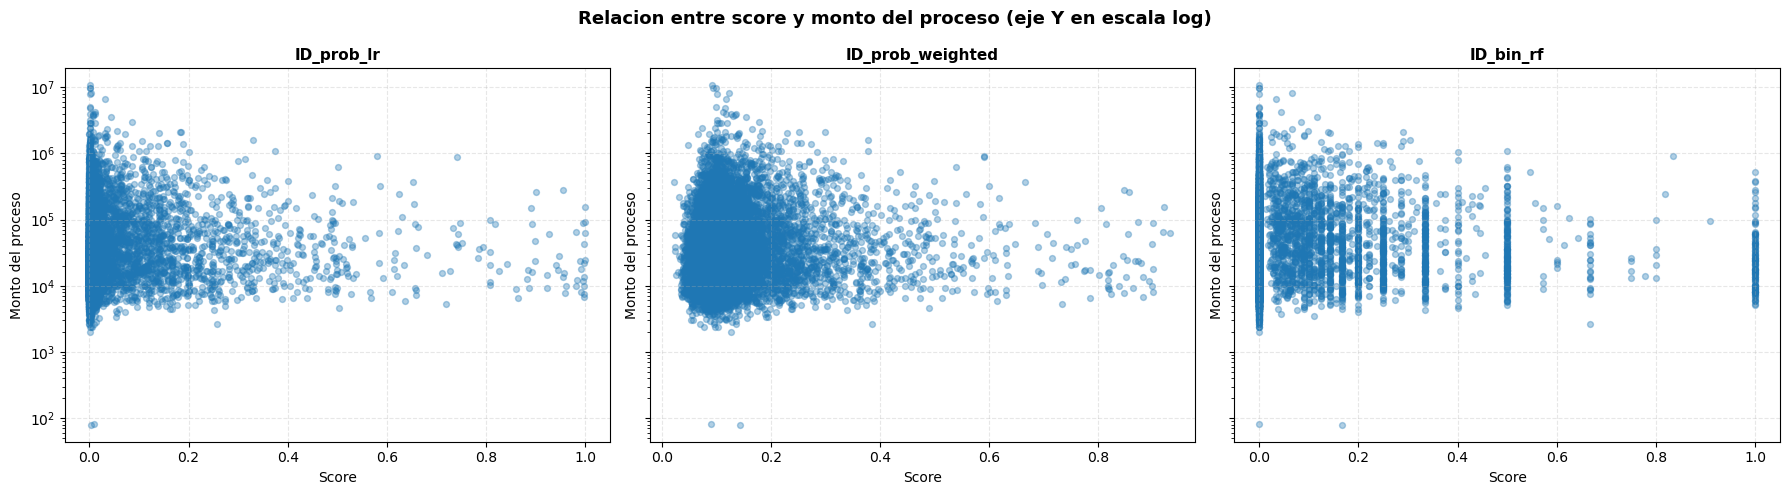


Top 20 procesos por ID_prob_lr y su posicion en monto global


,rank_score,contract_id,ID_prob_lr,monto_proceso,monto_proceso_num,rank_monto_global,percentil_monto_global
0,1,1638753,0.999923,"$152,713.13",152713.13,1480,0.876193
1,2,1652176,0.999369,"$62,980.00",62980.00,3381,0.717018
2,3,1633861,0.998307,"$91,300.00",91300.00,2429,0.796752
3,4,1626772,0.998267,"$24,316.00",24316.00,6713,0.438138
4,5,1667936,0.998032,"$7,570.00",7570.00,11137,0.067763
5,6,1660294,0.997643,"$13,350.00",13350.00,9184,0.231207
6,7,1661524,0.997643,"$6,738.00",6738.00,11445,0.042022
7,8,1614927,0.997637,"$42,104.00",42104.00,4637,0.611920
8,9,1637005,0.996655,"$9,949.00",9949.00,10290,0.138708
9,10,1612054,0.996513,"$21,800.00",21800.00,7117,0.404152



Top 20 procesos por ID_prob_weighted y su posicion en monto global


,rank_score,contract_id,ID_prob_weighted,monto_proceso,monto_proceso_num,rank_monto_global,percentil_monto_global
0,1,1652176,0.932803,"$62,980.00",62980.00,3381,0.717018
1,2,1638753,0.921469,"$152,713.13",152713.13,1480,0.876193
2,3,1625165,0.919664,"$65,553.00",65553.00,3279,0.725599
3,4,1628664,0.900341,"$87,470.00",87470.00,2531,0.788214
4,5,1637886,0.900242,"$7,999.00",7999.00,10991,0.079985
5,6,1637909,0.900242,"$17,988.00",17988.00,7910,0.337937
6,7,1663585,0.900147,"$9,780.00",9780.00,10367,0.132220
7,8,1614927,0.900130,"$42,104.00",42104.00,4637,0.611920
8,9,1660694,0.893054,"$11,802.00",11802.00,9666,0.190943
9,10,1660294,0.882403,"$13,350.00",13350.00,9184,0.231207



Top 20 procesos por ID_bin_rf y su posicion en monto global


,rank_score,contract_id,ID_bin_rf,monto_proceso,monto_proceso_num,rank_monto_global,percentil_monto_global
0,1,1611821,1.0,"$53,400.00",53400.00,3879,0.675373
1,2,1612054,1.0,"$21,800.00",21800.00,7117,0.404152
2,3,1612243,1.0,"$59,182.50",59182.50,3534,0.704252
3,4,1613841,1.0,"$6,442.03",6442.03,11536,0.034405
4,5,1614927,1.0,"$42,104.00",42104.00,4637,0.611920
5,6,1615016,1.0,"$53,144.00",53144.00,3891,0.674368
6,7,1616457,1.0,"$263,000.00",263000.00,785,0.934371
7,8,1616717,1.0,"$30,440.00",30440.00,5875,0.508287
8,9,1617246,1.0,"$5,970.00",5970.00,11668,0.023355
9,10,1618537,1.0,"$17,250.00",17250.00,8097,0.322242


In [19]:
# -- Relacion entre score y monto del proceso --------------------------------
import csv
import matplotlib.pyplot as plt

SCORE_AMOUNT_COLUMNS = [
    "ID_prob_lr",
    "ID_prob_weighted",
    "ID_bin_rf",
]
SCORE_AMOUNT_TOP_N = 20
SCORE_AMOUNT_TOP_SHARE = 0.10


def parse_monto_proceso(value: object) -> float:
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "":
        return np.nan

    text = re.sub(r"[^0-9,.-]", "", text)
    if text in {"", "-", ".", ",", "-.", "-,"}:
        return np.nan

    if "," in text and "." in text:
        if text.rfind(",") > text.rfind("."):
            text = text.replace(".", "").replace(",", ".")
        else:
            text = text.replace(",", "")
    elif "," in text:
        last_chunk = text.split(",")[-1]
        if len(last_chunk) in {1, 2}:
            text = text.replace(",", ".")
        else:
            text = text.replace(",", "")

    try:
        return float(text)
    except ValueError:
        return np.nan


def load_process_amounts(paths: Paths) -> pd.DataFrame:
    raw_path = paths.codes_dir / "preguntas_2021.csv"
    raw_lines = pd.read_csv(raw_path, header=None, dtype=str, encoding="utf-8").iloc[:, 0].astype(str).tolist()
    rows = list(csv.reader(raw_lines))
    questions_df = pd.DataFrame(rows[1:], columns=rows[0])
    questions_df["contract_id"] = questions_df["contract_id"].astype(str).str.strip()

    monto_series = (
        questions_df["monto_adjudicacion"]
        .fillna("")
        .where(questions_df["monto_adjudicacion"].fillna("").str.strip() != "", questions_df["monto_contrato"].fillna(""))
        .where(lambda s: s.fillna("").str.strip() != "", questions_df["presupuesto_referencial_total_sin_iva"].fillna(""))
    )

    amount_df = (
        questions_df.assign(monto_proceso=monto_series.astype(str).str.strip())
        .groupby("contract_id", as_index=False)
        .agg(monto_proceso=("monto_proceso", "first"))
    )
    amount_df["contract_id"] = amount_df["contract_id"].astype(str)
    amount_df["monto_proceso_num"] = amount_df["monto_proceso"].map(parse_monto_proceso)
    return amount_df


def build_score_amount_df(indices_df: pd.DataFrame, amount_df: pd.DataFrame) -> pd.DataFrame:
    merged = (
        indices_df.assign(contract_id=lambda d: d["contract_id"].astype(str))
        .merge(amount_df, on="contract_id", how="left")
    )

    merged["log_monto_proceso"] = np.log1p(merged["monto_proceso_num"])
    return merged


def spearman_corr(series_a: pd.Series, series_b: pd.Series) -> float:
    valid = pd.concat([series_a, series_b], axis=1).dropna()
    if len(valid) < 3:
        return np.nan
    return valid.iloc[:, 0].rank(method="average").corr(valid.iloc[:, 1].rank(method="average"))


def pearson_corr(series_a: pd.Series, series_b: pd.Series) -> float:
    valid = pd.concat([series_a, series_b], axis=1).dropna()
    if len(valid) < 3:
        return np.nan
    return valid.iloc[:, 0].corr(valid.iloc[:, 1])


def summarize_score_amount_relationship(df: pd.DataFrame, index_cols: list[str], top_share: float) -> pd.DataFrame:
    valid_amount_df = df[df["monto_proceso_num"].notna() & (df["monto_proceso_num"] > 0)].copy()
    if valid_amount_df.empty:
        return pd.DataFrame()

    overall_median = float(valid_amount_df["monto_proceso_num"].median())
    overall_mean = float(valid_amount_df["monto_proceso_num"].mean())
    top_n = max(1, int(np.ceil(len(valid_amount_df) * top_share)))

    rows = []
    for col in index_cols:
        pair_df = valid_amount_df[[col, "monto_proceso_num", "log_monto_proceso", "contract_id"]].dropna().copy()
        if pair_df.empty:
            continue

        top_df = pair_df.nlargest(top_n, col).copy()
        top_amount_share = float(top_df["monto_proceso_num"].sum() / pair_df["monto_proceso_num"].sum())
        rows.append(
            {
                "indice": col,
                "n_procesos_con_monto": len(pair_df),
                "spearman_score_vs_monto": spearman_corr(pair_df[col], pair_df["monto_proceso_num"]),
                "pearson_score_vs_log_monto": pearson_corr(pair_df[col], pair_df["log_monto_proceso"]),
                "mediana_monto_total": overall_median,
                "media_monto_total": overall_mean,
                "top_share_score": top_share,
                "top_n_score": len(top_df),
                "mediana_monto_top_score": float(top_df["monto_proceso_num"].median()),
                "media_monto_top_score": float(top_df["monto_proceso_num"].mean()),
                "ratio_mediana_top_vs_total": float(top_df["monto_proceso_num"].median() / overall_median) if overall_median > 0 else np.nan,
                "ratio_media_top_vs_total": float(top_df["monto_proceso_num"].mean() / overall_mean) if overall_mean > 0 else np.nan,
                "share_monto_capturada_por_top_score": top_amount_share,
            }
        )

    return pd.DataFrame(rows).sort_values("spearman_score_vs_monto", ascending=False).reset_index(drop=True)


def build_top_score_amount_tables(df: pd.DataFrame, index_cols: list[str], top_n: int) -> dict[str, pd.DataFrame]:
    valid_amount_df = df[df["monto_proceso_num"].notna() & (df["monto_proceso_num"] > 0)].copy()
    tables: dict[str, pd.DataFrame] = {}

    if valid_amount_df.empty:
        return tables

    for col in index_cols:
        table = (
            valid_amount_df[["contract_id", "monto_proceso", "monto_proceso_num", col]]
            .dropna(subset=[col])
            .nlargest(top_n, col)
            .copy()
        )
        table["rank_score"] = np.arange(1, len(table) + 1)
        table["rank_monto_global"] = (
            valid_amount_df["monto_proceso_num"].rank(method="min", ascending=False)
            .reindex(table.index)
            .astype("Int64")
        )
        table["percentil_monto_global"] = (
            valid_amount_df["monto_proceso_num"].rank(method="average", pct=True)
            .reindex(table.index)
        )
        tables[col] = table[
            ["rank_score", "contract_id", col, "monto_proceso", "monto_proceso_num", "rank_monto_global", "percentil_monto_global"]
        ].reset_index(drop=True)

    return tables


def interpret_score_amount_relationship(summary_df: pd.DataFrame) -> None:
    if summary_df.empty:
        return

    def describe_strength(value: float) -> str:
        if pd.isna(value):
            return "sin evidencia suficiente"
        abs_value = abs(value)
        if abs_value >= 0.50:
            return "relacion fuerte"
        if abs_value >= 0.30:
            return "relacion moderada"
        if abs_value >= 0.10:
            return "relacion debil"
        return "relacion casi nula"

    print("\nLectura rapida por indice")
    for row in summary_df.itertuples(index=False):
        strength = describe_strength(row.spearman_score_vs_monto)
        direction = "positiva" if pd.notna(row.spearman_score_vs_monto) and row.spearman_score_vs_monto >= 0 else "negativa"
        print(
            f"- {row.indice}: Spearman={row.spearman_score_vs_monto:.3f}, "
            f"Pearson(score vs log monto)={row.pearson_score_vs_log_monto:.3f}, "
            f"{strength} {direction}; "
            f"la mediana del top {int(row.top_share_score * 100)}% por score es "
            f"{row.ratio_mediana_top_vs_total:.2f}x la mediana general."
        )


def plot_score_vs_amount(df: pd.DataFrame, index_cols: list[str]) -> None:
    valid_amount_df = df[df["monto_proceso_num"].notna() & (df["monto_proceso_num"] > 0)].copy()
    if valid_amount_df.empty:
        print("No hay montos numericos validos para graficar.")
        return

    fig, axes = plt.subplots(1, len(index_cols), figsize=(6 * len(index_cols), 5), sharey=True)
    if len(index_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, index_cols):
        pair_df = valid_amount_df[[col, "monto_proceso_num"]].dropna()
        ax.scatter(pair_df[col], pair_df["monto_proceso_num"], alpha=0.35, s=18, color="#1f77b4")
        ax.set_title(col, fontsize=11, fontweight="bold")
        ax.set_xlabel("Score")
        ax.set_ylabel("Monto del proceso")
        ax.set_yscale("log")
        ax.grid(alpha=0.3, linestyle="--")

    fig.suptitle("Relacion entre score y monto del proceso (eje Y en escala log)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


_score_amount_paths = default_paths()
score_amount_source_df = load_process_amounts(_score_amount_paths)
score_amount_df = build_score_amount_df(indices_df, score_amount_source_df)
score_amount_summary = summarize_score_amount_relationship(
    score_amount_df,
    SCORE_AMOUNT_COLUMNS,
    top_share=SCORE_AMOUNT_TOP_SHARE,
)
score_amount_top_tables = build_top_score_amount_tables(
    score_amount_df,
    SCORE_AMOUNT_COLUMNS,
    top_n=SCORE_AMOUNT_TOP_N,
)

valid_score_amount_n = int(score_amount_df["monto_proceso_num"].notna().sum())
print(f"Procesos con monto numerico interpretable: {valid_score_amount_n:,}")
if not score_amount_summary.empty:
    display(score_amount_summary)
    interpret_score_amount_relationship(score_amount_summary)
    plot_score_vs_amount(score_amount_df, SCORE_AMOUNT_COLUMNS)

    for col in SCORE_AMOUNT_COLUMNS:
        print(f"\nTop {SCORE_AMOUNT_TOP_N} procesos por {col} y su posicion en monto global")
        display(score_amount_top_tables[col])
else:
    print("No fue posible construir la comparacion score-vs-monto con los datos disponibles.")


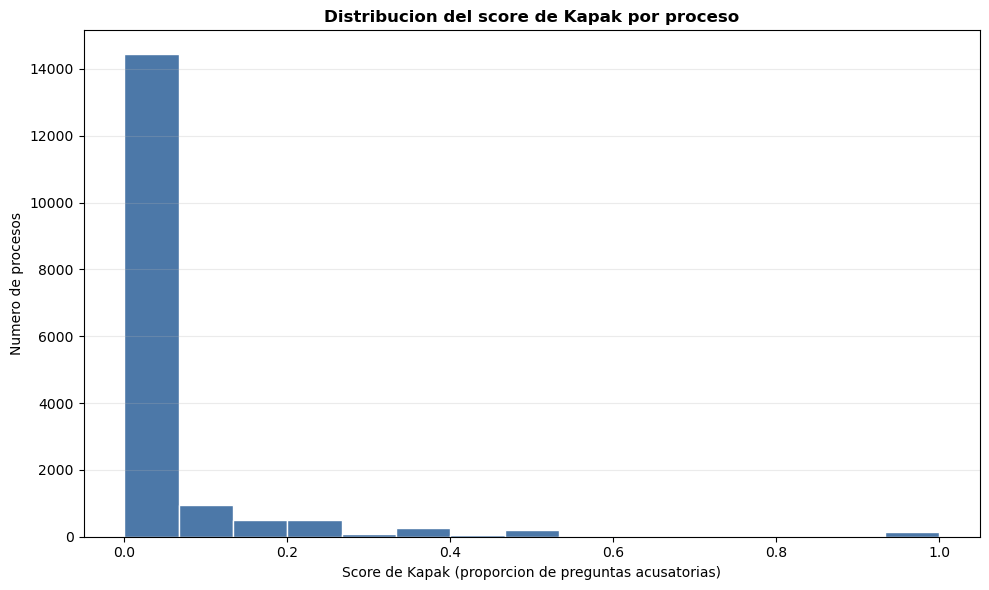

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

kapak_path = Path("preguntas_2021.csv")

raw_lines = pd.read_csv(
    kapak_path,
    header=None,
    dtype=str,
    encoding="utf-8",
).iloc[:, 0].astype(str).tolist()

rows = list(csv.reader(raw_lines))
kapak_df = pd.DataFrame(rows[1:], columns=rows[0])

kapak_df["contract_id"] = kapak_df["contract_id"].astype(str).str.strip()
kapak_df["es_acusatoria_bin"] = (
    kapak_df["es_acusatoria"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": 1, "false": 0})
)

kapak_score_df = (
    kapak_df.dropna(subset=["contract_id", "es_acusatoria_bin"])
    .groupby("contract_id", as_index=False)
    .agg(
        total_preguntas=("es_acusatoria_bin", "size"),
        preguntas_acusatorias=("es_acusatoria_bin", "sum"),
    )
)
kapak_score_df["kapak_score"] = (
    kapak_score_df["preguntas_acusatorias"] / kapak_score_df["total_preguntas"]
)

plt.figure(figsize=(10, 6))
plt.hist(
    kapak_score_df["kapak_score"],
    bins=15,
    color="#4C78A8",
    edgecolor="white",
    linewidth=1,
)
plt.title("Distribucion del score de Kapak por proceso", fontweight="bold")
plt.xlabel("Score de Kapak (proporcion de preguntas acusatorias)")
plt.ylabel("Numero de procesos")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


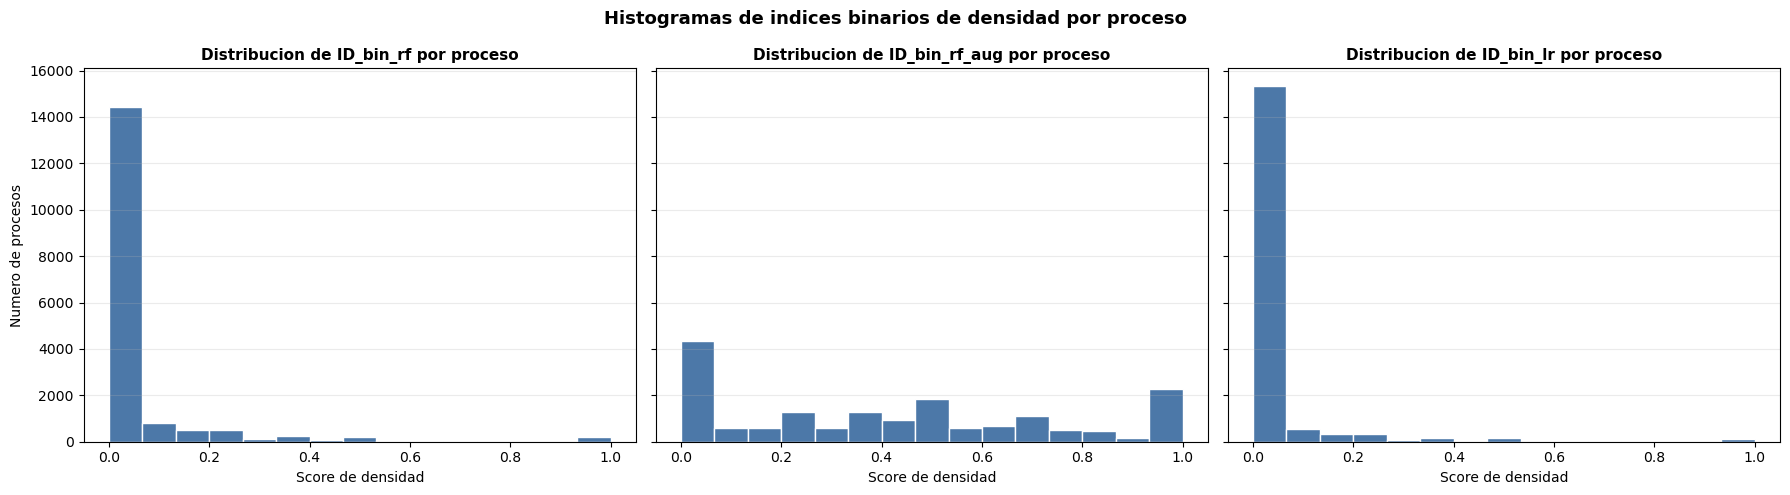

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

indices_path = Path("output/2021/indices_per_process.csv")
bin_cols = ["ID_bin_rf", "ID_bin_rf_aug", "ID_bin_lr"]
titles = {
    "ID_bin_rf": "Distribucion de ID_bin_rf por proceso",
    "ID_bin_rf_aug": "Distribucion de ID_bin_rf_aug por proceso",
    "ID_bin_lr": "Distribucion de ID_bin_lr por proceso",
}

bin_df = pd.read_csv(indices_path, usecols=["contract_id", "n_preguntas", *bin_cols])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, col in zip(axes, bin_cols):
    series = pd.to_numeric(bin_df[col], errors="coerce").dropna()
    ax.hist(
        series,
        bins=15,
        color="#4C78A8",
        edgecolor="white",
        linewidth=1,
    )
    ax.set_title(titles[col], fontsize=11, fontweight="bold")
    ax.set_xlabel("Score de densidad")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Numero de procesos")
fig.suptitle("Histogramas de indices binarios de densidad por proceso", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


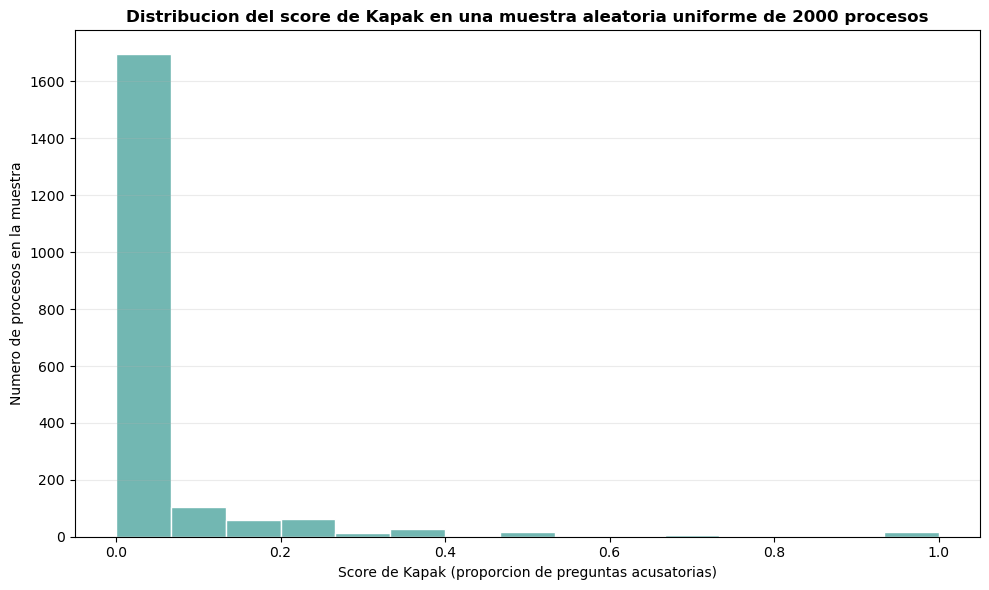

In [3]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

kapak_path = Path("preguntas_2021.csv")
sample_size = 2000
random_seed = 42

raw_lines = pd.read_csv(
    kapak_path,
    header=None,
    dtype=str,
    encoding="utf-8",
).iloc[:, 0].astype(str).tolist()

rows = list(csv.reader(raw_lines))
kapak_df = pd.DataFrame(rows[1:], columns=rows[0])

kapak_df["contract_id"] = kapak_df["contract_id"].astype(str).str.strip()
kapak_df["es_acusatoria_bin"] = (
    kapak_df["es_acusatoria"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": 1, "false": 0})
)

kapak_score_df = (
    kapak_df.dropna(subset=["contract_id", "es_acusatoria_bin"])
    .groupby("contract_id", as_index=False)
    .agg(
        total_preguntas=("es_acusatoria_bin", "size"),
        preguntas_acusatorias=("es_acusatoria_bin", "sum"),
    )
)
kapak_score_df["kapak_score"] = (
    kapak_score_df["preguntas_acusatorias"] / kapak_score_df["total_preguntas"]
)

kapak_sample_df = kapak_score_df.sample(n=sample_size, random_state=random_seed)

plt.figure(figsize=(10, 6))
plt.hist(
    kapak_sample_df["kapak_score"],
    bins=15,
    color="#72B7B2",
    edgecolor="white",
    linewidth=1,
)
plt.title("Distribucion del score de Kapak en una muestra aleatoria uniforme de 2000 procesos", fontweight="bold")
plt.xlabel("Score de Kapak (proporcion de preguntas acusatorias)")
plt.ylabel("Numero de procesos en la muestra")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [4]:
import csv
from pathlib import Path

import numpy as np
import pandas as pd


def wasserstein_distance_1d(x: pd.Series, y: pd.Series) -> float:
    x_arr = np.sort(pd.to_numeric(x, errors="coerce").dropna().to_numpy(dtype=float, copy=False))
    y_arr = np.sort(pd.to_numeric(y, errors="coerce").dropna().to_numpy(dtype=float, copy=False))
    if len(x_arr) == 0 or len(y_arr) == 0:
        return float("nan")

    values = np.sort(np.unique(np.concatenate([x_arr, y_arr])))
    if len(values) == 1:
        return 0.0

    x_cdf = np.searchsorted(x_arr, values[:-1], side="right") / len(x_arr)
    y_cdf = np.searchsorted(y_arr, values[:-1], side="right") / len(y_arr)
    deltas = np.diff(values)
    return float(np.sum(np.abs(x_cdf - y_cdf) * deltas))


def ks_statistic_1d(x: pd.Series, y: pd.Series) -> float:
    x_arr = np.sort(pd.to_numeric(x, errors="coerce").dropna().to_numpy(dtype=float, copy=False))
    y_arr = np.sort(pd.to_numeric(y, errors="coerce").dropna().to_numpy(dtype=float, copy=False))
    if len(x_arr) == 0 or len(y_arr) == 0:
        return float("nan")

    values = np.sort(np.unique(np.concatenate([x_arr, y_arr])))
    x_cdf = np.searchsorted(x_arr, values, side="right") / len(x_arr)
    y_cdf = np.searchsorted(y_arr, values, side="right") / len(y_arr)
    return float(np.max(np.abs(x_cdf - y_cdf)))


kapak_path = Path("preguntas_2021.csv")
indices_path = Path("output/2021/indices_per_process.csv")
index_columns = [
    "ID_bin_rf",
    "ID_bin_rf_aug",
    "ID_bin_lr",
    "ID_prob_rf",
    "ID_prob_rf_aug",
    "ID_prob_lr",
    "ID_prob_weighted",
]

raw_lines = pd.read_csv(
    kapak_path,
    header=None,
    dtype=str,
    encoding="utf-8",
).iloc[:, 0].astype(str).tolist()
rows = list(csv.reader(raw_lines))
kapak_df = pd.DataFrame(rows[1:], columns=rows[0])
kapak_df["contract_id"] = kapak_df["contract_id"].astype(str).str.strip()
kapak_df["es_acusatoria_bin"] = (
    kapak_df["es_acusatoria"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": 1, "false": 0})
)

kapak_score_df = (
    kapak_df.dropna(subset=["contract_id", "es_acusatoria_bin"])
    .groupby("contract_id", as_index=False)
    .agg(
        kapak_n_preguntas=("es_acusatoria_bin", "size"),
        kapak_n_acusatorias=("es_acusatoria_bin", "sum"),
    )
)
kapak_score_df["kapak_score"] = (
    kapak_score_df["kapak_n_acusatorias"] / kapak_score_df["kapak_n_preguntas"]
)

indices_df = pd.read_csv(indices_path, usecols=["contract_id", "n_preguntas", *index_columns])
indices_df["contract_id"] = indices_df["contract_id"].astype(str).str.strip()

comparison_df = kapak_score_df[["contract_id", "kapak_score"]].merge(
    indices_df,
    on="contract_id",
    how="inner",
)

rows_out = []
for col in index_columns:
    pair_df = comparison_df[["kapak_score", col]].dropna()
    rows_out.append(
        {
            "model": col,
            "n_procesos": int(len(pair_df)),
            "kapak_mean": float(pair_df["kapak_score"].mean()),
            "model_mean": float(pair_df[col].mean()),
            "wasserstein_distance": wasserstein_distance_1d(pair_df["kapak_score"], pair_df[col]),
            "ks_statistic": ks_statistic_1d(pair_df["kapak_score"], pair_df[col]),
        }
    )

distribution_distance_df = pd.DataFrame(rows_out).sort_values(
    ["wasserstein_distance", "ks_statistic", "model"],
    ascending=[True, True, True],
).reset_index(drop=True)

distribution_distance_df


,model,n_procesos,kapak_mean,model_mean,wasserstein_distance,ks_statistic
0,ID_bin_rf,17152,0.041323,0.046192,0.004869,0.010844
1,ID_prob_lr,17152,0.041323,0.034142,0.010956,0.808594
2,ID_bin_lr,17152,0.041323,0.029787,0.011535,0.063899
3,ID_prob_weighted,17152,0.041323,0.132337,0.097131,0.817397
4,ID_prob_rf,17152,0.041323,0.220298,0.184685,0.846024
5,ID_bin_rf_aug,17152,0.041323,0.408412,0.367089,0.612057
6,ID_prob_rf_aug,17152,0.041323,0.488084,0.448295,0.945896


## Indices normalizados

Para hacer comparables los indices entre si, esta seccion calcula versiones normalizadas con z-score y las exporta a `indices_per_process_normalized.csv`.


In [13]:
indices_df = pd.read_csv("output/2021/indices_per_process.csv")
indices_df.head(10)

,contract_id,n_preguntas,ID_bin_rf,ID_bin_rf_aug,ID_bin_lr,ID_prob_rf,ID_prob_rf_aug,ID_prob_lr,ID_prob_weighted
0,1608622,9,0.0,0.777778,0.0,0.256667,0.596667,0.028370,0.149400
1,1608717,4,0.0,1.000000,0.0,0.221250,0.618750,0.005547,0.123893
2,1608968,3,0.0,0.000000,0.0,0.078333,0.283333,0.000368,0.046355
3,1609087,2,0.0,0.000000,0.0,0.160000,0.422500,0.000001,0.086091
4,1609116,13,0.0,0.461538,0.0,0.206154,0.510769,0.001334,0.109896
5,1609119,2,0.0,1.000000,0.0,0.345000,0.640000,0.001760,0.172409
6,1609206,1,0.0,0.000000,0.0,0.200000,0.380000,0.000003,0.099860
7,1609217,19,0.0,0.578947,0.0,0.190789,0.540526,0.000491,0.104849
8,1609219,2,0.0,0.000000,0.0,0.175000,0.395000,0.000017,0.090658
9,1609235,2,0.5,1.000000,0.5,0.642500,0.880000,0.522960,0.589447


In [16]:
INDEX_COLUMNS = [
    "ID_bin_rf",
    "ID_bin_rf_aug",
    "ID_bin_lr",
    "ID_prob_rf",
    "ID_prob_rf_aug",
    "ID_prob_lr",
    "ID_prob_weighted",
]

def zscore_normalize_indices(df: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    normalized_df = df.copy()
    for col in index_columns:
        mean = normalized_df[col].mean()
        std = normalized_df[col].std(ddof=0)
        out_col = f"{col}_zscore"
        if std == 0 or pd.isna(std):
            normalized_df[out_col] = 0.0
        else:
            normalized_df[out_col] = (normalized_df[col] - mean) / std
    return normalized_df

normalized_indices_df = zscore_normalize_indices(indices_df, INDEX_COLUMNS)
normalized_output_path = default_paths().output_dir / "indices_per_process_normalized.csv"
normalized_indices_df.to_csv(normalized_output_path, index=False)

print(f"Archivo generado: {normalized_output_path}")
normalized_indices_df.head(10)

Archivo generado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\indices_per_process_normalized.csv


,contract_id,n_preguntas,ID_bin_rf,ID_bin_rf_aug,ID_bin_lr,ID_prob_rf,ID_prob_rf_aug,ID_prob_lr,ID_prob_weighted,ID_bin_rf_zscore,ID_bin_rf_aug_zscore,ID_bin_lr_zscore,ID_prob_rf_zscore,ID_prob_rf_aug_zscore,ID_prob_lr_zscore,ID_prob_weighted_zscore
0,1608622,9,0.0,0.777778,0.0,0.256667,0.596667,0.028370,0.149400,-0.331600,1.092650,-0.264623,0.387719,0.941436,-0.056041,0.187756
1,1608717,4,0.0,1.000000,0.0,0.221250,0.618750,0.005547,0.123893,-0.331600,1.750024,-0.264623,0.010147,1.132903,-0.277652,-0.092909
2,1608968,3,0.0,0.000000,0.0,0.078333,0.283333,0.000368,0.046355,-0.331600,-1.208156,-0.264623,-1.513469,-1.775230,-0.327932,-0.946082
3,1609087,2,0.0,0.000000,0.0,0.160000,0.422500,0.000001,0.086091,-0.331600,-1.208156,-0.264623,-0.642832,-0.568625,-0.331498,-0.508848
4,1609116,13,0.0,0.461538,0.0,0.206154,0.510769,0.001334,0.109896,-0.331600,0.157158,-0.264623,-0.150791,0.196687,-0.318554,-0.246918
5,1609119,2,0.0,1.000000,0.0,0.345000,0.640000,0.001760,0.172409,-0.331600,1.750024,-0.264623,1.329429,1.317145,-0.314416,0.440929
6,1609206,1,0.0,0.000000,0.0,0.200000,0.380000,0.000003,0.099860,-0.331600,-1.208156,-0.264623,-0.216397,-0.937109,-0.331484,-0.357347
7,1609217,19,0.0,0.578947,0.0,0.190789,0.540526,0.000491,0.104849,-0.331600,0.504474,-0.264623,-0.314589,0.454687,-0.326745,-0.302454
8,1609219,2,0.0,0.000000,0.0,0.175000,0.395000,0.000017,0.090658,-0.331600,-1.208156,-0.264623,-0.482918,-0.807056,-0.331340,-0.458601
9,1609235,2,0.5,1.000000,0.5,0.642500,0.880000,0.522960,0.589447,3.257804,1.750024,4.177249,4.501037,3.397995,4.746312,5.029704


### Normalizacion por rango percentil

Mapea cada valor de indice a su posicion percentil dentro del dataset (0â€“100). No asume ninguna distribucion subyacente y es completamente robusto a outliers. Un valor de 99 significa que ese proceso supera al 99 % de los demas en ese indice.

In [17]:
def percentile_normalize_indices(df: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    normalized_df = df.copy()
    for col in index_columns:
        normalized_df[f"{col}_pct"] = normalized_df[col].rank(pct=True) * 100
    return normalized_df

percentile_indices_df = percentile_normalize_indices(indices_df, INDEX_COLUMNS)
percentile_output_path = default_paths().output_dir / "indices_per_process_normalized_percentile.csv"
percentile_indices_df.to_csv(percentile_output_path, index=False)

print(f"Archivo generado: {percentile_output_path}")
percentile_indices_df.head(10)

Archivo generado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\indices_per_process_normalized_percentile.csv


,contract_id,n_preguntas,ID_bin_rf,ID_bin_rf_aug,ID_bin_lr,ID_prob_rf,ID_prob_rf_aug,ID_prob_lr,ID_prob_weighted,ID_bin_rf_pct,ID_bin_rf_aug_pct,ID_bin_lr_pct,ID_prob_rf_pct,ID_prob_rf_aug_pct,ID_prob_lr_pct,ID_prob_weighted_pct
0,1608622,9,0.0,0.777778,0.0,0.256667,0.596667,0.028370,0.149400,40.103195,83.165229,43.610075,74.758046,84.418727,82.322761,77.856810
1,1608717,4,0.0,1.000000,0.0,0.221250,0.618750,0.005547,0.123893,40.103195,93.467234,43.610075,61.179454,88.205457,70.055970,65.018657
2,1608968,3,0.0,0.000000,0.0,0.078333,0.283333,0.000368,0.046355,40.103195,12.185168,43.610075,1.096082,1.947295,37.774021,1.037780
3,1609087,2,0.0,0.000000,0.0,0.160000,0.422500,0.000001,0.086091,40.103195,12.185168,43.610075,24.084655,28.932486,1.731576,23.285914
4,1609116,13,0.0,0.461538,0.0,0.206154,0.510769,0.001334,0.109896,40.103195,55.973064,43.610075,52.775187,62.083139,56.005131,52.897621
5,1609119,2,0.0,1.000000,0.0,0.345000,0.640000,0.001760,0.172409,40.103195,93.467234,43.610075,91.799790,90.939832,59.194263,84.590718
6,1609206,1,0.0,0.000000,0.0,0.200000,0.380000,0.000003,0.099860,40.103195,12.185168,43.610075,48.860191,16.537430,3.119170,39.884562
7,1609217,19,0.0,0.578947,0.0,0.190789,0.540526,0.000491,0.104849,40.103195,69.525420,43.610075,42.922108,71.210354,42.992071,46.746735
8,1609219,2,0.0,0.000000,0.0,0.175000,0.395000,0.000017,0.090658,40.103195,12.185168,43.610075,33.383862,20.385378,9.899720,28.649720
9,1609235,2,0.5,1.000000,0.5,0.642500,0.880000,0.522960,0.589447,97.898204,93.467234,98.650303,99.449044,99.408232,99.090485,99.230410


### Normalizacion por z-score robusto (mediana + IQR)

Sustituye la media y la desviacion estandar por la mediana y el rango intercuartilico (IQR). Al no verse afectado por valores extremos, es mas adecuado para detectar procesos anomalos: los outliers conservan z-scores altos sin comprimir el resto de la distribucion.

In [18]:
def robust_zscore_normalize_indices(df: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    normalized_df = df.copy()
    for col in index_columns:
        median = normalized_df[col].median()
        iqr = normalized_df[col].quantile(0.75) - normalized_df[col].quantile(0.25)
        out_col = f"{col}_robustZ"
        if iqr == 0 or pd.isna(iqr):
            normalized_df[out_col] = 0.0
        else:
            normalized_df[out_col] = (normalized_df[col] - median) / iqr
    return normalized_df

robustz_indices_df = robust_zscore_normalize_indices(indices_df, INDEX_COLUMNS)
robustz_output_path = default_paths().output_dir / "indices_per_process_normalized_robustZ.csv"
robustz_indices_df.to_csv(robustz_output_path, index=False)

print(f"Archivo generado: {robustz_output_path}")
robustz_indices_df.head(10)

Archivo generado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\indices_per_process_normalized_robustZ.csv


,contract_id,n_preguntas,ID_bin_rf,ID_bin_rf_aug,ID_bin_lr,ID_prob_rf,ID_prob_rf_aug,ID_prob_lr,ID_prob_weighted,ID_bin_rf_robustZ,ID_bin_rf_aug_robustZ,ID_bin_lr_robustZ,ID_prob_rf_robustZ,ID_prob_rf_aug_robustZ,ID_prob_lr_robustZ,ID_prob_weighted_robustZ
0,1608622,9,0.0,0.777778,0.0,0.256667,0.596667,0.028370,0.149400,0.0,0.662634,0.0,0.573913,0.804598,2.680155,0.772096
1,1608717,4,0.0,1.000000,0.0,0.221250,0.618750,0.005547,0.123893,0.0,1.028226,0.0,0.204348,0.956897,0.456681,0.304569
2,1608968,3,0.0,0.000000,0.0,0.078333,0.283333,0.000368,0.046355,0.0,-0.616935,0.0,-1.286957,-1.356322,-0.047798,-1.116627
3,1609087,2,0.0,0.000000,0.0,0.160000,0.422500,0.000001,0.086091,0.0,-0.616935,0.0,-0.434783,-0.396552,-0.083580,-0.388292
4,1609116,13,0.0,0.461538,0.0,0.206154,0.510769,0.001334,0.109896,0.0,0.142370,0.0,0.046823,0.212202,0.046291,0.048026
5,1609119,2,0.0,1.000000,0.0,0.345000,0.640000,0.001760,0.172409,0.0,1.028226,0.0,1.495652,1.103448,0.087815,1.193825
6,1609206,1,0.0,0.000000,0.0,0.200000,0.380000,0.000003,0.099860,0.0,-0.616935,0.0,-0.017391,-0.689655,-0.083433,-0.135925
7,1609217,19,0.0,0.578947,0.0,0.190789,0.540526,0.000491,0.104849,0.0,0.335526,0.0,-0.113501,0.417423,-0.035886,-0.044486
8,1609219,2,0.0,0.000000,0.0,0.175000,0.395000,0.000017,0.090658,0.0,-0.616935,0.0,-0.278261,-0.586207,-0.081989,-0.304591
9,1609235,2,0.5,1.000000,0.5,0.642500,0.880000,0.522960,0.589447,0.0,1.028226,0.0,4.600001,2.758621,50.863434,8.837701


## Analisis semanal de procesos

Esta seccion compara procesos entre dos semanas para todos los indices. Por defecto usa las primeras dos semanas disponibles segun la primera fecha de pregunta de cada proceso. Si quieres otras semanas, cambia `SELECTED_WEEKS` manualmente.


In [19]:
import math
import matplotlib.pyplot as plt

RAW_INDEX_COLUMNS = [
    "ID_bin_rf",
    "ID_bin_rf_aug",
    "ID_bin_lr",
    "ID_prob_rf",
    "ID_prob_rf_aug",
    "ID_prob_lr",
    "ID_prob_weighted",
]
ZSCORE_INDEX_COLUMNS = [f"{col}_zscore" for col in RAW_INDEX_COLUMNS]
TOP_K_VALUES = [1, 3, 5]
SELECTED_WEEKS = None  # Ejemplo: ["2021-01-04", "2021-01-11"]


def build_process_week_frame(paths: Paths) -> pd.DataFrame:
    process_dates = pd.read_csv(
        paths.prepared_data_path,
        usecols=["contract_id", "fecha_publicacion"],
        parse_dates=["fecha_publicacion"],
    )
    process_dates["contract_id"] = process_dates["contract_id"].astype(str)
    weekly_df = (
        process_dates.groupby("contract_id", as_index=False)
        .agg(
            first_question_date=("fecha_publicacion", "min"),
            last_question_date=("fecha_publicacion", "max"),
            process_question_count=("fecha_publicacion", "size"),
        )
        .sort_values(["first_question_date", "contract_id"])
        .reset_index(drop=True)
    )
    weekly_df["week_start"] = weekly_df["first_question_date"].dt.to_period("W-SUN").dt.start_time
    weekly_df["week_label"] = weekly_df["week_start"].dt.strftime("%Y-%m-%d")
    return weekly_df


def pick_two_weeks(weekly_df: pd.DataFrame, selected_weeks: list[str] | None) -> list[str]:
    available_weeks = sorted(weekly_df["week_label"].dropna().unique().tolist())
    if selected_weeks is None:
        return available_weeks[:2]
    missing = [week for week in selected_weeks if week not in available_weeks]
    if missing:
        raise ValueError(f"Semanas no disponibles: {missing}")
    return selected_weeks[:2]


def make_axis_grid(total_plots: int, ncols: int = 2, figsize_scale: float = 4.5):
    nrows = math.ceil(total_plots / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, figsize_scale * nrows), squeeze=False)
    flat_axes = axes.flatten()
    for ax in flat_axes[total_plots:]:
        ax.axis("off")
    return fig, flat_axes


def plot_weekly_boxplots(df: pd.DataFrame, zscore_cols: list[str], selected_weeks: list[str]) -> None:
    fig, axes = make_axis_grid(len(zscore_cols), ncols=2, figsize_scale=4.0)
    for ax, col in zip(axes, zscore_cols):
        data = [df.loc[df["week_label"] == week, col].dropna().to_numpy() for week in selected_weeks]
        ax.boxplot(data, labels=selected_weeks, patch_artist=True)
        ax.set_title(f"Boxplot {col}")
        ax.set_xlabel("Semana")
        ax.set_ylabel("Z-score")
        ax.tick_params(axis="x", rotation=20)
    fig.suptitle("Distribucion semanal por indice normalizado", fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_weekly_violins(df: pd.DataFrame, zscore_cols: list[str], selected_weeks: list[str]) -> None:
    fig, axes = make_axis_grid(len(zscore_cols), ncols=2, figsize_scale=4.0)
    for ax, col in zip(axes, zscore_cols):
        data = [df.loc[df["week_label"] == week, col].dropna().to_numpy() for week in selected_weeks]
        parts = ax.violinplot(data, positions=np.arange(1, len(selected_weeks) + 1), showmeans=True, showextrema=True)
        for body in parts["bodies"]:
            body.set_alpha(0.5)
        ax.set_title(f"Violin {col}")
        ax.set_xticks(np.arange(1, len(selected_weeks) + 1))
        ax.set_xticklabels(selected_weeks, rotation=20)
        ax.set_xlabel("Semana")
        ax.set_ylabel("Z-score")
    fig.suptitle("Forma de distribucion semanal por indice normalizado", fontsize=14)
    fig.tight_layout()
    plt.show()


def compute_topk_summary(df: pd.DataFrame, zscore_cols: list[str], selected_weeks: list[str], top_k_values: list[int]) -> pd.DataFrame:
    rows = []
    for week in selected_weeks:
        week_df = df[df["week_label"] == week]
        for col in zscore_cols:
            row = {"week_label": week, "index_name": col, "max": week_df[col].max()}
            for k in top_k_values:
                row[f"top_{k}_mean"] = week_df.nlargest(min(k, len(week_df)), col)[col].mean()
            rows.append(row)
    return pd.DataFrame(rows)


def plot_topk_lines(summary_df: pd.DataFrame, zscore_cols: list[str]) -> None:
    fig, axes = make_axis_grid(len(zscore_cols), ncols=2, figsize_scale=4.0)
    metric_cols = ["max"] + [f"top_{k}_mean" for k in TOP_K_VALUES]
    for ax, col in zip(axes, zscore_cols):
        idx_df = summary_df[summary_df["index_name"] == col].sort_values("week_label")
        for metric in metric_cols:
            ax.plot(idx_df["week_label"], idx_df[metric], marker="o", label=metric)
        ax.set_title(f"Top-k {col}")
        ax.set_xlabel("Semana")
        ax.set_ylabel("Z-score")
        ax.tick_params(axis="x", rotation=20)
        ax.legend(fontsize=8)
    fig.suptitle("Procesos mas altos por semana", fontsize=14)
    fig.tight_layout()
    plt.show()


def compute_concentration_summary(df: pd.DataFrame, raw_cols: list[str], selected_weeks: list[str], top_k_values: list[int]) -> pd.DataFrame:
    rows = []
    for week in selected_weeks:
        week_df = df[df["week_label"] == week]
        for col in raw_cols:
            total = week_df[col].sum()
            row = {"week_label": week, "index_name": col, "total": total}
            for k in top_k_values:
                top_sum = week_df.nlargest(min(k, len(week_df)), col)[col].sum()
                row[f"top_{k}_share"] = 0.0 if total == 0 else top_sum / total
            rows.append(row)
    return pd.DataFrame(rows)


def plot_concentration_bars(summary_df: pd.DataFrame, raw_cols: list[str]) -> None:
    fig, axes = make_axis_grid(len(raw_cols), ncols=2, figsize_scale=4.0)
    share_cols = [f"top_{k}_share" for k in TOP_K_VALUES]
    x = np.arange(len(share_cols))
    for ax, col in zip(axes, raw_cols):
        idx_df = summary_df[summary_df["index_name"] == col].sort_values("week_label")
        width = 0.35
        for pos, (_, row) in enumerate(idx_df.iterrows()):
            values = [row[share_col] for share_col in share_cols]
            ax.bar(x + (pos - 0.5) * width, values, width=width, label=row["week_label"])
        ax.set_title(f"Concentracion {col}")
        ax.set_xticks(x)
        ax.set_xticklabels(share_cols)
        ax.set_ylim(0, 1)
        ax.set_ylabel("Participacion del top-k")
        ax.legend(fontsize=8)
    fig.suptitle("Cuota del riesgo semanal explicada por los procesos mas altos", fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_weekly_heatmaps(df: pd.DataFrame, zscore_cols: list[str], selected_weeks: list[str], top_n: int = 10) -> None:
    fig, axes = make_axis_grid(len(zscore_cols), ncols=2, figsize_scale=4.2)
    for ax, col in zip(axes, zscore_cols):
        heatmap_rows = []
        row_labels = []
        for week in selected_weeks:
            top_values = df.loc[df["week_label"] == week, col].nlargest(top_n).to_numpy()
            padded = np.full(top_n, np.nan)
            padded[: len(top_values)] = top_values
            heatmap_rows.append(padded)
            row_labels.append(week)
        mat = np.vstack(heatmap_rows)
        im = ax.imshow(mat, aspect="auto", cmap="YlOrRd")
        ax.set_title(f"Heatmap top {top_n} {col}")
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_yticklabels(row_labels)
        ax.set_xticks(np.arange(top_n))
        ax.set_xticklabels([f"#{i+1}" for i in range(top_n)], rotation=45)
        ax.set_xlabel("Ranking semanal")
        ax.set_ylabel("Semana")
        fig.colorbar(im, ax=ax, shrink=0.8)
    fig.suptitle("Intensidad de los procesos mas altos por semana", fontsize=14)
    fig.tight_layout()
    plt.show()


paths = default_paths()
process_week_df = build_process_week_frame(paths)
normalized_indices_df["contract_id"] = normalized_indices_df["contract_id"].astype(str)
weekly_process_df = process_week_df.merge(normalized_indices_df, on="contract_id", how="inner")
selected_weeks = pick_two_weeks(weekly_process_df, SELECTED_WEEKS)
weekly_process_df = weekly_process_df[weekly_process_df["week_label"].isin(selected_weeks)].copy()


Semanas seleccionadas: ['2021-01-04', '2021-01-11']
week_label
2021-01-04     6
2021-01-11    17
Name: n_procesos, dtype: int64


C:\Users\samys\AppData\Local\Temp\ipykernel_9800\32012663.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=selected_weeks, patch_artist=True)
C:\Users\samys\AppData\Local\Temp\ipykernel_9800\32012663.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=selected_weeks, patch_artist=True)
C:\Users\samys\AppData\Local\Temp\ipykernel_9800\32012663.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=selected_weeks, patch_artist=True)
C:\Users\samys\AppData\Local\Temp\ipykernel_9800\32012663.py:63: MatplotlibDeprecationWarning: The 'labels' paramet

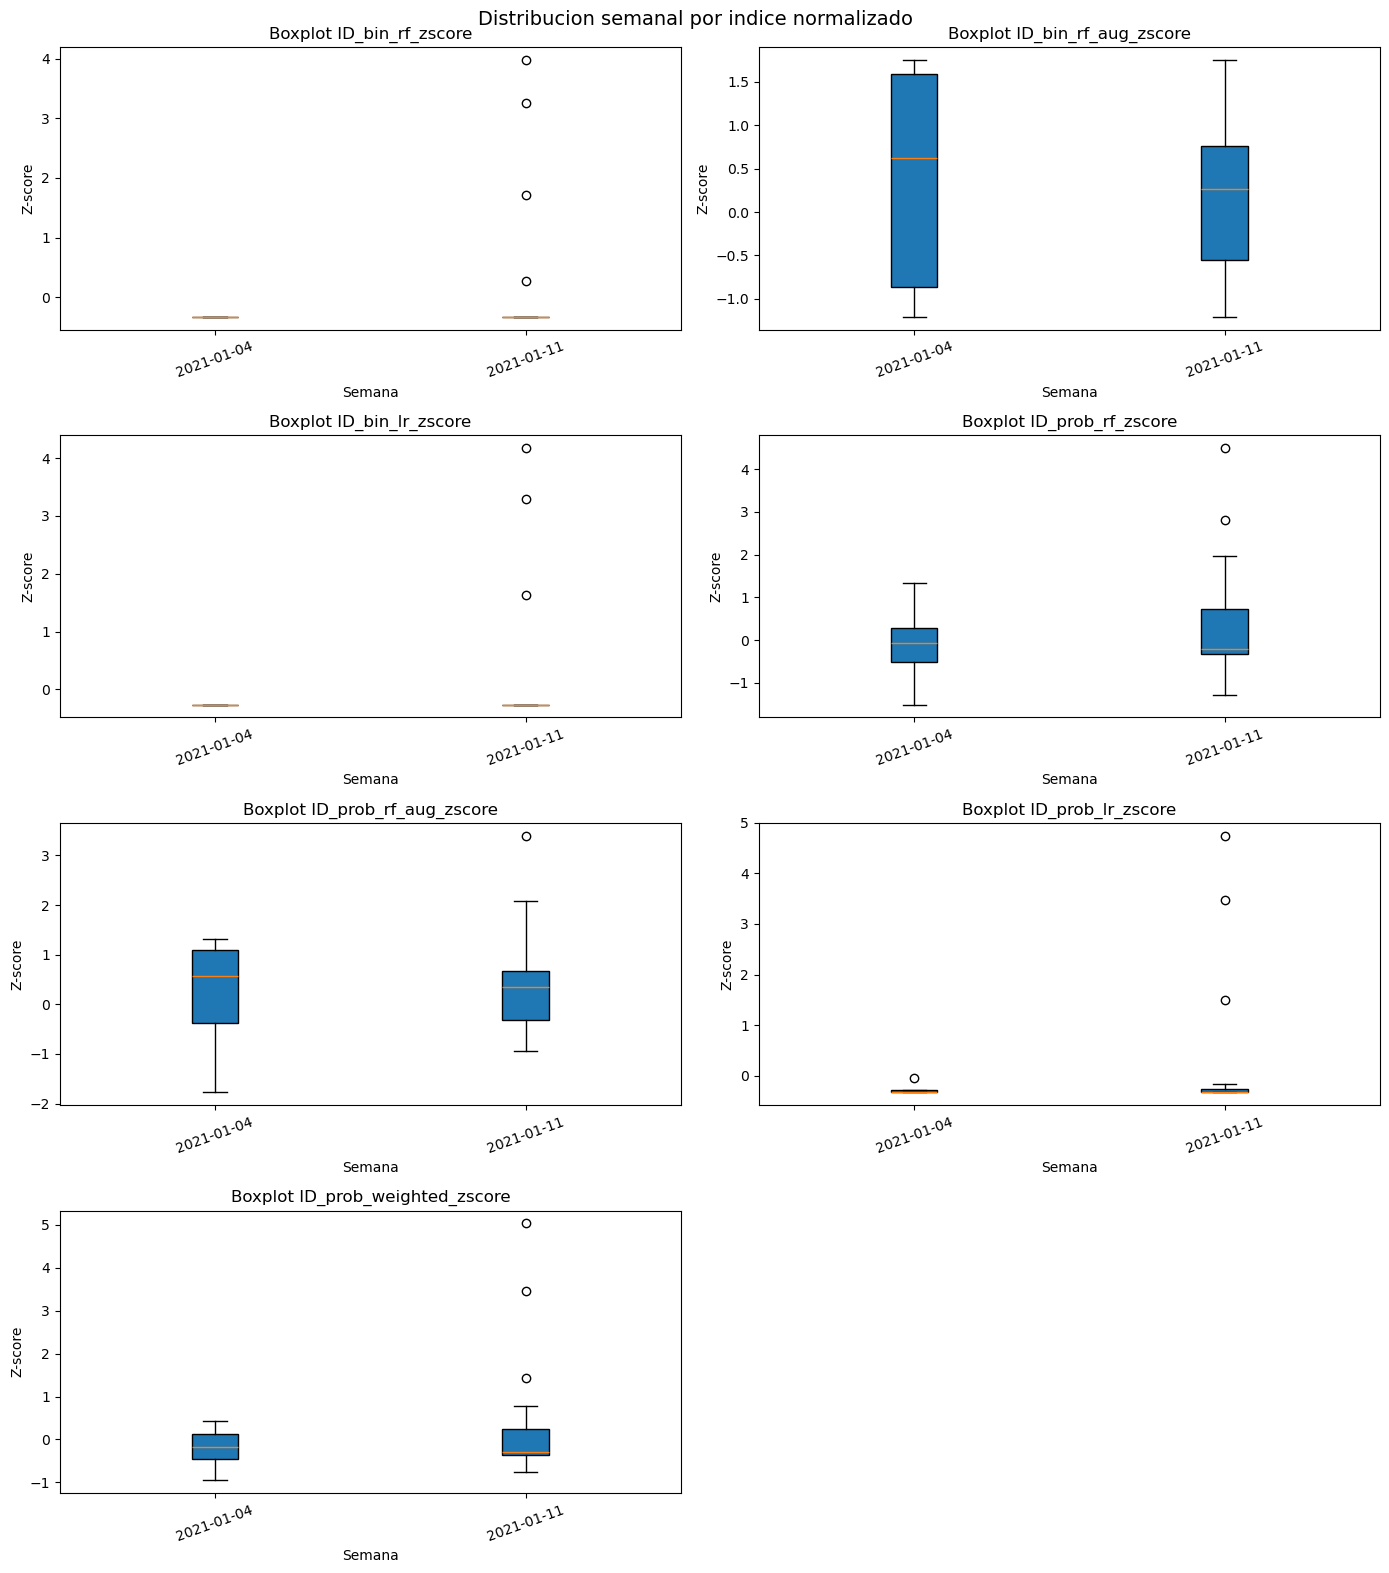

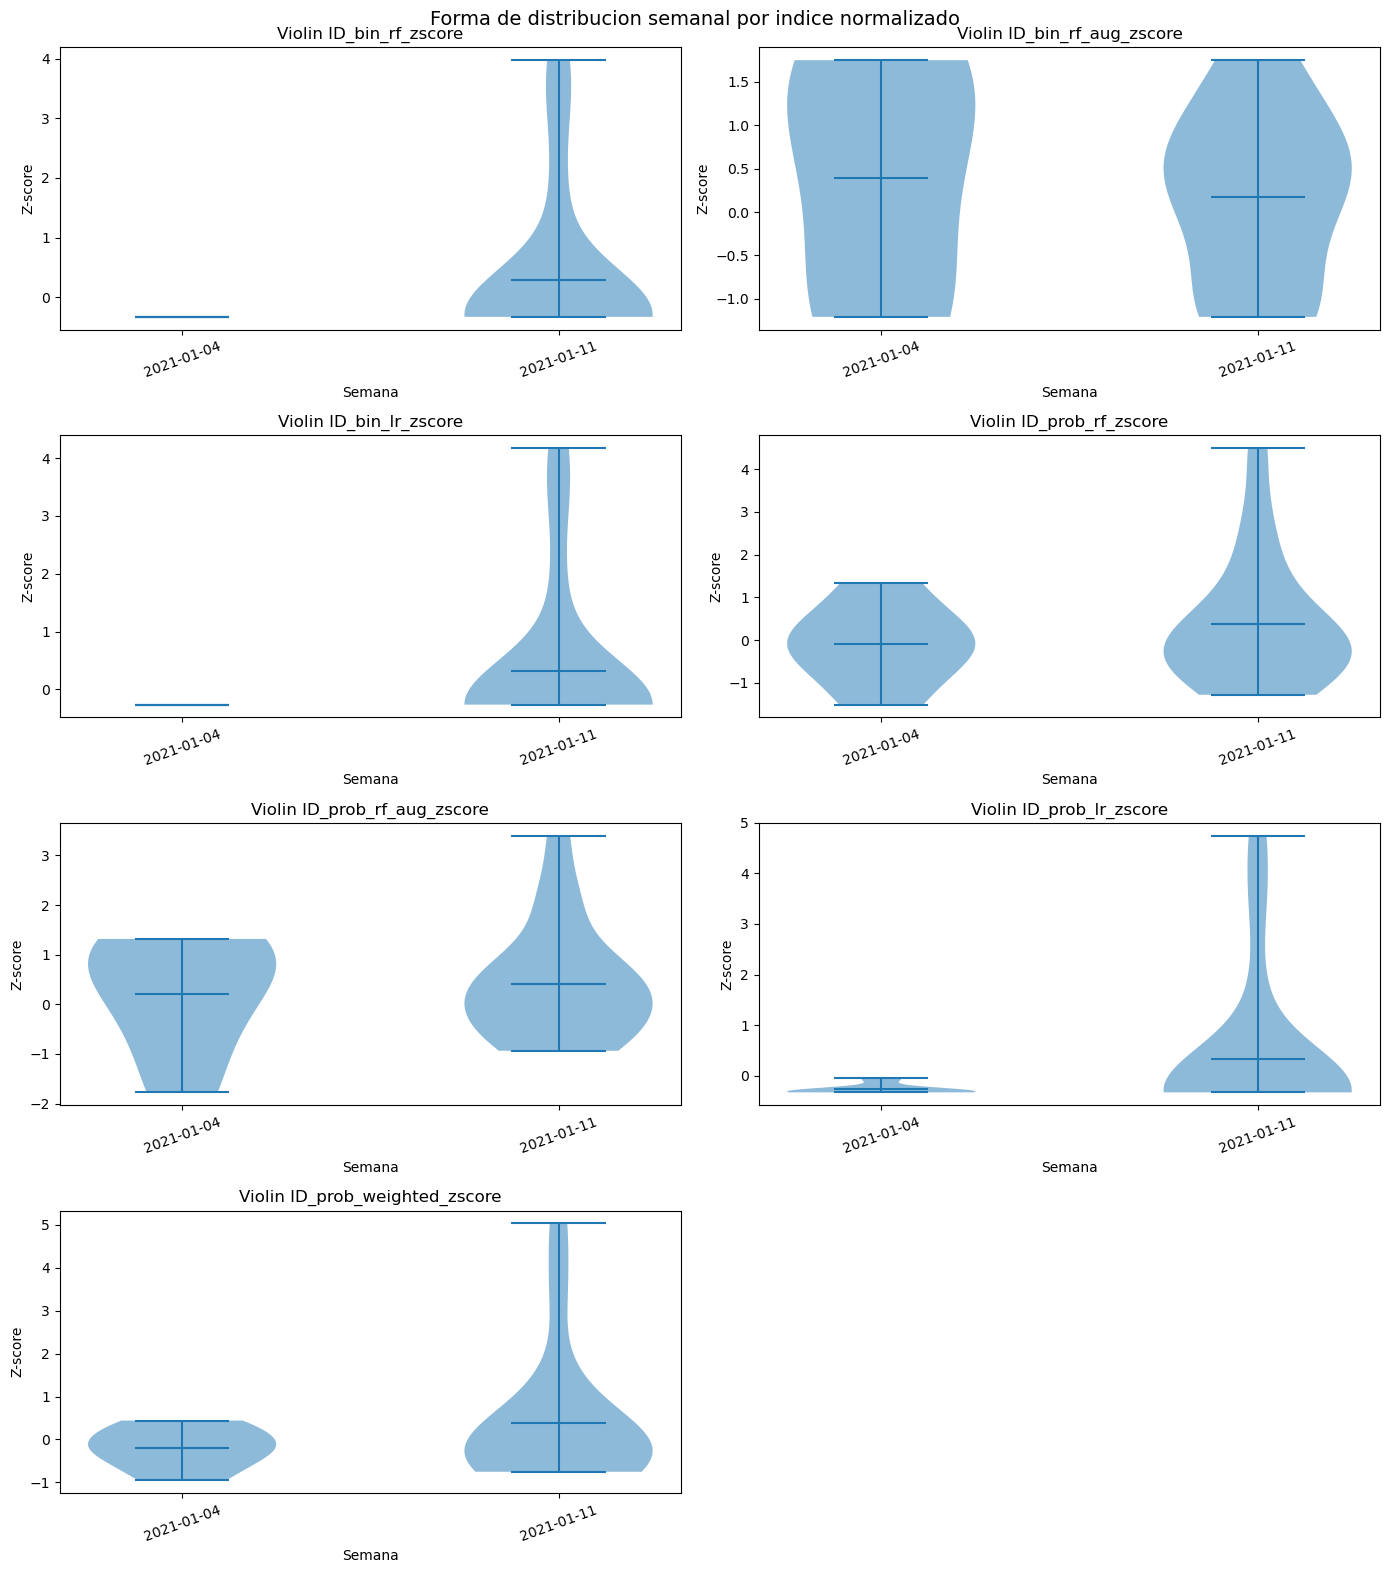

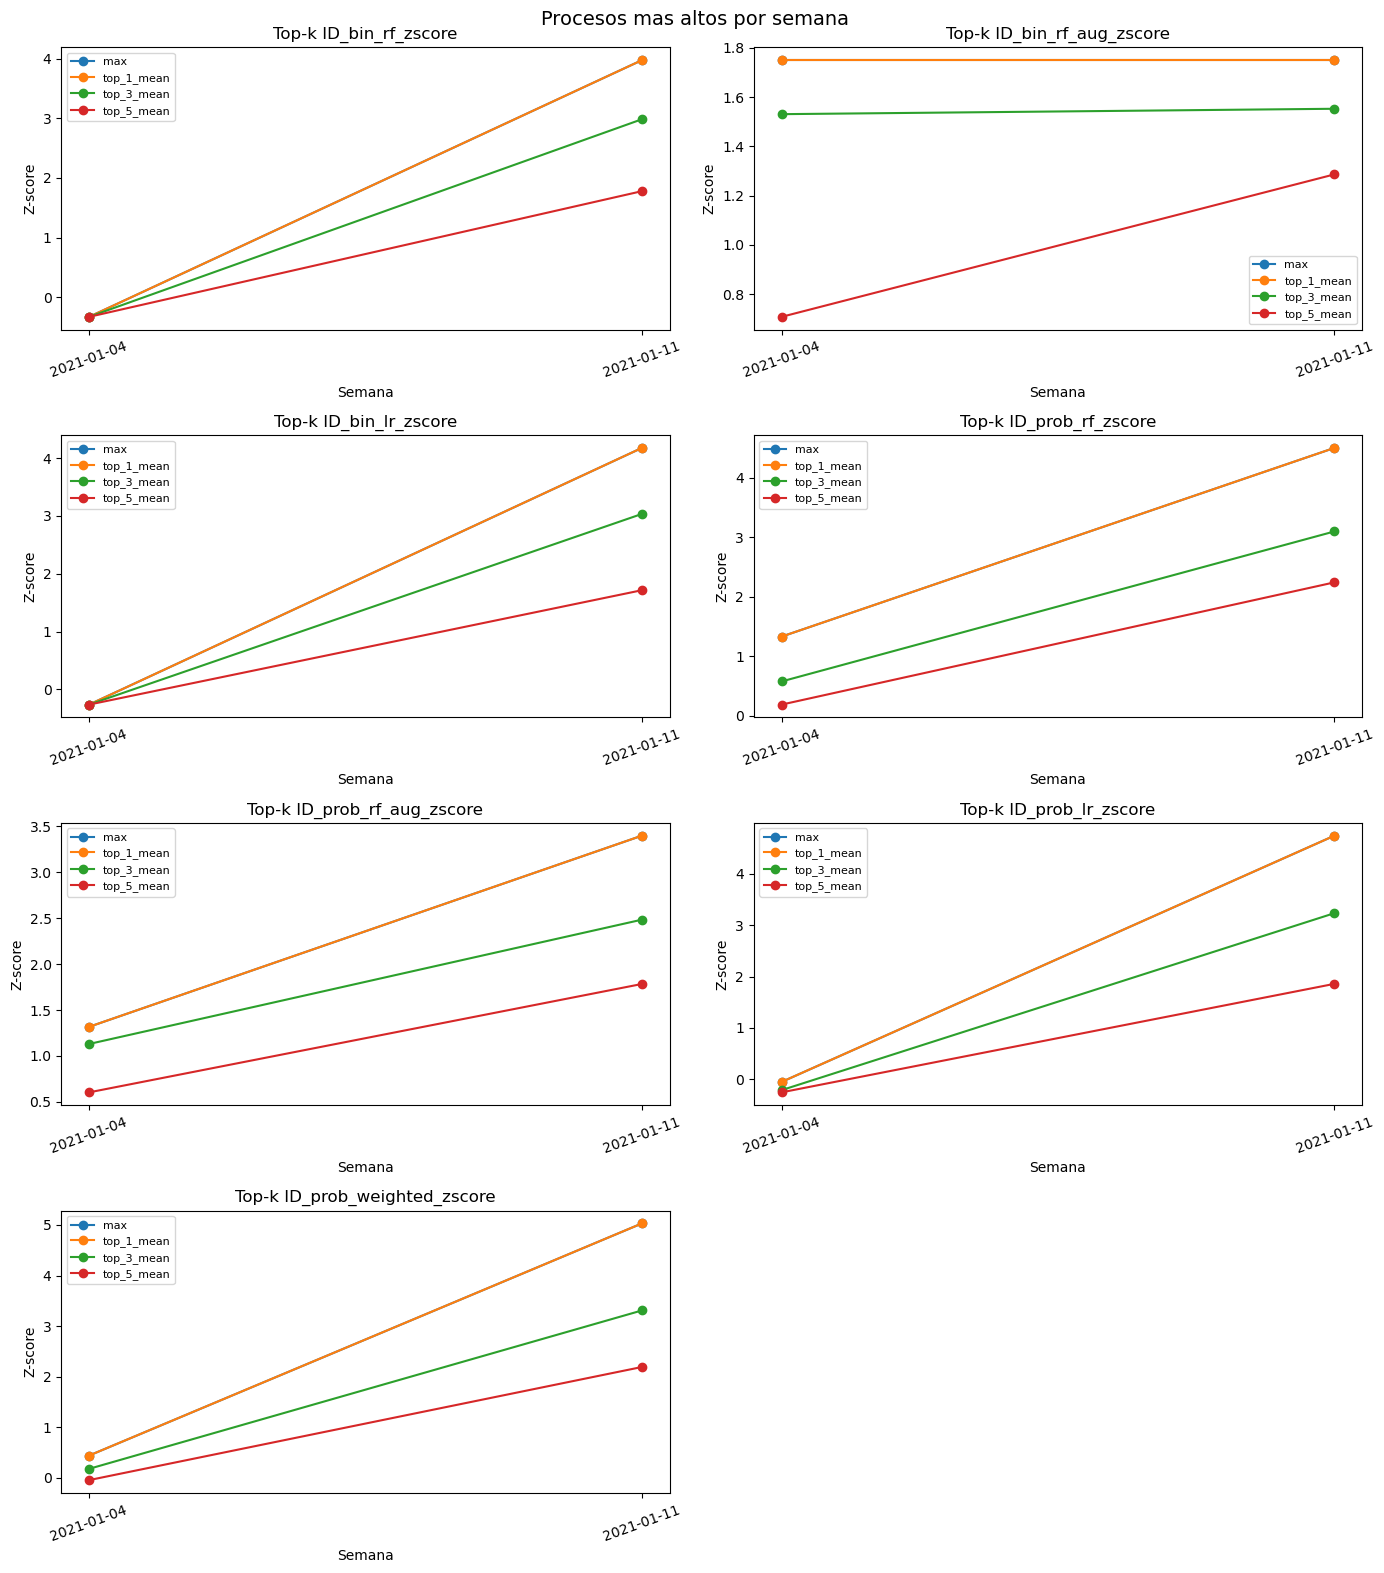

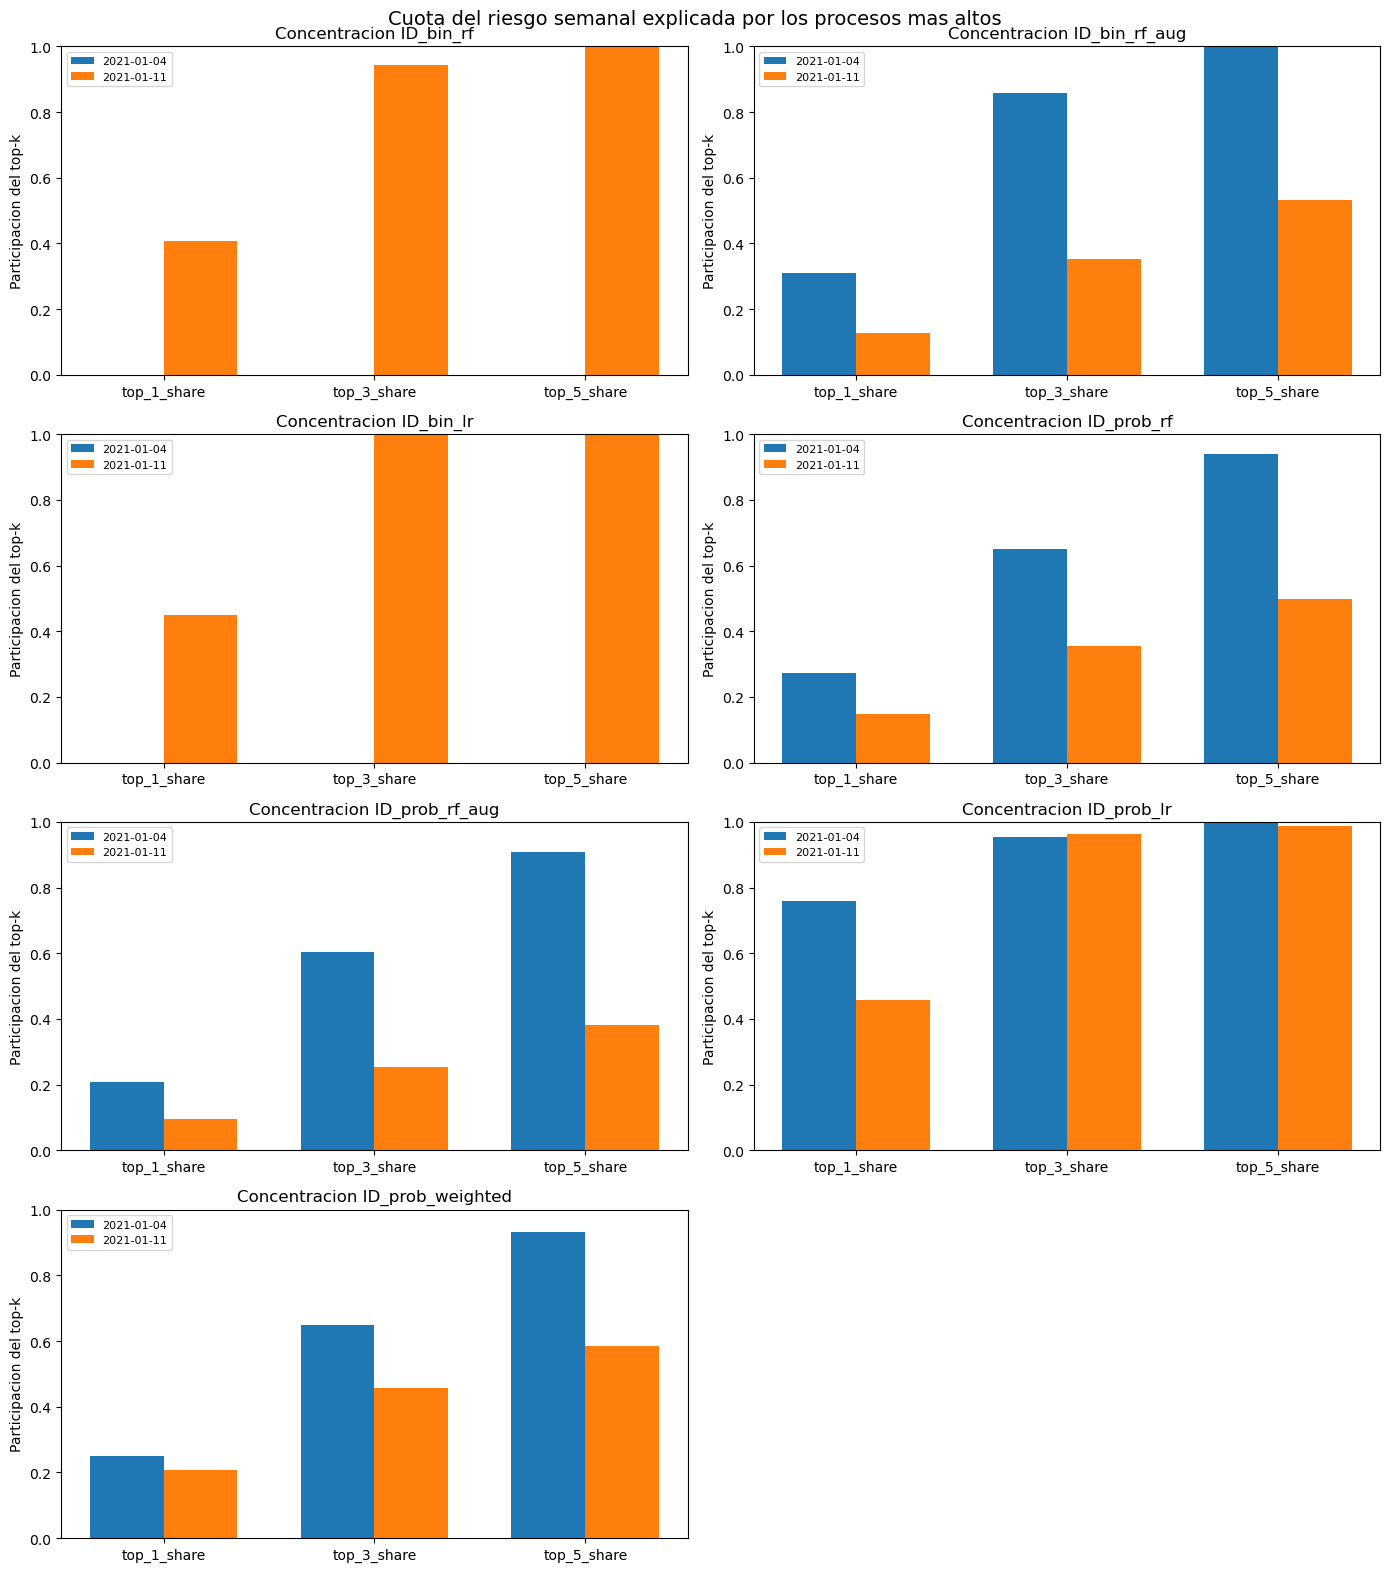

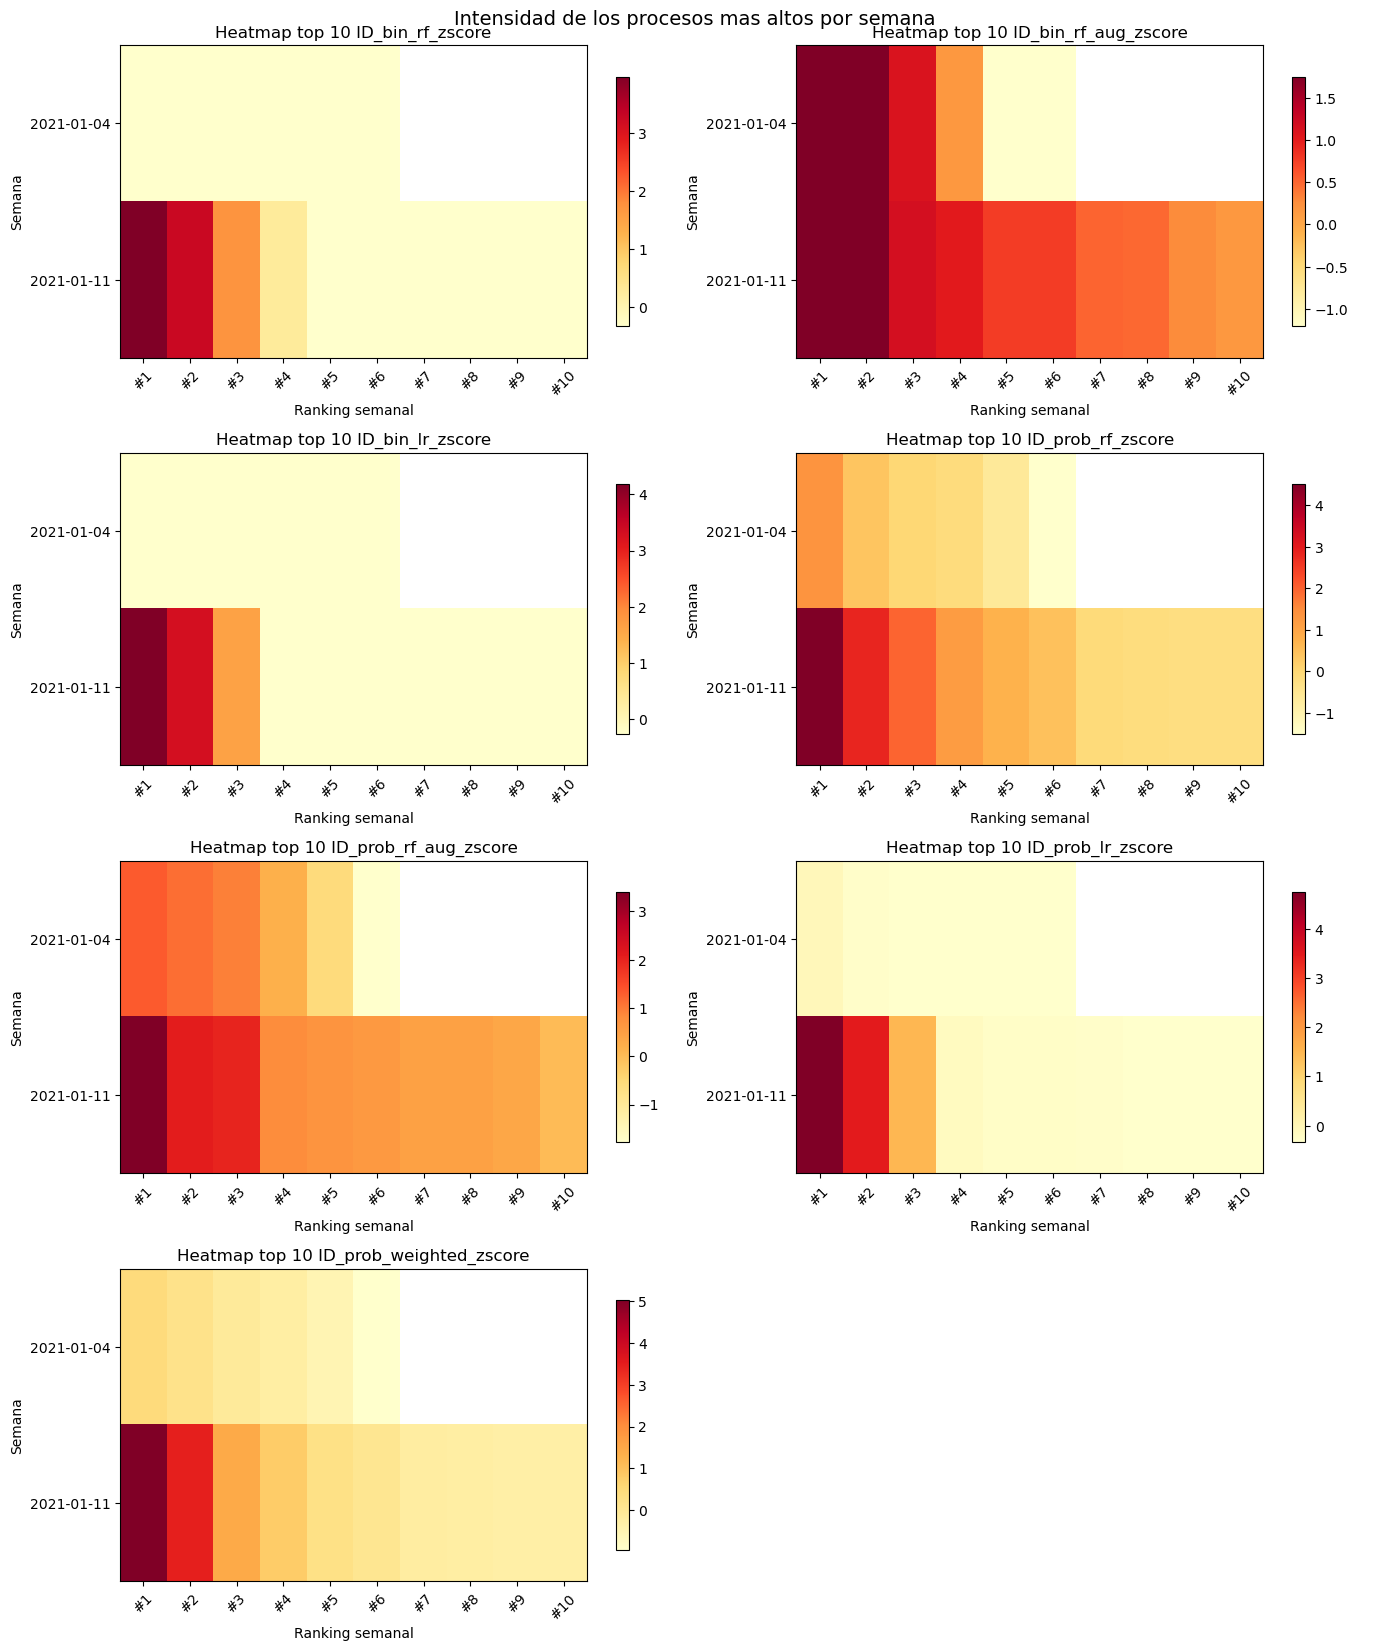

In [20]:
print(f"Semanas seleccionadas: {selected_weeks}")
print(weekly_process_df.groupby("week_label")["contract_id"].nunique().rename("n_procesos"))

plot_weekly_boxplots(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks)
plot_weekly_violins(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks)

topk_summary_df = compute_topk_summary(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks, TOP_K_VALUES)
plot_topk_lines(topk_summary_df, ZSCORE_INDEX_COLUMNS)

concentration_summary_df = compute_concentration_summary(weekly_process_df, RAW_INDEX_COLUMNS, selected_weeks, TOP_K_VALUES)
plot_concentration_bars(concentration_summary_df, RAW_INDEX_COLUMNS)

plot_weekly_heatmaps(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks, top_n=10)


## Barras por proceso

Esta seccion agrega graficos de barras por proceso para cada semana seleccionada. Se muestran todos los procesos de la semana y se mantiene el mismo orden de `contract_id` en todos los indices de esa semana para facilitar la comparacion visual y ver si los puntajes altos se concentran en procesos particulares.


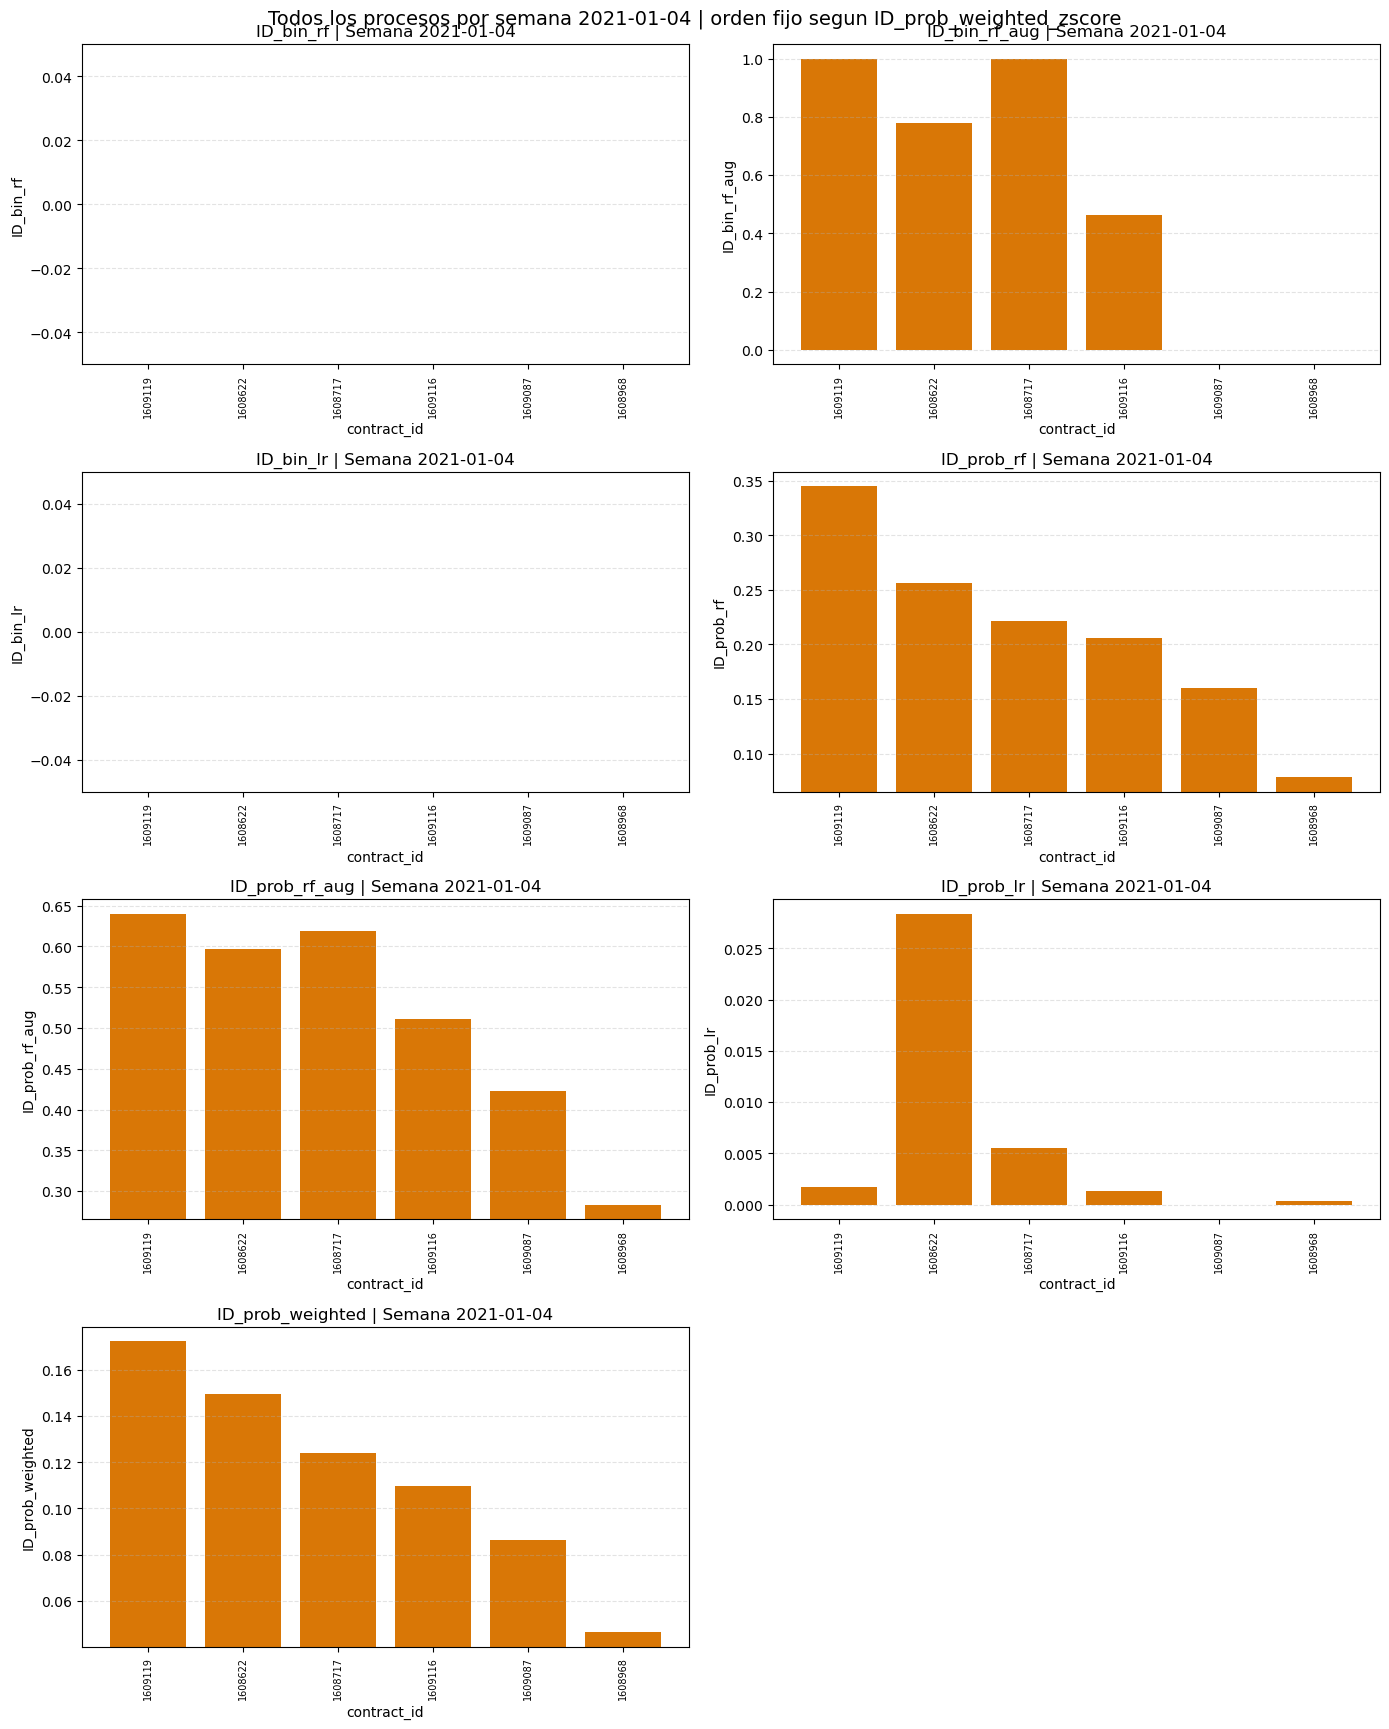

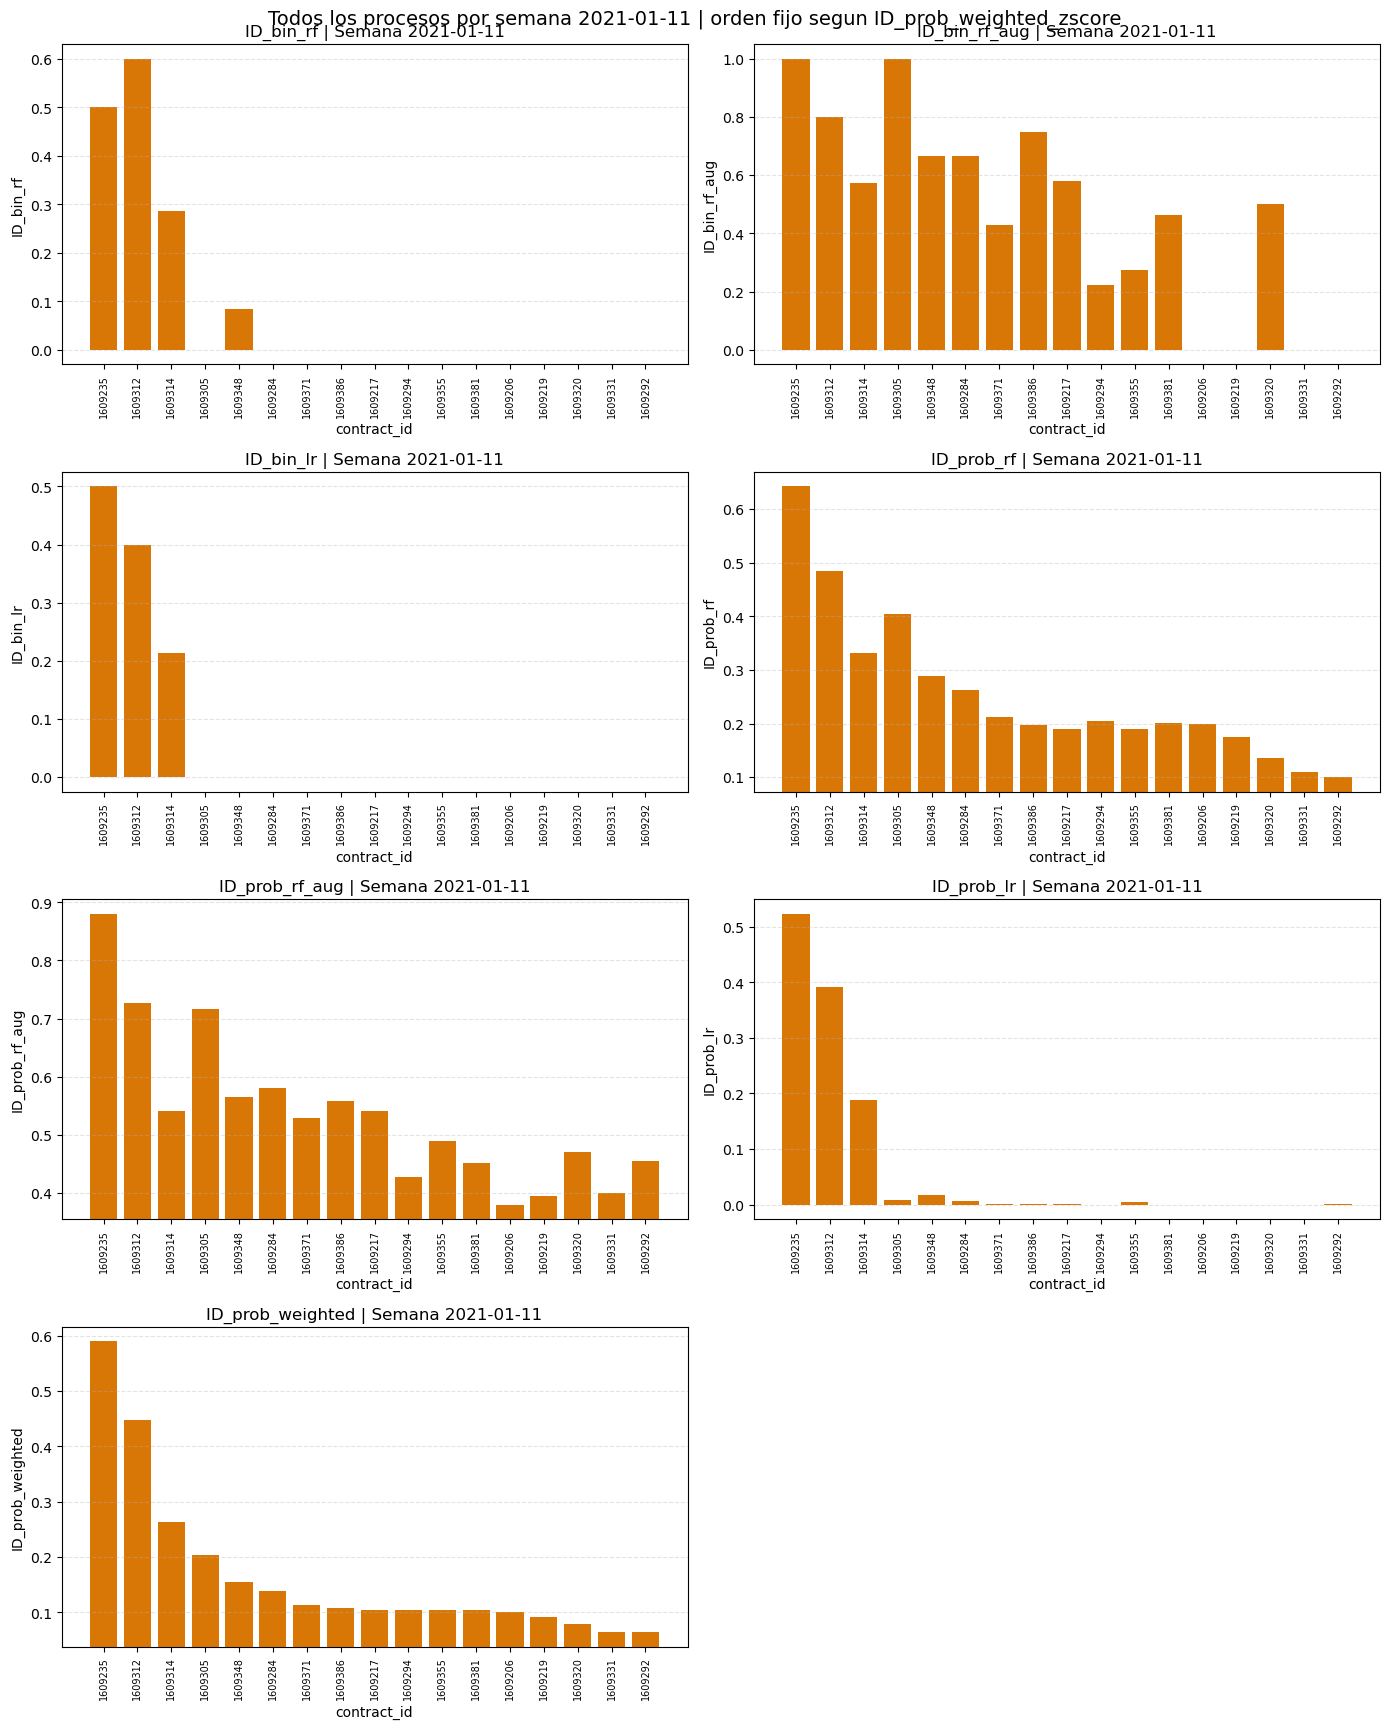

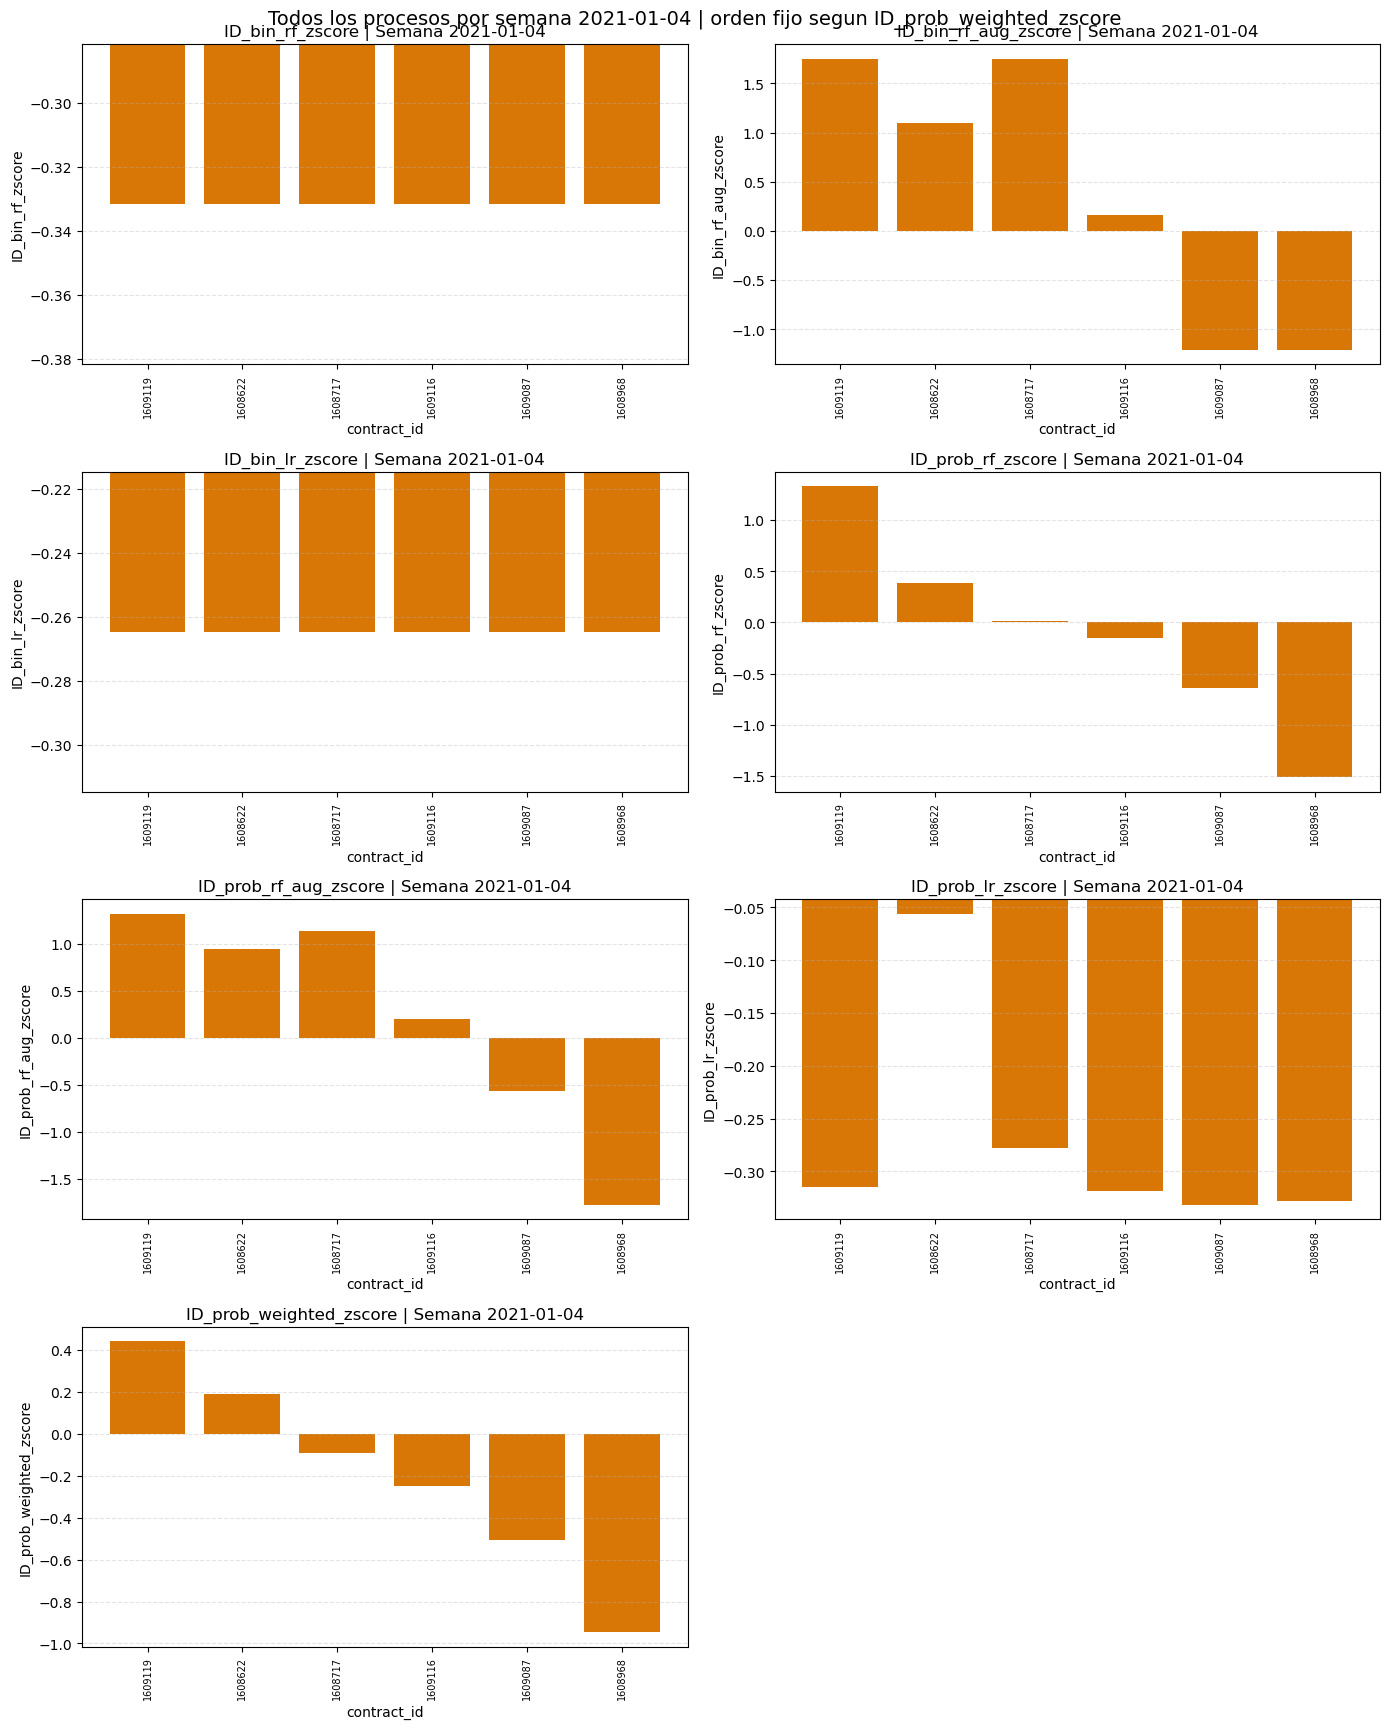

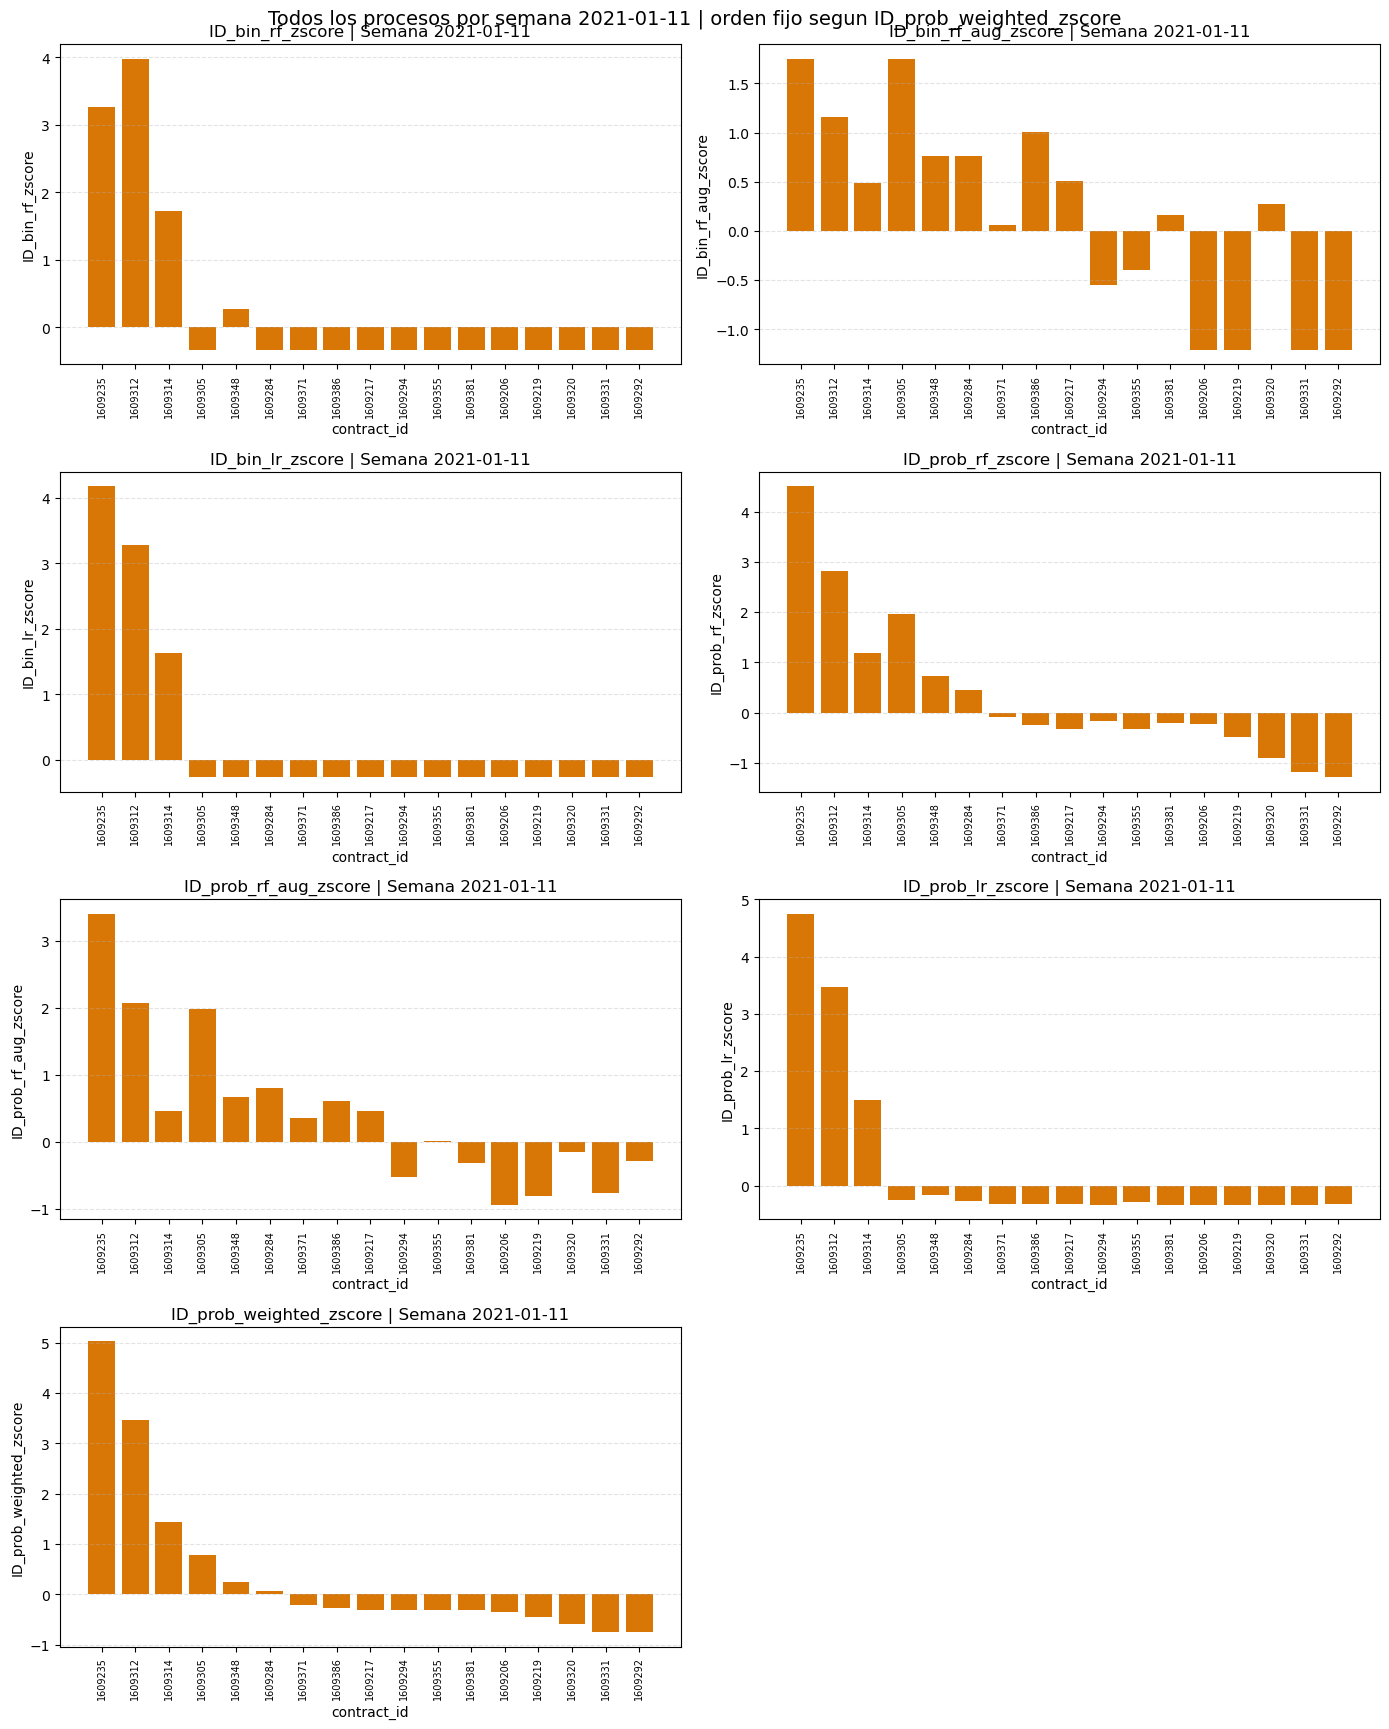

In [21]:
PROCESS_ORDER_INDEX = "ID_prob_weighted_zscore"

def plot_all_process_bars_by_week(
    df: pd.DataFrame,
    index_columns: list[str],
    selected_weeks: list[str],
    order_index: str,
) -> None:
    for week in selected_weeks:
        week_df = df[df["week_label"] == week].copy()
        week_df = week_df.sort_values(order_index, ascending=False).reset_index(drop=True)
        process_positions = np.arange(len(week_df))
        process_labels = week_df["contract_id"].astype(str).tolist()
        fig, axes = make_axis_grid(len(index_columns), ncols=2, figsize_scale=4.4)
        for ax, col in zip(axes, index_columns):
            values = week_df[col].to_numpy()
            ax.bar(process_positions, values, color="#d97706")
            ax.set_title(f"{col} | Semana {week}")
            ax.set_xlabel("contract_id")
            ax.set_ylabel(col)
            ax.set_xticks(process_positions)
            ax.set_xticklabels(process_labels, rotation=90, fontsize=7)
            value_min = float(np.min(values))
            value_max = float(np.max(values))
            value_range = value_max - value_min
            padding = 0.05 * value_range if value_range > 0 else max(abs(value_max) * 0.05, 0.05)
            ax.set_ylim(value_min - padding, value_max + padding)
            ax.grid(axis="y", linestyle="--", alpha=0.35)
        fig.suptitle(f"Todos los procesos por semana {week} | orden fijo segun {order_index}", fontsize=14)
        fig.tight_layout()
        plt.show()


plot_all_process_bars_by_week(weekly_process_df, RAW_INDEX_COLUMNS, selected_weeks, order_index=PROCESS_ORDER_INDEX)
plot_all_process_bars_by_week(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks, order_index=PROCESS_ORDER_INDEX)